Created on 24/09/2026, from "post_process_opt_results".

This script is used to post process optimization results from the stochastic planning (versions from stoch_plan_typdays_gridimport_bessFCR_v6 onward). It's an adaptation to the new definition of CAPEX, OPEX and replacement costs.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import string

## Extracting data from save file

In [31]:
# Unloading from the pickle file
filename = f"opt_results_50fc_90h2_6pv_2load_freeHSSsoc.pkl"

with open(f'../Optimization results/{filename}', 'rb') as f:
    results = pickle.load(f)


# Re-associating each variable to its own object
num_lev = results['num_lev']
run_kmeans = results['run_kmeans']
run_kmedoids = results['run_kmedoids']
taguchi_doe = results['taguchi_doe']
input_ARSTool = results['input_ARSTool']
input_new_jersey = results['input_new_jersey']
sym_fcr = results['sym_fcr']
fcr_active = results['fcr_active']
bess_fcr_active = results['bess_fcr_active']
fcr_4h = results['fcr_4h']
fc_active = results['fc_active']
bess_active = results['bess_active']
all_sizefixed = results['all_sizefixed']
fc_sizefixed = results['fc_sizefixed']
hss_sizefixed = results['hss_sizefixed']
discrete_sizes = results['discrete_sizes']
Hsup_day = results['Hsup_day']
alt_el_param = results['alt_el_param']
fcr_price_prof = results['fcr_price_prof']
multiplier_FCR = results['multiplier_FCR']

Ppv_rtd = results['Ppv_rtd']
Pload_rtd = results['Pload_rtd']

monthly_data_tuple = results['monthly_data_tuple']
months_names = results['months_names']

N_t = results['N_t']
N_d = results['N_d']
num_scen = results['num_scen']

C_ele_vals = results['C_ele_vals']
C_ele_sell_vals = results['C_ele_sell_vals']
Ppv_vals = results['Ppv_vals']
Pload_vals = results['Pload_vals']
C_FCR_capup_vals = results['C_FCR_capup_vals']
C_FCR_capdown_vals = results['C_FCR_capdown_vals']

Dnum = results['Dnum']
Hsup_tgt_month = results['Hsup_tgt_month']
C_h2 = results['C_h2']
C_h2_pen = results['C_h2_pen']
D_t = results['D_t']
C_el_su = results['C_el_su']
lhv = results['lhv']
P_hc_el2hss = results['P_hc_el2hss']
P_hc_hss2dem = results['P_hc_hss2dem']
alfa_b_dod = results['alfa_b_dod']
alfa_el_min = results['alfa_el_min']
alfa_el_sb = results['alfa_el_sb']
A = results['A']
B = results['B']
alfa_hss_min = results['alfa_hss_min']
eta_fc = results['eta_fc']
alfa_fc_min = results['alfa_fc_min']
N_y = results['N_y']
d = results['d']
Cb_mw_max = results['Cb_mw_max']
Cb_mwh_max = results['Cb_mwh_max']
Cel_max = results['Cel_max']
Chss_max = results['Chss_max']
Cfc_max = results['Cfc_max']

CRF = results['CRF']
Ppv_rtd = results['Ppv_rtd']
Capex_pv = results['Capex_pv']
Opex_pv = results['Opex_pv']
Capex_b_mwh = results['Capex_b_mwh']
Capex_b_mw = results['Capex_b_mw']
Opex_b_percent = results['Opex_b_percent']
repl_cost_b_percent = results['repl_cost_b_percent']
n_repl_b = results['n_repl_b']
repl_year_b = results['repl_year_b']
npv_repl_b = results['npv_repl_b']
# Capex_el_dir = results['Capex_el_dir']
# Capex_el_indir_percent = results['Capex_el_indir_percent']
Capex_el = results['Capex_el']
Opex_el_percent = results['Opex_el_percent']
repl_cost_el = results['repl_cost_el']
n_repl_el = results['n_repl_el']
repl_year_el = results['repl_year_el']
npv_repl_el = results['npv_repl_el']
Capex_hss = results['Capex_hss']
Opex_hss_percent = results['Opex_hss_percent']
Capex_fc = results['Capex_fc']
Opex_fc_percent = results['Opex_fc_percent']
repl_cost_fc_percent = results['repl_cost_fc_percent']
n_repl_fc = results['n_repl_fc']
repl_year_fc = results['repl_year_fc']
npv_repl_fc = results['npv_repl_fc']
# Capex_hc_pu_flux = results['Capex_hc_pu_flux']
Capex_hc_el2hss_pu_flux = results['Capex_hc_el2hss_pu_flux']
Capex_hc_hss2dem_pu_flux = results['Capex_hc_hss2dem_pu_flux']
Opex_hc_percent = results['Opex_hc_percent']
alfa_fr_hc_el2hss = results['alfa_fr_hc_el2hss']
FR_hc_hss2dem_max = results['FR_hc_hss2dem_max']

Obj = results['Obj']
Cb_mw_val = results['Cb_mw_val']
Cb_mwh_val = results['Cb_mwh_val']
Cel_val = results['Cel_val']
Chss_val = results['Chss_val']
Cfc_val = results['Cfc_val']

pel_vals = results['pel_vals']
hel_vals = results['hel_vals']
xel_on_vals = results['xel_on_vals']
xel_off_vals = results['xel_off_vals']
xel_sb_vals = results['xel_sb_vals']
xel_su_vals = results['xel_su_vals']
pb_dch_vals = results['pb_dch_vals']
pb_ch_vals = results['pb_ch_vals']
pb_vals = results['pb_vals']
eb_vals = results['eb_vals']
soc_vals = results['soc_vals']
xb_vals = results['xb_vals']
hhss_vals = results['hhss_vals']
hhss_seas_vals = results['hhss_seas_vals']
hdem_vals = results['hdem_vals']
pfc_vals = results['pfc_vals']
hfc_vals = results['hfc_vals']
pgrid_p_vals = results['pgrid_p_vals']
pgrid_n_vals = results['pgrid_n_vals']
xgrid_vals = results['xgrid_vals']

pel_fcr_up_vals = results['pel_fcr_up_vals']
pel_fcr_dwn_vals = results['pel_fcr_dwn_vals']
pfc_fcr_up_vals = results['pfc_fcr_up_vals']
pfc_fcr_dwn_vals = results['pfc_fcr_dwn_vals']
pb_fcr_ch_up_vals = results['pb_fcr_ch_up_vals']
pb_fcr_ch_dwn_vals = results['pb_fcr_ch_dwn_vals']
pb_fcr_dch_up_vals = results['pb_fcr_dch_up_vals']
pb_fcr_dch_dwn_vals = results['pb_fcr_dch_dwn_vals']

# print(C_ele_vals)
# print(Ppv_vals[2, 5, :])
# print(C_ele_sell_vals[1,2,1])

## Numerical results

In [32]:
#------------------------------------------------------------------------------------------------
# PROCESSING RESULTS
#------------------------------------------------------------------------------------------------

rev_tot = Obj    # objective function value

# Scenario-independent results
ann_install_costs = CRF * (Capex_pv * Ppv_rtd + (Capex_b_mwh * Cb_mwh_val + Capex_b_mw * Cb_mw_val) \
                + (Capex_el * Cel_val) + (Capex_hss * Chss_val) \
                + (Capex_fc * Cfc_val) \
                + (Capex_hc_el2hss_pu_flux * alfa_fr_hc_el2hss * Cel_val) \
                + (Capex_hc_hss2dem_pu_flux * FR_hc_hss2dem_max))
ann_om_costs = Opex_pv * Ppv_rtd + (Capex_b_mwh * Cb_mwh_val + Capex_b_mw * Cb_mw_val) * Opex_b_percent \
                + (Capex_el * Cel_val) * Opex_el_percent + (Capex_hss * Chss_val) * Opex_hss_percent \
                + (Capex_fc * Cfc_val) * Opex_fc_percent \
                + (Capex_hc_el2hss_pu_flux * alfa_fr_hc_el2hss * Cel_val) * Opex_hc_percent \
                + (Capex_hc_hss2dem_pu_flux * FR_hc_hss2dem_max) * Opex_hc_percent
ann_repl_costs = CRF * (npv_repl_b * Cb_mwh_val + npv_repl_el * Cel_val + npv_repl_fc * Cfc_val)

# Scenario-dependent results
rev_tot_scen = np.zeros(num_scen)
rev_h2sell_scen = np.zeros(num_scen)
# cost_h2pen_scen = np.zeros(num_scen)
rev_elecsell_scen = np.zeros(num_scen)
rev_loadpower_scen = np.zeros(num_scen)
rev_FCR_h2_scen = np.zeros(num_scen)
rev_FCR_bess_scen = np.zeros(num_scen)
cost_elsu_scen = np.zeros(num_scen)

for s in range(num_scen):
    if fcr_price_prof:
        rev_tot_scen[s] = -ann_install_costs - ann_om_costs - ann_repl_costs \
                    + sum(Dnum[d] * (sum(hdem_vals[s, d, t] * C_h2 \
                    + pgrid_n_vals[s, d, t] * D_t * C_ele_sell_vals[s, d, t] \
                    + (Pload_vals[s, d, t] - pgrid_p_vals[s, d, t]) * D_t * C_ele_vals[s, d, t] \
                    + (pel_fcr_up_vals[s, d, t] * C_FCR_capup_vals[s, d, t] + pel_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals[s, d, t] \
                    + pfc_fcr_up_vals[s, d, t] * C_FCR_capup_vals[s, d, t] + pfc_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals[s, d, t]) * D_t \
                    + ((pb_fcr_ch_up_vals[s, d, t] + pb_fcr_dch_up_vals[s, d, t]) * C_FCR_capup_vals[s, d, t] \
                    + (pb_fcr_ch_dwn_vals[s, d, t] + pb_fcr_dch_dwn_vals[s, d, t]) * C_FCR_capdown_vals[s, d, t]) \
                    - xel_su_vals[s, d, t] * C_el_su \
                    for t in range(N_t)) \
                    - (Hsup_tgt_month[d] / Dnum[d] - sum(hdem_vals[s, d, t] for t in range(N_t))) * C_h2_pen) \
                    for d in range(N_d))
    
    else:
        rev_tot_scen[s] = -ann_install_costs - ann_om_costs - ann_repl_costs \
                    + sum(Dnum[d] * (sum(hdem_vals[s, d, t] * C_h2 \
                    + pgrid_n_vals[s, d, t] * D_t * C_ele_sell_vals[s, d, t] \
                    + (Pload_vals[s, d, t] - pgrid_p_vals[s, d, t]) * D_t * C_ele_vals[s, d, t] \
                    + (pel_fcr_up_vals[s, d, t] * C_FCR_capup_vals + pel_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals \
                    + pfc_fcr_up_vals[s, d, t] * C_FCR_capup_vals + pfc_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals) * D_t \
                    + ((pb_fcr_ch_up_vals[s, d, t] + pb_fcr_dch_up_vals[s, d, t]) * C_FCR_capup_vals \
                    + (pb_fcr_ch_dwn_vals[s, d, t] + pb_fcr_dch_dwn_vals[s, d, t]) * C_FCR_capdown_vals) \
                    - xel_su_vals[s, d, t] * C_el_su \
                    for t in range(N_t)) \
                    - (Hsup_tgt_month[d] / Dnum[d] - sum(hdem_vals[s, d, t] for t in range(N_t))) * C_h2_pen) \
                    for d in range(N_d))

    rev_h2sell_scen[s] = sum(Dnum[d] * sum(hdem_vals[s, d, t] * C_h2 for t in range(N_t)) for d in range(N_d))
    # cost_h2pen_scen[s] = sum(m.Dnum[d] * sum(hext_vals[s, d, t] * 1e7 for t in range(N_t)) for d in range(N_d))
    rev_elecsell_scen[s] = sum(Dnum[d] * sum(pgrid_n_vals[s, d, t] * D_t * C_ele_sell_vals[s, d, t] for t in range(N_t)) for d in range(N_d))
    rev_loadpower_scen[s] = sum(Dnum[d] * sum((Pload_vals[s, d, t] - pgrid_p_vals[s, d, t]) * D_t * C_ele_vals[s, d, t] for t in range(N_t)) for d in range(N_d))
    cost_elsu_scen[s] = sum(Dnum[d] * sum(xel_su_vals[s, d, t] * C_el_su for t in range(N_t)) for d in range(N_d))

    if fcr_price_prof:
        rev_FCR_h2_scen[s] = sum(Dnum[d] * sum((pel_fcr_up_vals[s, d, t] * C_FCR_capup_vals[s, d, t] + pel_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals[s, d, t] \
                              + pfc_fcr_up_vals[s, d, t] * C_FCR_capup_vals[s, d, t] + pfc_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals[s, d, t]) * D_t for t in range(N_t)) for d in range(N_d))
        rev_FCR_bess_scen[s] = sum(Dnum[d] * sum(((pb_fcr_ch_up_vals[s, d, t] + pb_fcr_dch_up_vals[s, d, t]) * C_FCR_capup_vals[s, d, t] \
                              + (pb_fcr_ch_dwn_vals[s, d, t] + pb_fcr_dch_dwn_vals[s, d, t]) *C_FCR_capdown_vals[s, d, t]) * D_t for t in range(N_t)) for d in range(N_d))
    
    else:
        rev_FCR_h2_scen[s] = sum(Dnum[d] * sum((pel_fcr_up_vals[s, d, t] * C_FCR_capup_vals + pel_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals \
                              + pfc_fcr_up_vals[s, d, t] * C_FCR_capup_vals + pfc_fcr_dwn_vals[s, d, t] * C_FCR_capdown_vals) * D_t for t in range(N_t)) for d in range(N_d))
        rev_FCR_bess_scen[s] = sum(Dnum[d] * sum(((pb_fcr_ch_up_vals[s, d, t] + pb_fcr_dch_up_vals[s, d, t]) * C_FCR_capup_vals \
                              + (pb_fcr_ch_dwn_vals[s, d, t] + pb_fcr_dch_dwn_vals[s, d, t]) * C_FCR_capdown_vals) * D_t for t in range(N_t)) for d in range(N_d))


print(f'Value of the stochastic optimization objective function = {rev_tot:.2f} €')
print(f'Mean value of the net revenue across all scenarios (equal weights) = {rev_tot_scen.mean():.2f} €\n')

# if sum(cost_h2pen_scen) > 1:
#     print(f"*** External hydrogen was needed in at least one scenario ***")

print(f"Optimal BESS size: {Cb_mwh_val:.2f} MWh, {Cb_mw_val:.2f} MW")
print(f"Optimal EL size: {Cel_val:.2f} MW")
print(f"Optimal HSS size: {Chss_val:.2f} kg")
print(f"Optimal FC size: {Cfc_val:.2f} MW\n")

print(f"Annualized installation costs = {ann_install_costs:.2f} €")
print(f"Annual O&M costs = {ann_om_costs:.2f} €\n\n")
print(f"Annualized replacement costs = {ann_repl_costs:.2f} €\n\n")

print(f'Revenue splits for the single scenarios:\n')
for s in range(num_scen):
    print(f'----- Scenario {s} -----')
    print(f'Net revenue = {rev_tot_scen[s]:.2f} €')
    print(f'Revenue from selling hydrogen to the HRS = {rev_h2sell_scen[s]:.2f} €')
    # if cost_h2pen_scen[s] > 1:
    #     print(f"Penalty for buying external hydrogen = {cost_h2pen_scen[s]:.3f} €")
    print(f'Revenue from selling excess electricity to the main grid = {rev_elecsell_scen[s]:.2f} €')
    print(f'Revenue from powering the load = {rev_loadpower_scen[s]:.2f} €')
    print(f'Revenue from EL + FC participation in the FCR service = {rev_FCR_h2_scen[s]:.2f} €\n')
    print(f'Revenue from BESS participation in the FCR service = {rev_FCR_bess_scen[s]:.2f} €\n')

Value of the stochastic optimization objective function = 218195.04 €
Mean value of the net revenue across all scenarios (equal weights) = 218195.04 €

Optimal BESS size: 2.00 MWh, 1.00 MW
Optimal EL size: 0.33 MW
Optimal HSS size: 3042.98 kg
Optimal FC size: 0.05 MW

Annualized installation costs = 442477.48 €
Annual O&M costs = 88009.89 €


Annualized replacement costs = 26964.44 €


Revenue splits for the single scenarios:

----- Scenario 0 -----
Net revenue = 175590.09 €
Revenue from selling hydrogen to the HRS = 229950.00 €
Revenue from selling excess electricity to the main grid = 71810.50 €
Revenue from powering the load = 307702.35 €
Revenue from EL + FC participation in the FCR service = 4782.18 €

Revenue from BESS participation in the FCR service = 118796.88 €

----- Scenario 1 -----
Net revenue = 174759.31 €
Revenue from selling hydrogen to the HRS = 229950.00 €
Revenue from selling excess electricity to the main grid = 73643.03 €
Revenue from powering the load = 297300.57 

In [33]:
# Check simulation parameters
print(f"N. scenarios: {num_scen}")
print(f"FC size: {Cfc_val} MW")
print(f"Hydrogen daily demand: {Hsup_day} kg")
print(f"PV size: {Ppv_rtd} MW")
print(f"Load size: {Pload_rtd} MW")
print(f"Initial hydrogen SoC in the HSS: {hhss_vals[0, 0, 0] / Chss_val * 100} %")
print(f"Ratio between electricity cost and selling price: {C_ele_vals[0, 0, 0] / C_ele_sell_vals[0, 0, 0]}")

N. scenarios: 8
FC size: 0.05 MW
Hydrogen daily demand: 90 kg
PV size: 6 MW
Load size: 2 MW
Initial hydrogen SoC in the HSS: 10.0 %
Ratio between electricity cost and selling price: 2.0


## Plotting

In [34]:
#------------------------------------------------------------------------------------------------
# PLOT SETTINGS
#------------------------------------------------------------------------------------------------

plt.rc('figure', figsize=(20, 10))
plt.rc('font', size=12)
# plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=20, titlesize=20)
plt.rc('legend', fontsize=18)
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 1

# # --- IEEE Formatting Config ---
# IEEE_col_width = 3.5  # Standard single-column width in inches
# IEEE_fig_height_2supblot = 3.8  # Aspect ratio for 2 stacked subplots

# fig_width = 7                 # IEEE_col_width * 2 = 3.5 * 2
# fig_height_1plot = 3.8 * 0.8       # (3.8 / 2) * 2 o 3.8 * 0.8 per la versione "small"
# fig_height_2subplot = 7.6     # 3.8 * 2

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 24, # 16
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 22, # 14
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'lines.linewidth': 2.0,
    'grid.linestyle': ':',
    'grid.alpha': 0.6,
    'grid.color': '#aaaaaa',
    'axes.grid': True,
    'pdf.fonttype': 42,  # Ensures Type 42 (TrueType) embedding for IEEE
    'ps.fonttype': 42
})

# Color palette
muted_blue = '#1f77b4'  # Muted Blue
muted_red = '#d62728'  # Muted Red
muted_green = '#2ca02c'  # Muted Green
dark_grey = '#666666'  # Dark Grey

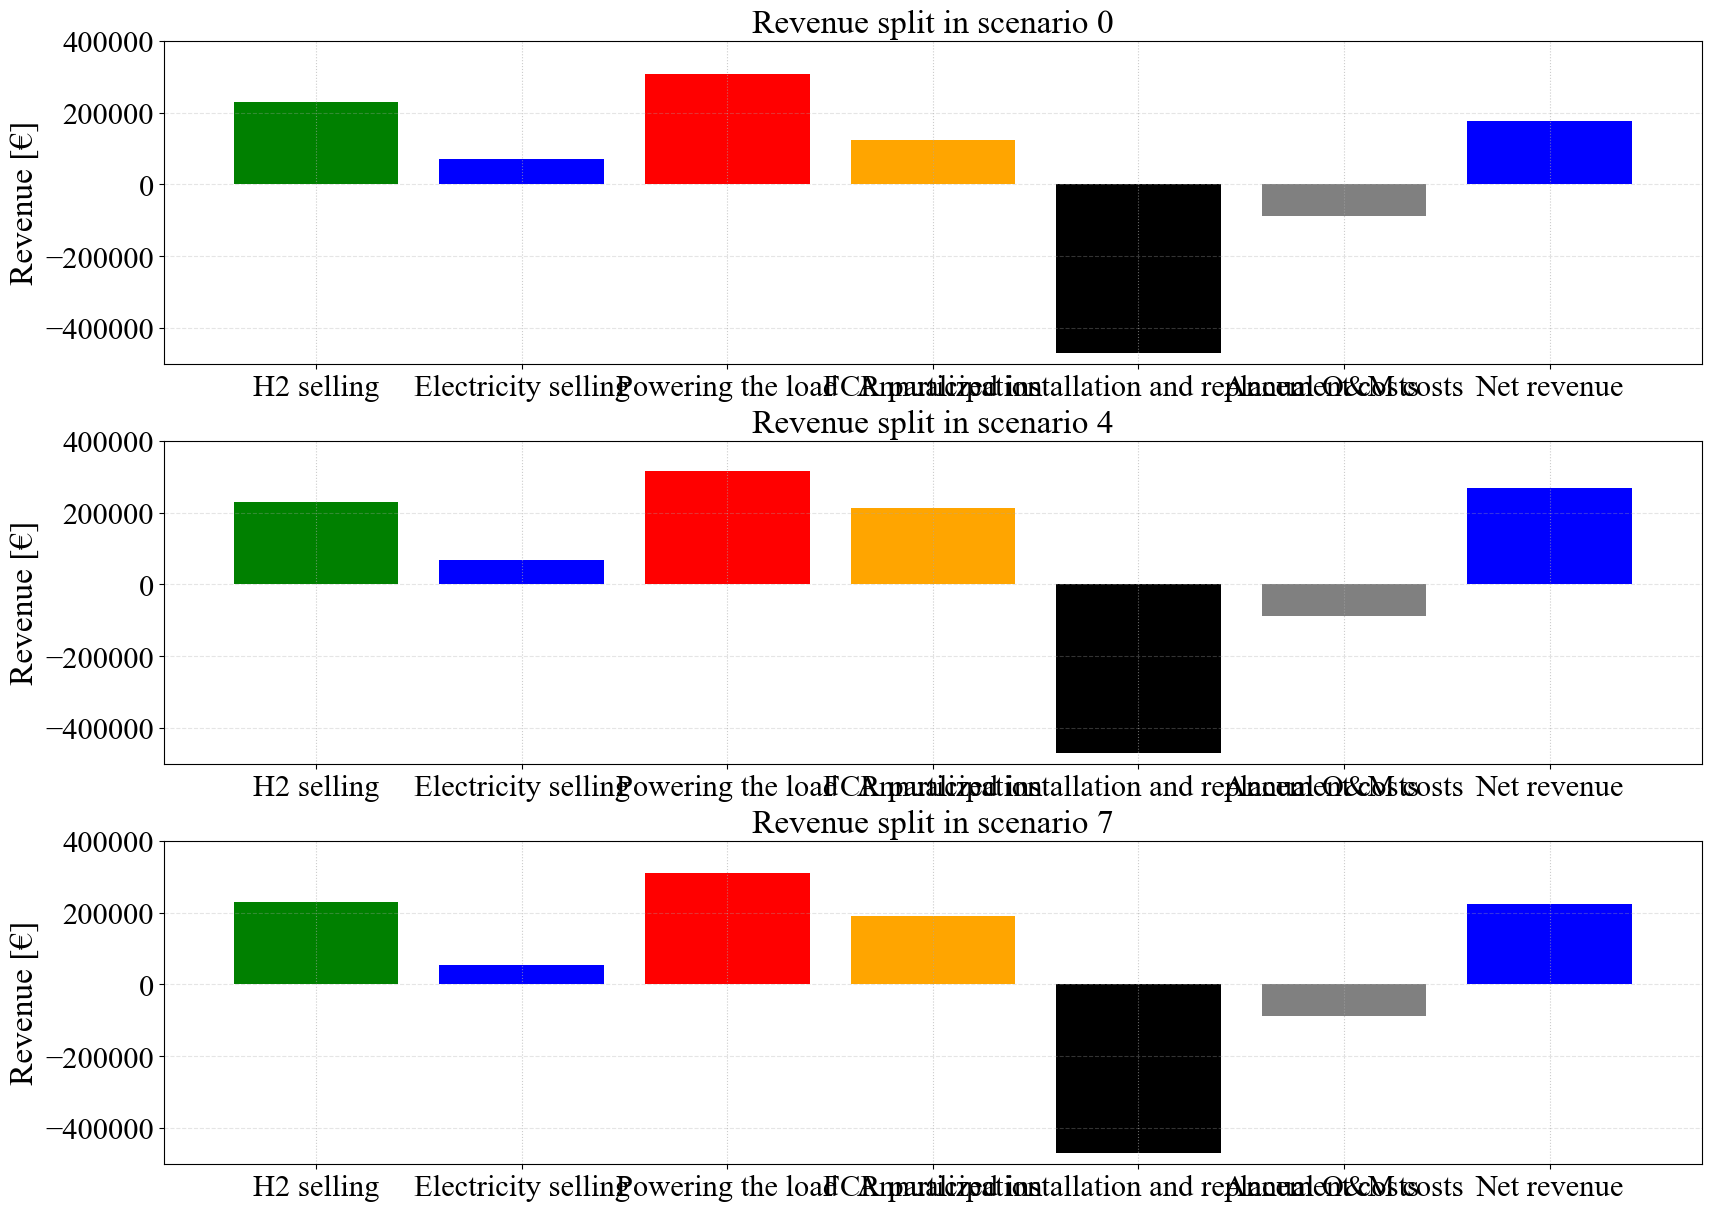

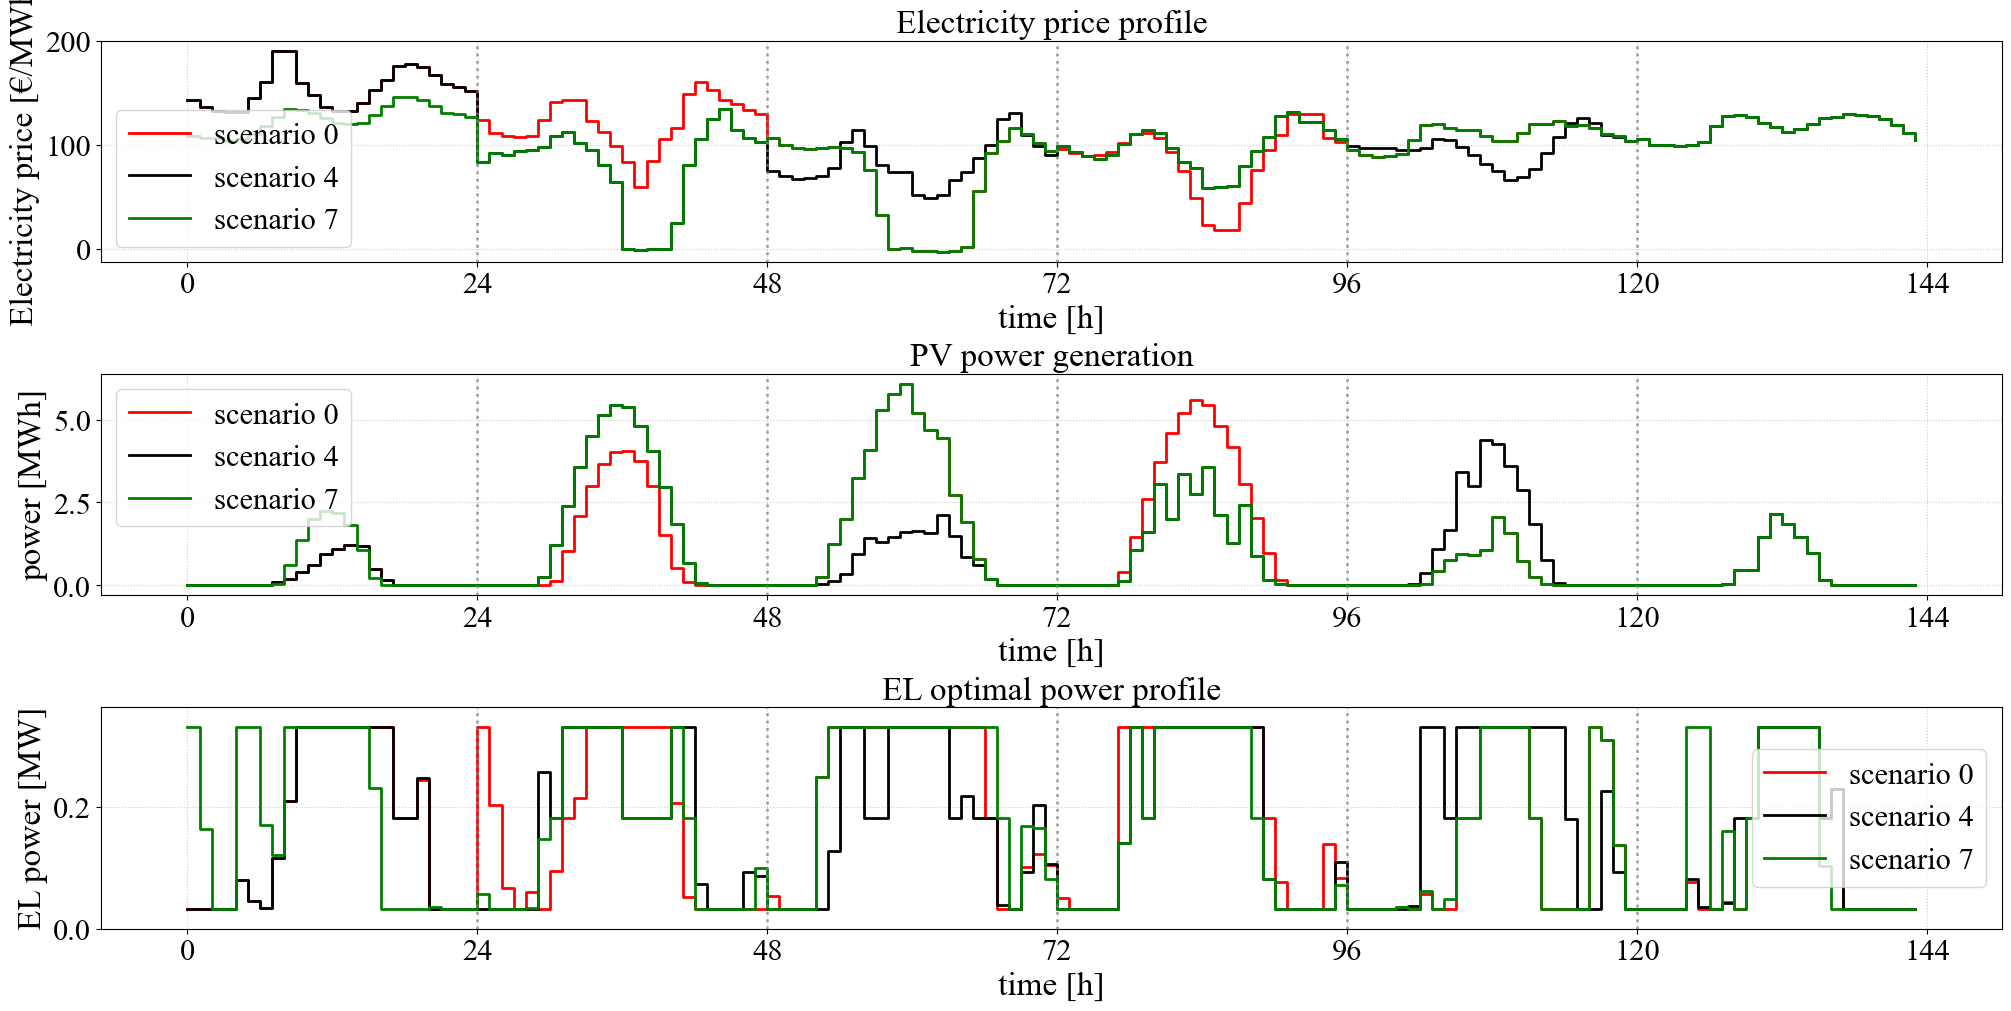

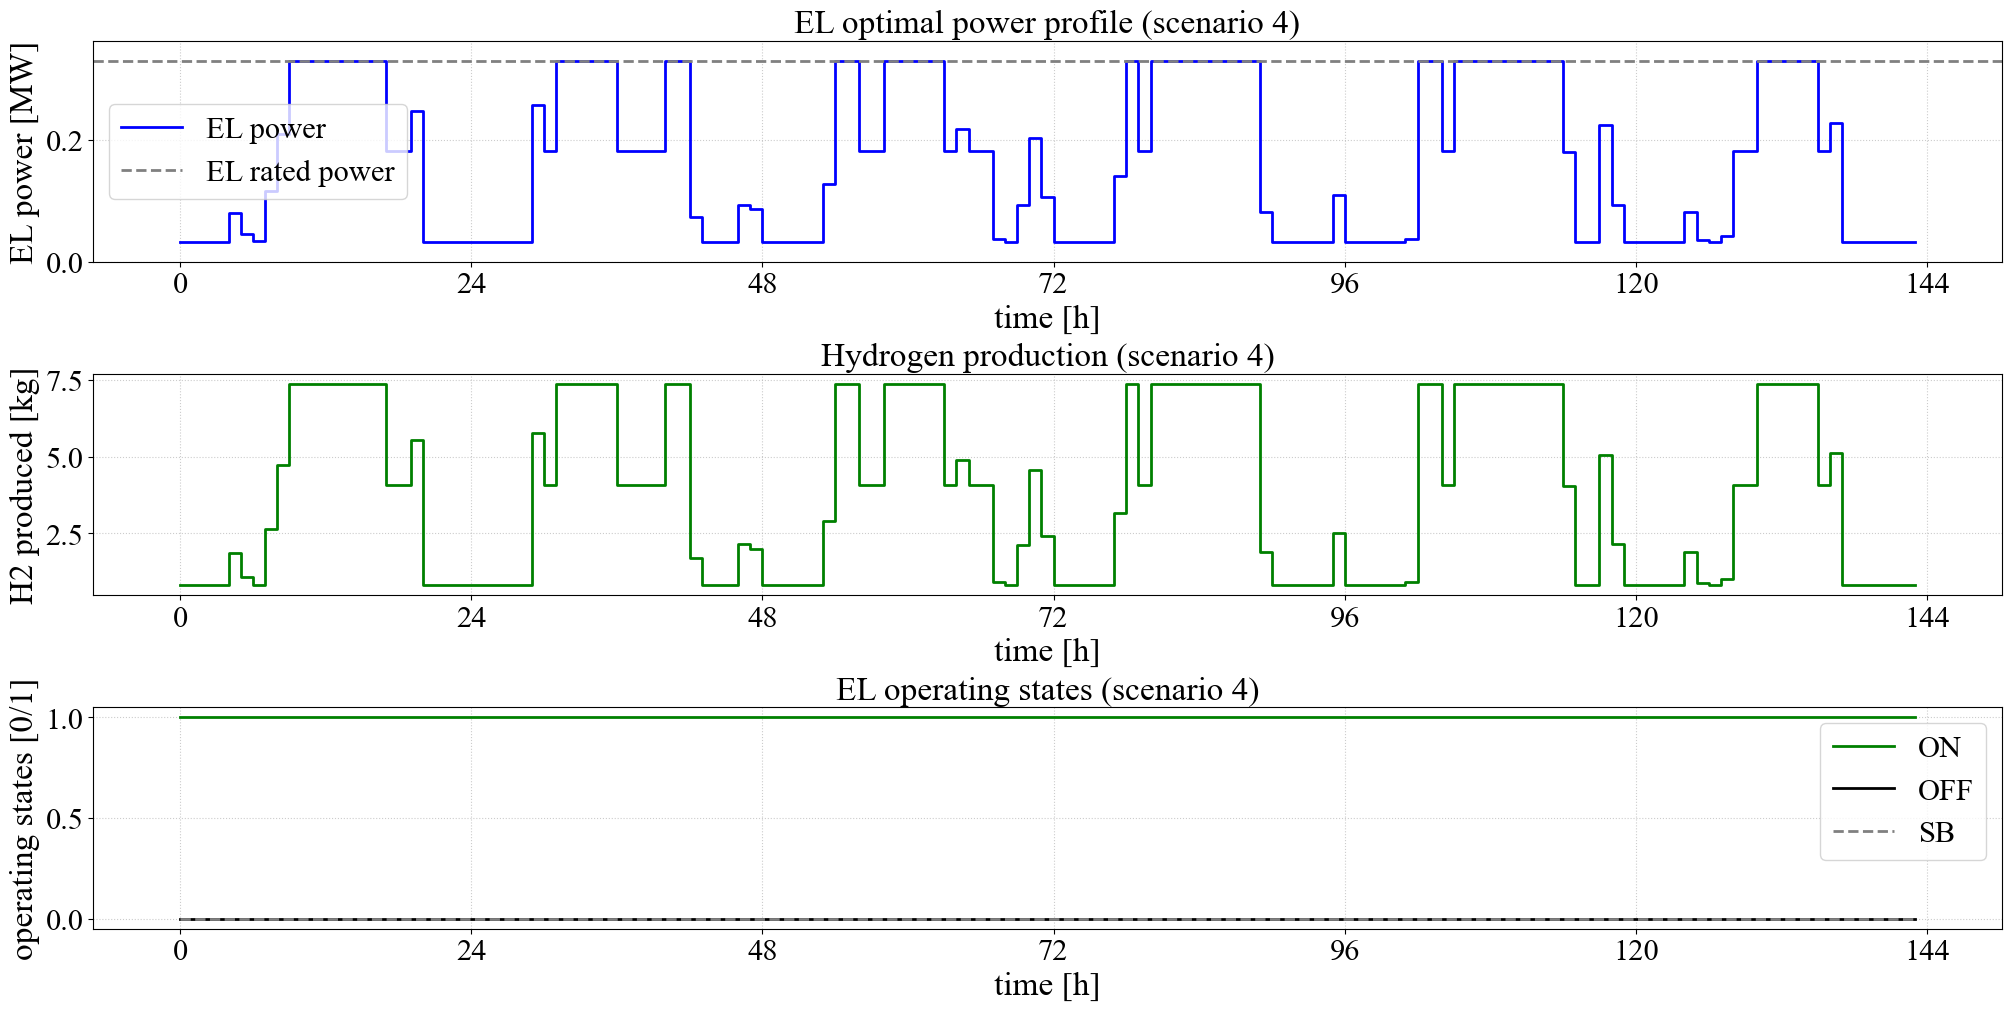

In [35]:
#------------------------------------------------------------------------------------------------
# PLOTTING (1/5)
#------------------------------------------------------------------------------------------------
# time_plot = time[:time_window + 1]      # time array for plotting
time_plot = np.arange(0, N_t + 1)                # time array for single day plotting
time_plot_tdays = np.arange(0, N_t * N_d + 1)    # time array for typical days plotting
time_plot_year = np.arange(0, 8760)    # time array for full-year plotting
day_2plot = 0                                    # specific day for plotting
scenarios = [0, int(num_scen/2), num_scen - 1]   # specific scenarios selected for plotting
scen = 0


# # Plot settings ---------------------------------------------------------------------------------
# plt.rc('figure', figsize=(20, 10))
# plt.rc('font', family='monospace', weight='bold', size=11)
# plt.rc('axes', labelsize=11, titlesize=14)
# plt.rc('legend', fontsize=11)
# plt.rc('xtick', labelsize=10)
# plt.rc('ytick', labelsize=10)
# plt.rcParams['axes.grid'] = True
# plt.rcParams['lines.linewidth'] = 2


# RESULTS PLOTS ---------------------------------------------------------------------------------
labels = ['H2 selling', 'Electricity selling', 'Powering the load', 'FCR participation', 'Annualized installation and replacement costs', 'Annual O&M costs']
colors = ['green', 'blue', 'red', 'orange', 'black', 'grey']
# values = [rev_h2sell, rev_elecsell, rev_loadpower, rev_FCR, -ann_install_costs, -ann_om_costs]

figRES, axsRES = plt.subplots(len(scenarios), 1, layout='constrained')
for s in range(len(scenarios)):
    values = [rev_h2sell_scen[scenarios[s]], rev_elecsell_scen[scenarios[s]], rev_loadpower_scen[scenarios[s]], 
              rev_FCR_h2_scen[scenarios[s]] + rev_FCR_bess_scen[scenarios[s]], -ann_install_costs - ann_repl_costs, -ann_om_costs]
    axsRES[s].bar(labels, values, color = colors)
    # axsRES[s].bar(['Total Revenue'], [rev_h2sell_scen[scenarios[s]]], label='Hydrogen', color = colors[0])
    # axsRES[s].bar(['Total Revenue'], [rev_elecsell_scen[scenarios[s]]], bottom=[rev_h2sell_scen[scenarios[s]]], label='Electricity', color = colors[1])
    # axsRES[s].bar(['Total Revenue'], [rev_FCR_scen[scenarios[s]]], bottom=[rev_h2sell_scen[scenarios[s]] + rev_elecsell_scen[scenarios[s]]], label='Other', color = colors[2])
    axsRES[s].bar(['Net revenue'], [rev_tot_scen[scenarios[s]]], color = 'blue')
    axsRES[s].set_ylabel("Revenue [€]")
    axsRES[s].set_ylim(-5e5, 4e5)
    axsRES[s].set_title(f'Revenue split in scenario {scenarios[s]}')
    axsRES[s].grid(axis='y', linestyle='--', alpha=0.3)
    axsRES[s].figure.set_size_inches(17, 12)
    # plt.tight_layout()


# INPUT PLOTS -----------------------------------------------------------------------------------
# TIME WINDOW
# Electricity cost plot
figIN, axsIN = plt.subplots(3, 1, layout='constrained')
axsIN[0].step(time_plot_tdays[:-1], C_ele_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsIN[0].step(time_plot_tdays[:-1], C_ele_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsIN[0].step(time_plot_tdays[:-1], C_ele_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsIN[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[0].set_xlabel('time [h]')
axsIN[0].set_ylabel('Electricity price [€/MWh]')
axsIN[0].set_title("Electricity price profile")
axsIN[0].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[0].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
# PV power plot
axsIN[1].step(time_plot_tdays[:-1], Ppv_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsIN[1].step(time_plot_tdays[:-1], Ppv_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsIN[1].step(time_plot_tdays[:-1], Ppv_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsIN[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[1].set_xlabel('time [h]')
axsIN[1].set_ylabel('power [MWh]')
axsIN[1].set_title("PV power generation")
axsIN[1].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[1].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
# EL power plot
axsIN[2].step(time_plot_tdays[:-1], pel_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsIN[2].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsIN[2].step(time_plot_tdays[:-1], pel_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsIN[2].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[2].set_xlabel('time [h]')
axsIN[2].set_ylabel('EL power [MW]')
axsIN[2].set_title("EL optimal power profile")
axsIN[2].set_ylim(0, 1.1 * Cel_val)
axsIN[2].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[2].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )


# EL PLOTS --------------------------------------------------------------------------------------
# TIME WINDOW
# EL power plot
figEL, axsEL = plt.subplots(3, 1, layout='constrained')
axsEL[0].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'blue', label = 'EL power')
axsEL[0].axhline(y=Cel_val, color = 'grey', linestyle = '--', label = 'EL rated power')
axsEL[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[0].set_xlabel('time [h]')
axsEL[0].set_ylabel('EL power [MW]')
axsEL[0].set_title(f'EL optimal power profile (scenario {scenarios[1]})')
axsEL[0].set_ylim(0, 1.1 * Cel_val)
axsEL[0].legend()
# Hydrogen production plot
axsEL[1].step(time_plot_tdays[:-1], hel_vals[scenarios[1], :, :].reshape(-1), color = 'green', where='post')
axsEL[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[1].set_xlabel('time [h]')
axsEL[1].set_ylabel('H2 produced [kg]')
axsEL[1].set_title(f'Hydrogen production (scenario {scenarios[1]})')
# EL operating states plot
axsEL[2].step(time_plot_tdays[:-1], xel_on_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'green', label = 'ON')
axsEL[2].step(time_plot_tdays[:-1], xel_off_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = 'OFF')
axsEL[2].step(time_plot_tdays[:-1], xel_sb_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'grey', linestyle='--', label = 'SB')
# axs[2].step(time_plot[day * 24 : (day+1) * 24], xel_su_vals[day * 24 : (day+1) * 24], color = 'red', where='post')
axsEL[2].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[2].set_xlabel('time [h]')
axsEL[2].set_ylabel('operating states [0/1]')
axsEL[2].set_title(f'EL operating states (scenario {scenarios[1]})')
axsEL[2].legend()

Text(0.01, 0.94, '(d)')

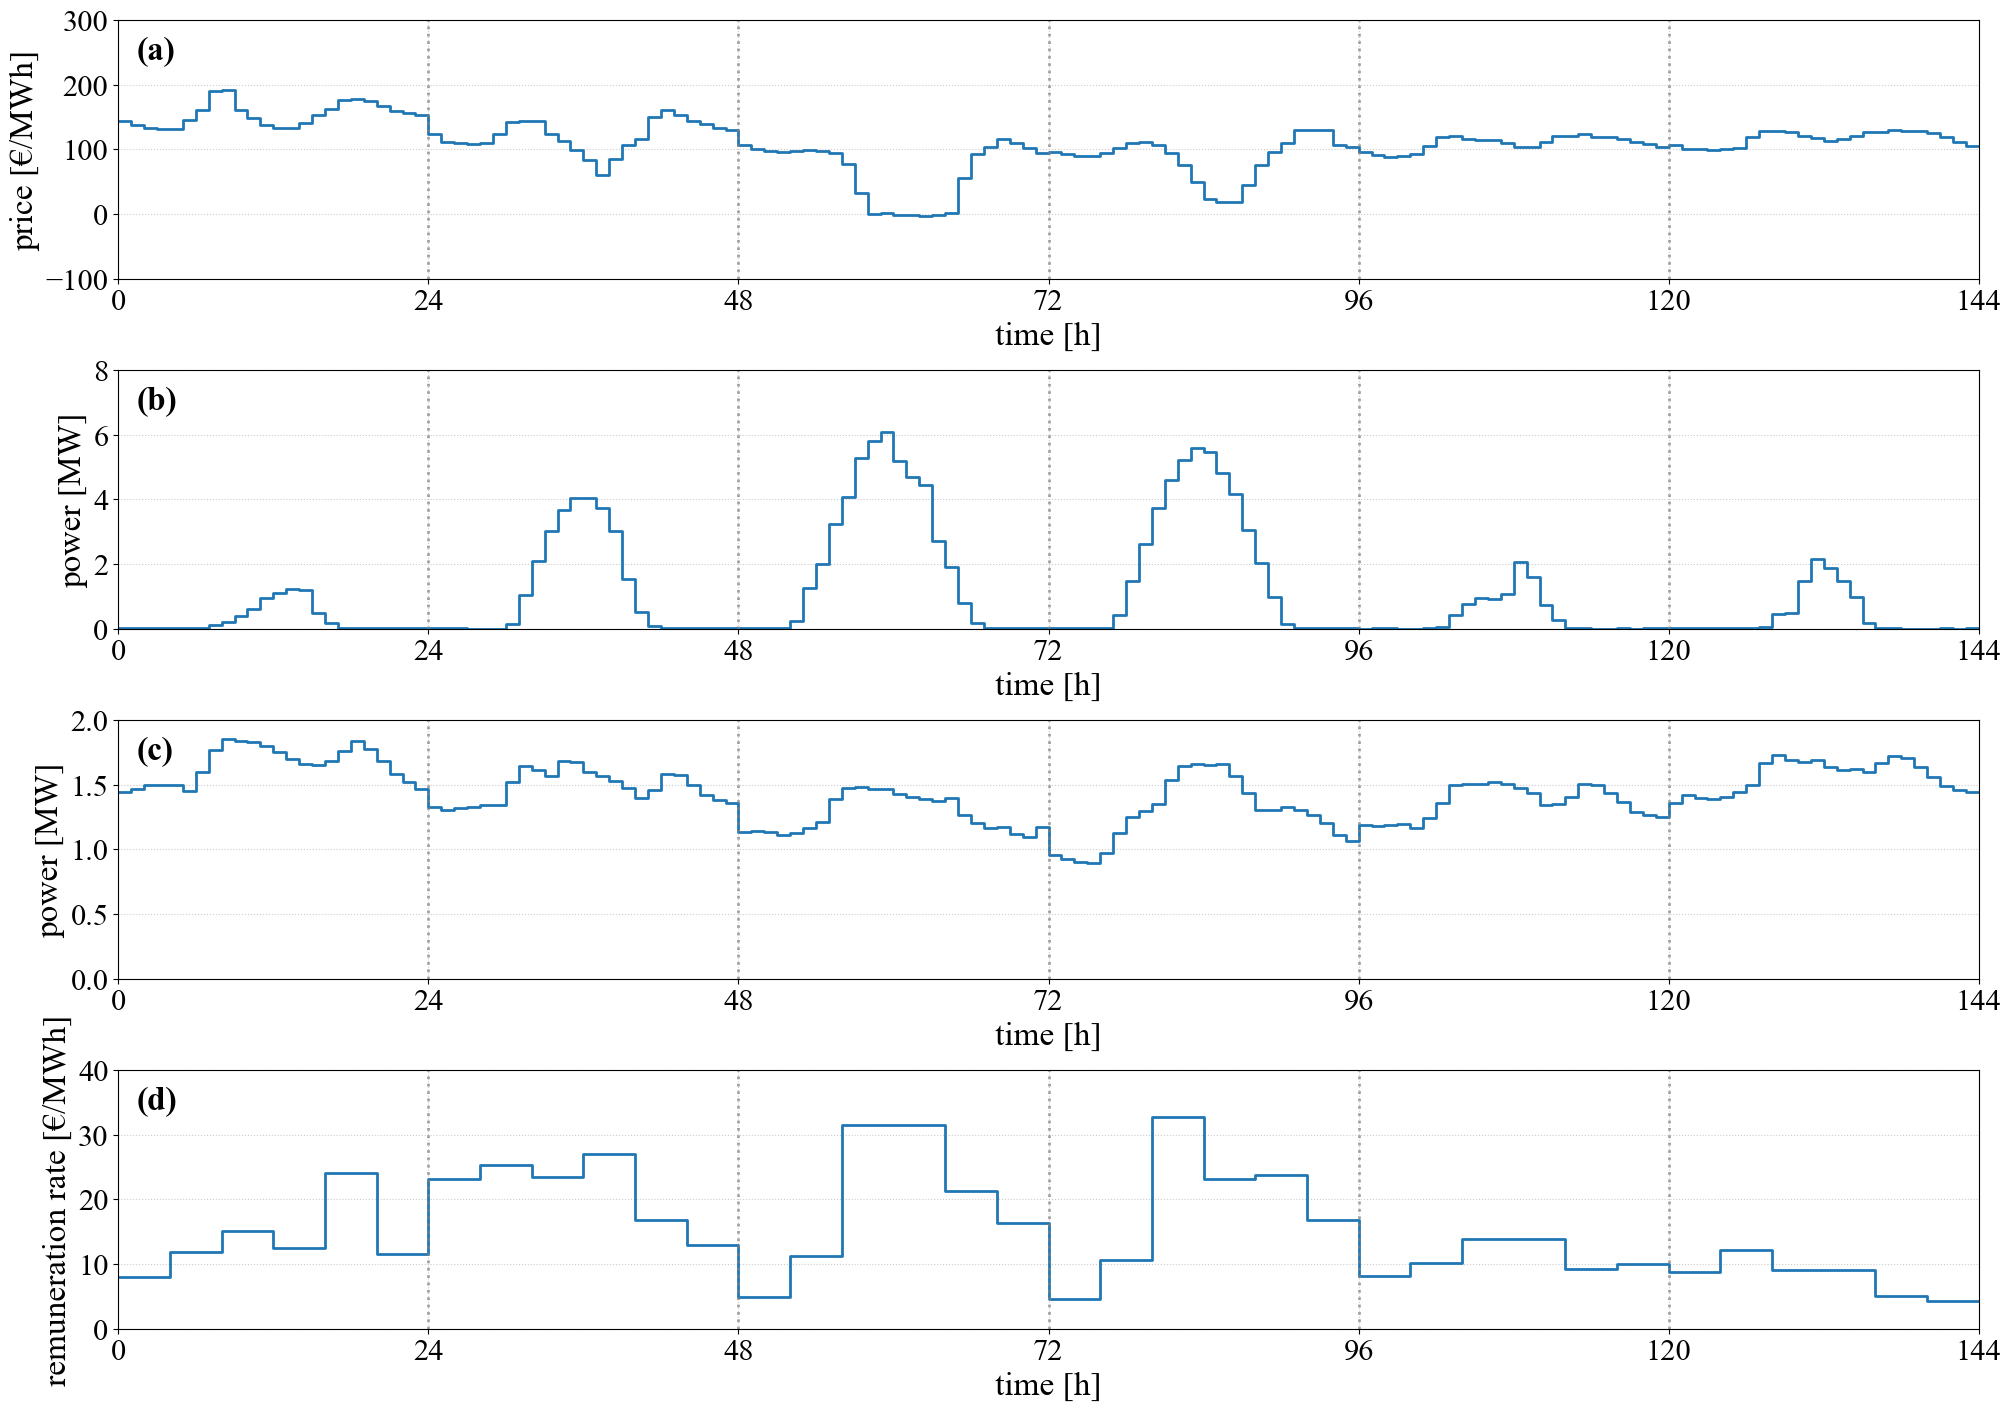

In [36]:
# INPUT PLOTS FOR PAPER -----------------------------------------------------------------------------------
# TIME WINDOW - SINGLE SCENARIO
scen = 0
# time_plot_tdays = np.arange(0, N_t * N_d + 2)

C_ele_prof = C_ele_vals[scen, :, :].reshape(-1)
C_ele_prof = np.append(C_ele_prof, C_ele_prof[-1])
Ppv_prof = Ppv_vals[scen, :, :].reshape(-1)
Ppv_prof = np.append(Ppv_prof, Ppv_prof[-1])
Pload_prof = Pload_vals[scen, :, :].reshape(-1)
Pload_prof = np.append(Pload_prof, Pload_prof[-1])
C_FCR_prof = C_FCR_capup_vals[scen, :, :].reshape(-1)
C_FCR_prof = np.append(C_FCR_prof, C_FCR_prof[-1])

figIN4P, axsIN4P = plt.subplots(4, 1, layout='constrained', figsize = (20, 14))
# Electricity cost plot
axsIN4P[0].step(time_plot_tdays, C_ele_prof, where='post', color = muted_blue, label = f'scenario {scen}')
axsIN4P[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN4P[0].set_xlim(0, 144)
axsIN4P[0].set_ylim(-100, 300)
axsIN4P[0].set_xlabel('time [h]')
axsIN4P[0].set_ylabel('price [€/MWh]')
# axsIN4P[0].set_title("Electricity price profile")
# axsIN4P[0].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN4P[0].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
axsIN4P[0].text(0.01, 0.94, '(a)', transform=axsIN4P[0].transAxes,
                fontsize=24, fontweight='bold', va='top', ha='left')

# PV power plot
axsIN4P[1].step(time_plot_tdays, Ppv_prof, where='post', color = muted_blue, label = f'scenario {scen}')
axsIN4P[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN4P[1].set_xlim(0, 144)
axsIN4P[1].set_ylim(0, 8)
axsIN4P[1].set_xlabel('time [h]')
axsIN4P[1].set_ylabel('power [MW]')
# axsIN4P[1].set_title("PV power generation")
# axsIN4P[1].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN4P[1].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
axsIN4P[1].text(0.01, 0.94, '(b)', transform=axsIN4P[1].transAxes,
                fontsize=24, fontweight='bold', va='top', ha='left')

# Load power plot
axsIN4P[2].step(time_plot_tdays, Pload_prof, where='post', color = muted_blue, label = f'scenario {scen}')
axsIN4P[2].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN4P[2].set_ylim(0, 2)
axsIN4P[2].set_xlabel('time [h]')
axsIN4P[2].set_ylabel('power [MW]')
# axsIN4P[2].set_title("Load power profile")
axsIN4P[2].set_xlim(0, 144)
axsIN4P[2].set_ylim(0, 2)
# axsIN4P[2].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN4P[2].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
axsIN4P[2].text(0.01, 0.94, '(c)', transform=axsIN4P[2].transAxes,
                fontsize=24, fontweight='bold', va='top', ha='left')

# FCR remuneration rate plot
axsIN4P[3].step(time_plot_tdays, C_FCR_prof, where='post', color = muted_blue, label = f'scenario {scen}')
axsIN4P[3].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN4P[3].set_xlabel('time [h]')
axsIN4P[3].set_ylabel('remuneration rate [€/MWh]')
# axsIN4P[3].set_title("FCR remuneration rate profile (upward regulation)")
axsIN4P[3].set_xlim(0, 144)
axsIN4P[3].set_ylim(0, 40)
# axsIN4P[3].legend()
for day in range(1, N_d):
    x_pos = day * 24
    axsIN4P[3].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
axsIN4P[3].text(0.01, 0.94, '(d)', transform=axsIN4P[3].transAxes,
                fontsize=24, fontweight='bold', va='top', ha='left')

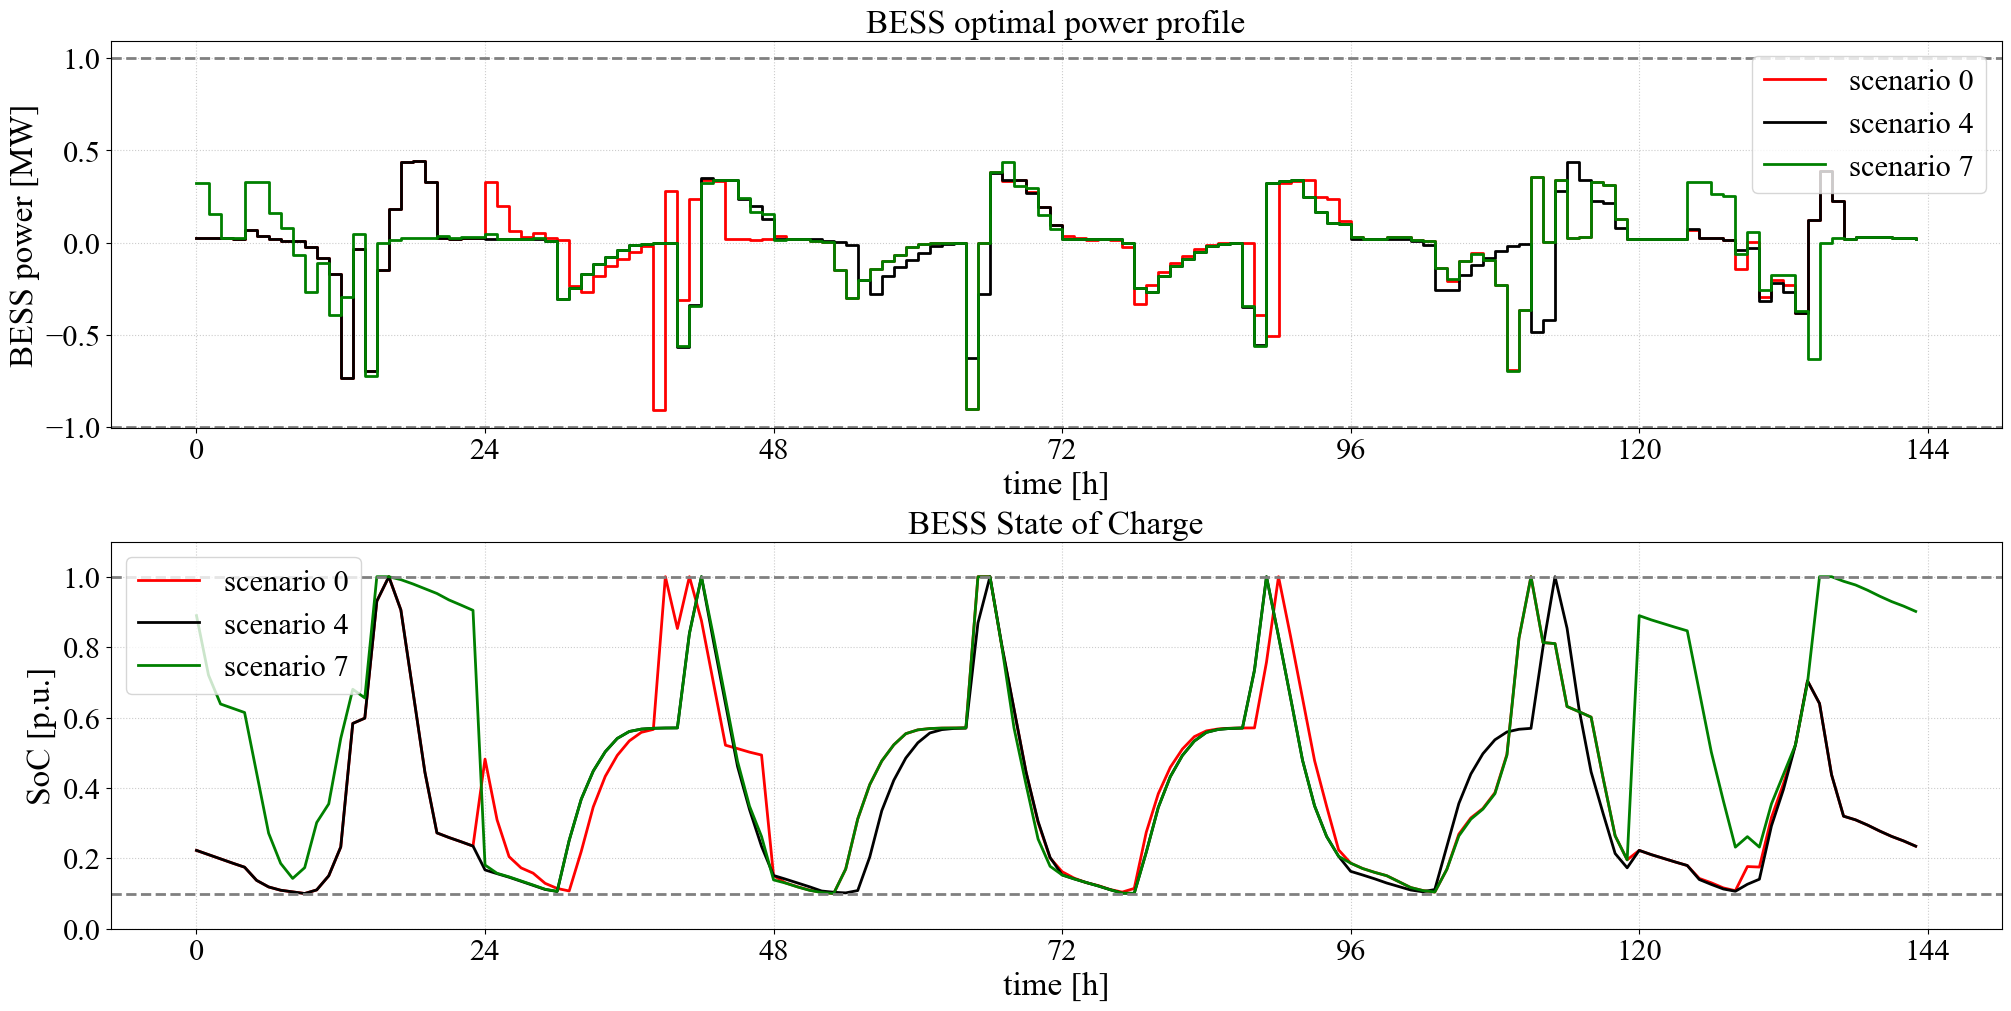

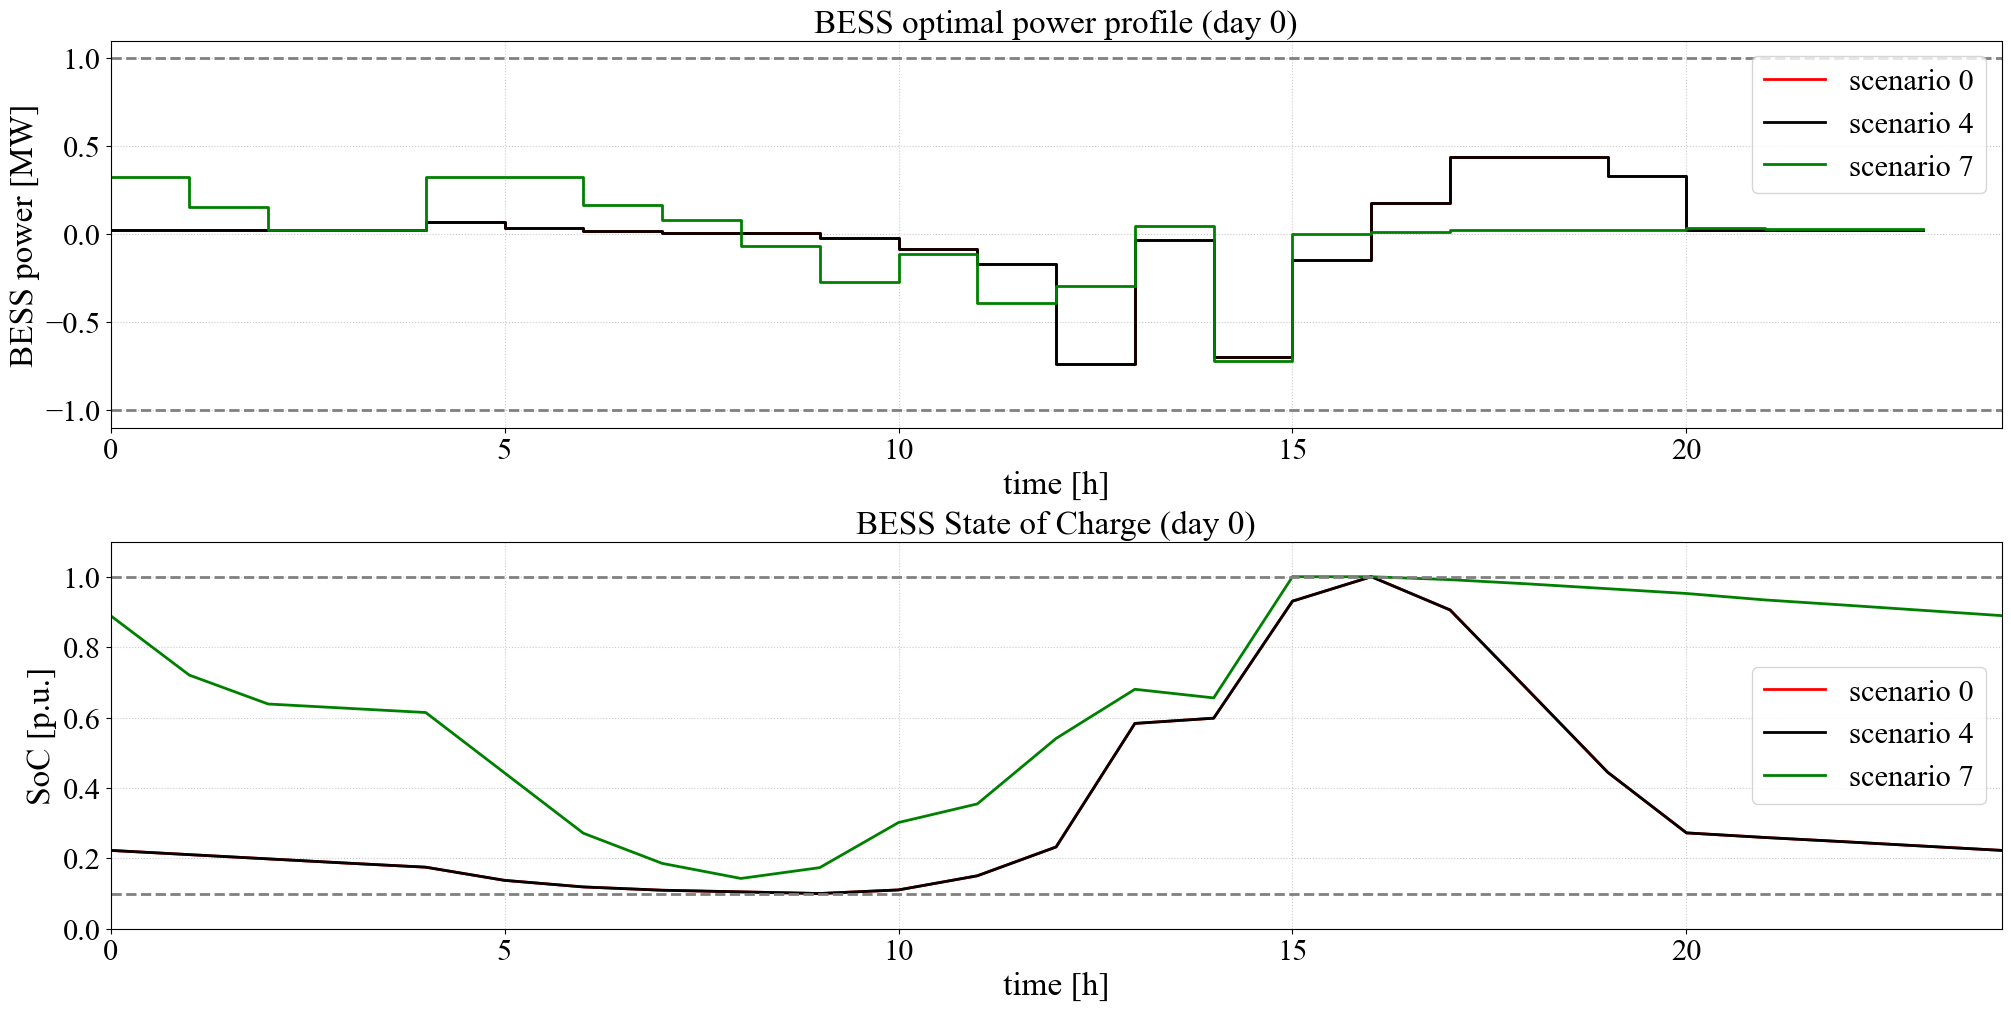

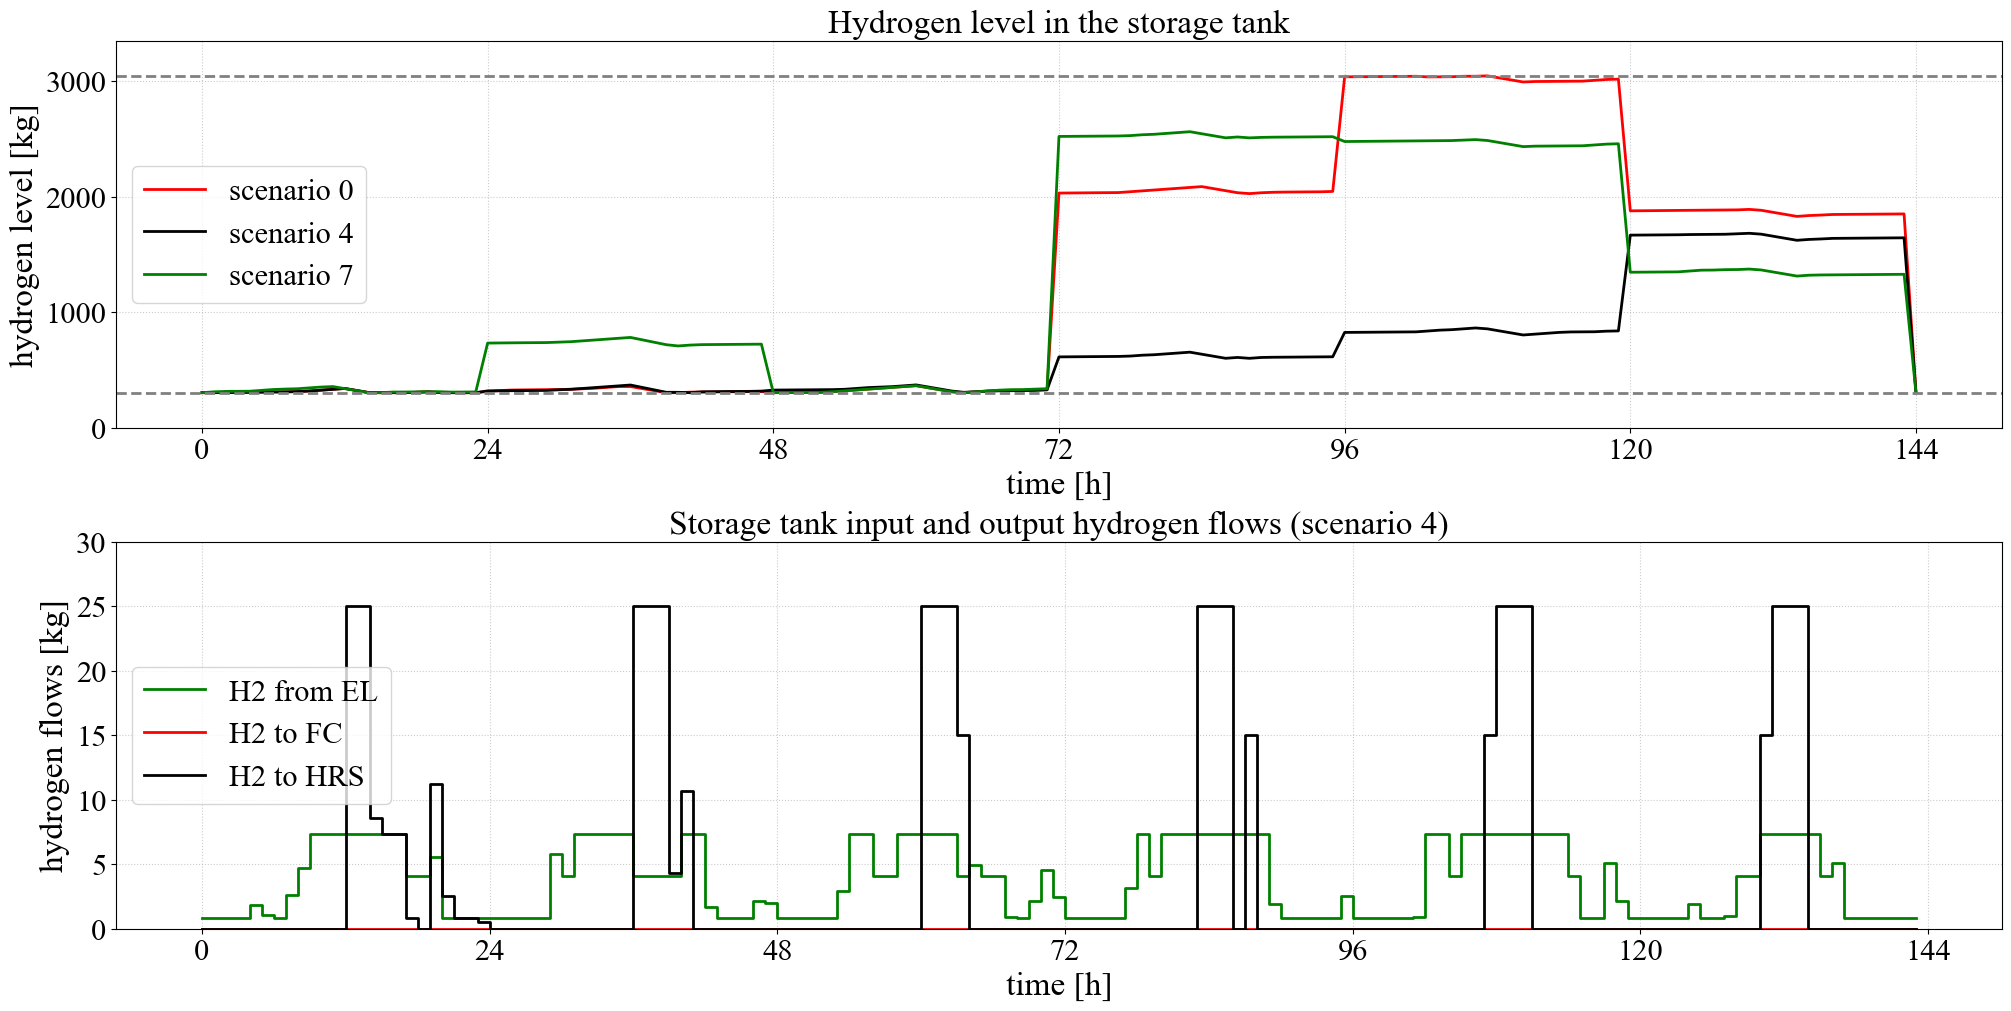

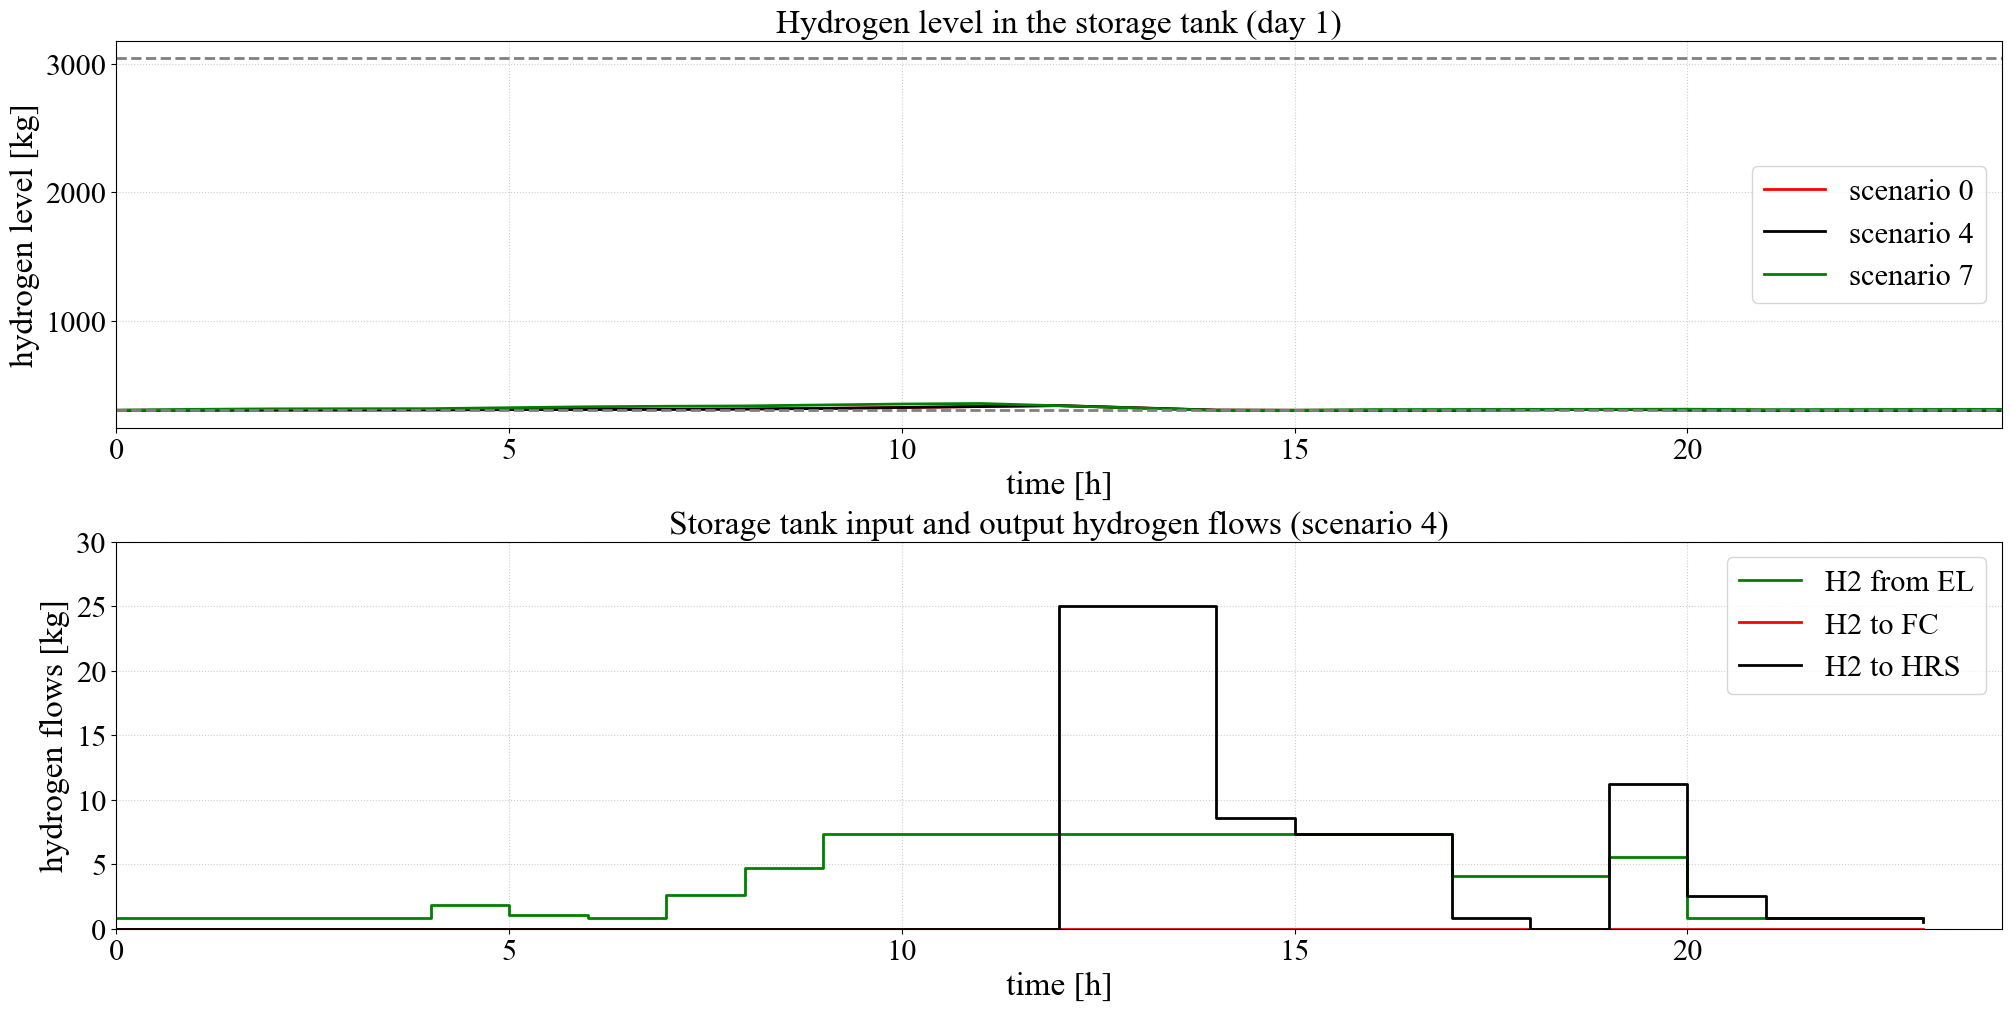

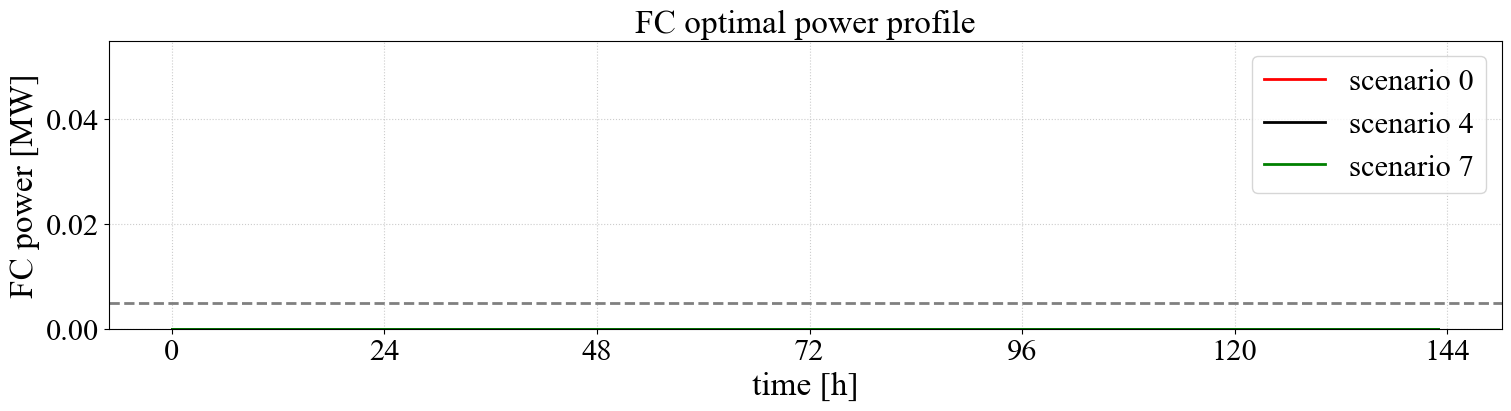

In [37]:
#------------------------------------------------------------------------------------------------
# PLOTTING (2/5)
#------------------------------------------------------------------------------------------------

# BESS PLOTS ------------------------------------------------------------------------------------
# TIME WINDOW
# BESS power plot
figBESS, axsBESS = plt.subplots(2, 1, layout='constrained')
axsBESS[0].step(time_plot_tdays[:-1], pb_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsBESS[0].step(time_plot_tdays[:-1], pb_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsBESS[0].step(time_plot_tdays[:-1], pb_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsBESS[0].axhline(y=Cb_mw_val, color = 'grey', linestyle = '--')
axsBESS[0].axhline(y=-Cb_mw_val, color = 'grey', linestyle = '--')
axsBESS[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS[0].set_xlabel('time [h]')
axsBESS[0].set_ylabel('BESS power [MW]')
axsBESS[0].set_title('BESS optimal power profile')
axsBESS[0].legend()
# BESS SoC plot
axsBESS[1].plot(time_plot_tdays[:-1], soc_vals[scenarios[0], :, :-1].reshape(-1), color = 'red', label = f'scenario {scenarios[0]}')
axsBESS[1].plot(time_plot_tdays[:-1], soc_vals[scenarios[1], :, :-1].reshape(-1), color = 'black', label = f'scenario {scenarios[1]}')
axsBESS[1].plot(time_plot_tdays[:-1], soc_vals[scenarios[2], :, :-1].reshape(-1), color = 'green', label = f'scenario {scenarios[2]}')
axsBESS[1].axhline(y=1, color = 'grey', linestyle = '--')
axsBESS[1].axhline(y=alfa_b_dod, color = 'grey', linestyle = '--')
axsBESS[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS[1].set_xlabel('time [h]')
axsBESS[1].set_ylabel('SoC [p.u.]')
axsBESS[1].set_title('BESS State of Charge')
axsBESS[1].set_ylim(0, 1.1)
axsBESS[1].legend()
# # BESS operating states plot
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], pb_dch_vals[week*24*7 : (week+1)*24*7] - pb_ch_vals[week*24*7 : (week+1)*24*7], color = 'blue')
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], 0.5*xb_vals[week*24*7 : (week+1)*24*7], color = 'black')

# CHOSEN DAY
# BESS power plot
figBESS2, axsBESS2 = plt.subplots(2, 1, layout='constrained')
axsBESS2[0].step(time_plot[:-1], pb_vals[scenarios[0], day_2plot, :], where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsBESS2[0].step(time_plot[:-1], pb_vals[scenarios[1], day_2plot, :], where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsBESS2[0].step(time_plot[:-1], pb_vals[scenarios[2], day_2plot, :], where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsBESS2[0].axhline(y=Cb_mw_val, color = 'grey', linestyle = '--')
axsBESS2[0].axhline(y=-Cb_mw_val, color = 'grey', linestyle = '--')
axsBESS2[0].set_xlabel('time [h]')
axsBESS2[0].set_ylabel('BESS power [MW]')
axsBESS2[0].set_title(f'BESS optimal power profile (day {day_2plot})')
axsBESS2[0].set_xlim(0, 24)
axsBESS2[0].legend()
# BESS SoC plot
axsBESS2[1].plot(time_plot, soc_vals[scenarios[0], day_2plot, :], color = 'red', label = f'scenario {scenarios[0]}')
axsBESS2[1].plot(time_plot, soc_vals[scenarios[1], day_2plot, :], color = 'black', label = f'scenario {scenarios[1]}')
axsBESS2[1].plot(time_plot, soc_vals[scenarios[2], day_2plot, :], color = 'green', label = f'scenario {scenarios[2]}')
axsBESS2[1].axhline(y=1, color = 'grey', linestyle = '--')
axsBESS2[1].axhline(y=alfa_b_dod, color = 'grey', linestyle = '--')
axsBESS2[1].set_xlabel('time [h]')
axsBESS2[1].set_ylabel('SoC [p.u.]')
axsBESS2[1].set_title(f'BESS State of Charge (day {day_2plot})')
axsBESS2[1].set_ylim(0, 1.1)
axsBESS2[1].set_xlim(0, 24)
axsBESS2[1].legend()


# HYDROGEN STORAGE PLOTS ------------------------------------------------------------------------
# TIME WINDOW
# HSS hydrogen level plot
figHSS, axsHSS = plt.subplots(2, 1, layout='constrained')
# axsHSS[0].plot(time_plot_tdays[:-1], hhss_vals[scenarios[0], :, :-1].reshape(-1), color = 'black')
axsHSS[0].plot(time_plot_tdays, np.append(hhss_vals[scenarios[0], :, :-1].reshape(-1), hhss_seas_vals[scenarios[0], -1, -1]),
                color = 'red', label = f'scenario {scenarios[0]}')
axsHSS[0].plot(time_plot_tdays, np.append(hhss_vals[scenarios[1], :, :-1].reshape(-1), hhss_seas_vals[scenarios[1], -1, -1]),
                color = 'black', label = f'scenario {scenarios[1]}')
axsHSS[0].plot(time_plot_tdays, np.append(hhss_vals[scenarios[2], :, :-1].reshape(-1), hhss_seas_vals[scenarios[2], -1, -1]),
                color = 'green', label = f'scenario {scenarios[2]}')
axsHSS[0].axhline(y=Chss_val, color = 'grey', linestyle = '--')
axsHSS[0].axhline(y=alfa_hss_min * Chss_val, color = 'grey', linestyle = '--')
axsHSS[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsHSS[0].set_xlabel('time [h]')
axsHSS[0].set_ylabel('hydrogen level [kg]')
axsHSS[0].set_title("Hydrogen level in the storage tank")
axsHSS[0].set_ylim(0, 1.1 * Chss_val)
axsHSS[0].legend()
# Input and outputs of the HSS (without efficiencies)
axsHSS[1].step(time_plot_tdays[:-1], hel_vals[scenarios[1], :, :].reshape(-1), color = 'green', label = 'H2 from EL', where='post')
axsHSS[1].step(time_plot_tdays[:-1], hfc_vals[scenarios[1], :, :].reshape(-1), color = 'red', label = 'H2 to FC', where='post')
axsHSS[1].step(time_plot_tdays[:-1], hdem_vals[scenarios[1], :, :].reshape(-1), color = 'black', label = 'H2 to HRS', where='post')
axsHSS[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsHSS[1].set_xlabel('time [h]')
axsHSS[1].set_ylabel('hydrogen flows [kg]')
axsHSS[1].set_title(f'Storage tank input and output hydrogen flows (scenario {scenarios[1]})')
axsHSS[1].set_ylim(0, 30)
axsHSS[1].legend()

# CHOSEN DAY
# HSS hydrogen level plot
figHSS2, axsHSS2 = plt.subplots(2, 1, layout='constrained')
axsHSS2[0].plot(time_plot, hhss_vals[scenarios[0], day_2plot, :], color = 'red', label = f'scenario {scenarios[0]}')
axsHSS2[0].plot(time_plot, hhss_vals[scenarios[1], day_2plot, :], color = 'black', label = f'scenario {scenarios[1]}')
axsHSS2[0].plot(time_plot, hhss_vals[scenarios[2], day_2plot, :], color = 'green', label = f'scenario {scenarios[2]}')
axsHSS2[0].axhline(y=Chss_val, color = 'grey', linestyle = '--')
axsHSS2[0].axhline(y=alfa_hss_min * Chss_val, color = 'grey', linestyle = '--')
axsHSS2[0].set_xlabel('time [h]')
axsHSS2[0].set_ylabel('hydrogen level [kg]')
axsHSS2[0].set_title(f"Hydrogen level in the storage tank (day {day_2plot + 1})")
# axsHSS2[0].set_ylim(0.95 * min(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]), 1.05 * max(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]))
axsHSS2[0].set_xlim(0, 24)
axsHSS2[0].legend()
# Input and outputs of the HSS (without efficiencies)
axsHSS2[1].step(time_plot[:-1], hel_vals[scenarios[1], day_2plot, :], color = 'green', label = 'H2 from EL', where='post')
axsHSS2[1].step(time_plot[:-1], hfc_vals[scenarios[1], day_2plot, :], color = 'red', label = 'H2 to FC', where='post')
axsHSS2[1].step(time_plot[:-1], hdem_vals[scenarios[1], day_2plot, :], color = 'black', label = 'H2 to HRS', where='post')
axsHSS2[1].set_xlabel('time [h]')
axsHSS2[1].set_ylabel('hydrogen flows [kg]')
axsHSS2[1].set_title(f'Storage tank input and output hydrogen flows (scenario {scenarios[1]})')
axsHSS2[1].set_ylim(0, 30)
axsHSS2[1].set_xlim(0, 24)
axsHSS2[1].legend()


# FC power plot
figFC, axsFC = plt.subplots(layout='constrained', figsize=(15, 4))
axsFC.step(time_plot_tdays[:-1], pfc_vals[scenarios[0], :, :].reshape(-1), where='post', color = 'red', label = f'scenario {scenarios[0]}')
axsFC.step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :, :].reshape(-1), where='post', color = 'black', label = f'scenario {scenarios[1]}')
axsFC.step(time_plot_tdays[:-1], pfc_vals[scenarios[2], :, :].reshape(-1), where='post', color = 'green', label = f'scenario {scenarios[2]}')
axsFC.axhline(y=alfa_fc_min * Cfc_val, color = 'grey', linestyle = '--')
axsFC.set_xticks([day * 24 for day in range(N_d + 1)])
axsFC.set_xlabel('time [h]')
axsFC.set_ylabel('FC power [MW]')
axsFC.set_title("FC optimal power profile")
axsFC.set_ylim(0, 1.1 * Cfc_val)
axsFC.legend()

Scenario 0


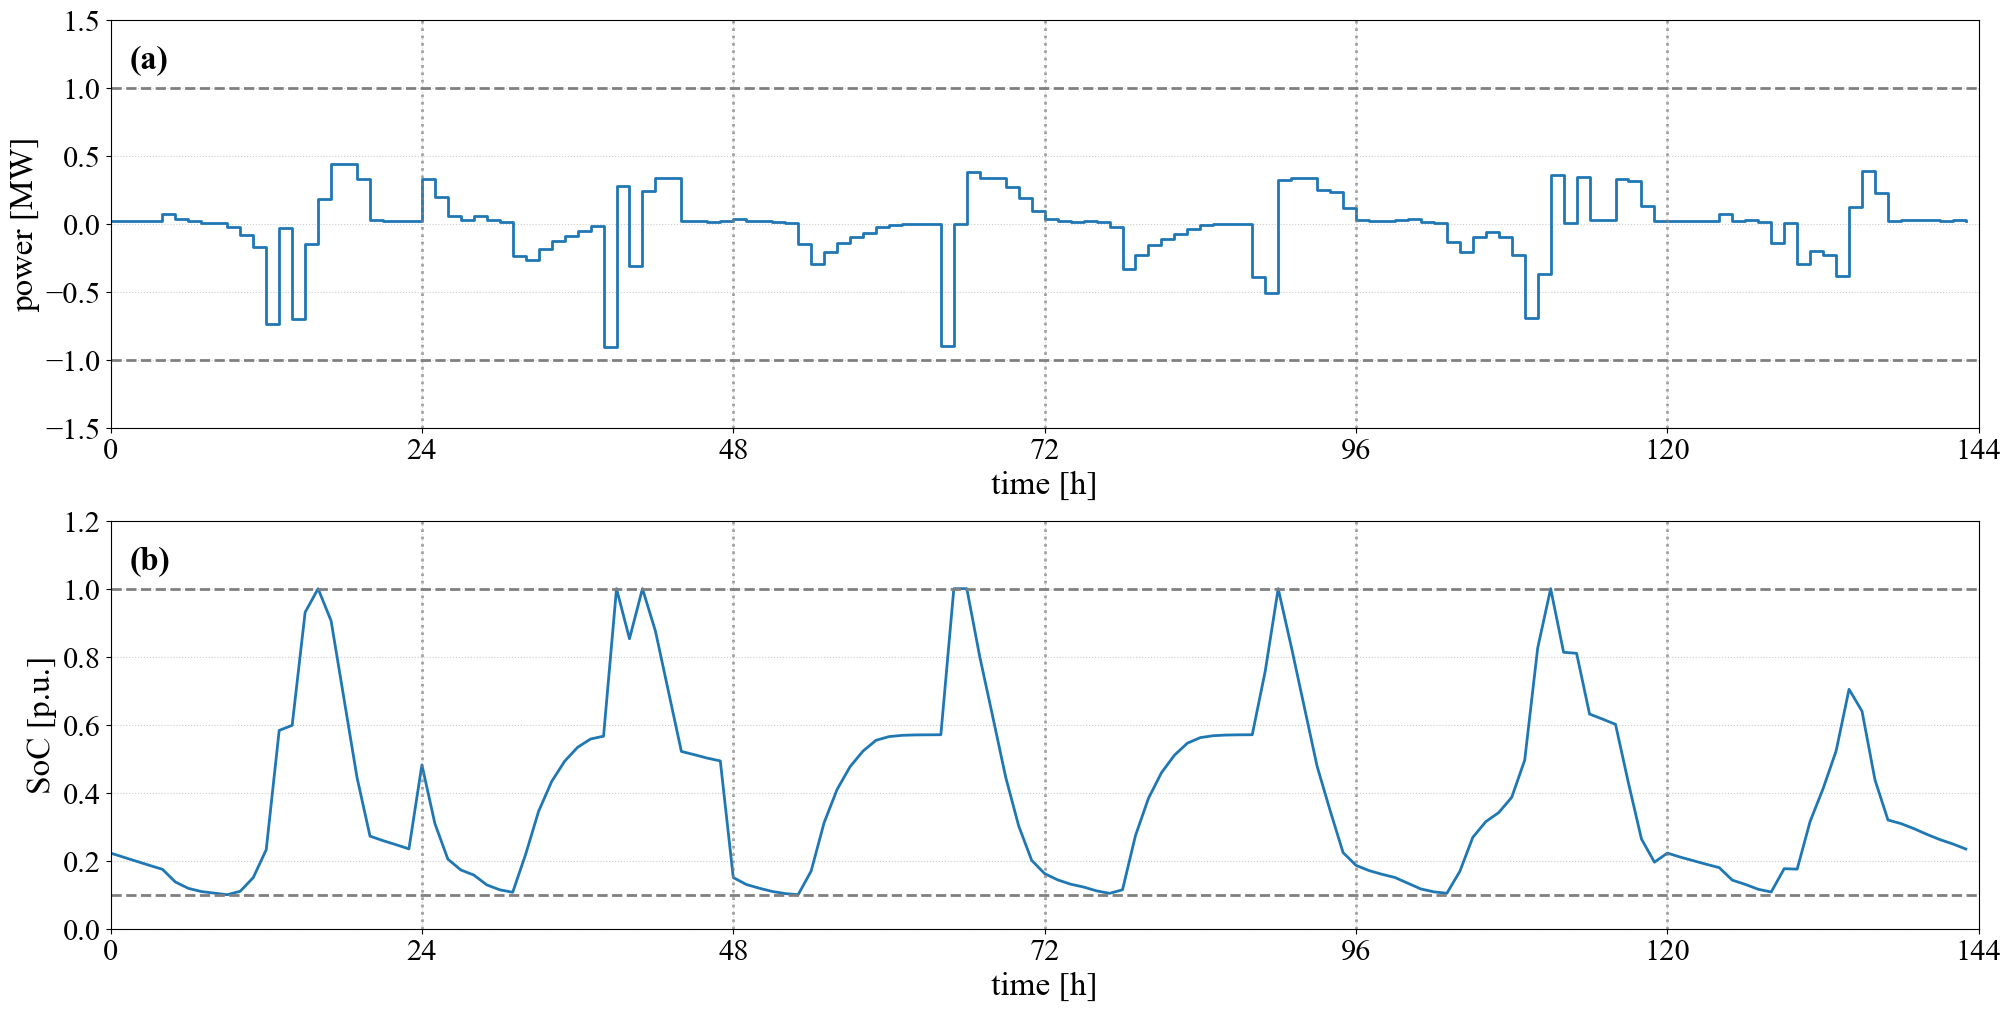

In [38]:
# BESS PLOTS FOR PAPER ------------------------------------------------------------------------------------
# TIME WINDOW - SINGLE SCENARIO -----
scen = 0

p_b = pb_vals[scen, :].reshape(-1)
p_b = np.append(p_b, p_b[-1])
soc = soc_vals[scen, :].reshape(-1)

# BESS power plot
figBESS4P, axsBESS4P = plt.subplots(2, 1, layout='constrained', figsize = (20, 10))
axsBESS4P[0].step(time_plot_tdays[:-1], pb_vals[scen, :, :].reshape(-1), where='post', color = muted_blue, label = f'scenario {scen}')
axsBESS4P[0].axhline(y=Cb_mw_val, color = 'grey', linestyle = '--')
axsBESS4P[0].axhline(y=-Cb_mw_val, color = 'grey', linestyle = '--')
axsBESS4P[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS4P[0].set_xlim(0, 144)
axsBESS4P[0].set_yticks(np.arange(-1.5, 2, 0.5))
axsBESS4P[0].set_ylim(-1.5, 1.5)
axsBESS4P[0].set_xlabel('time [h]')
axsBESS4P[0].set_ylabel('power [MW]')
# axsBESS4P[0].set_title('BESS optimal power profile')
# axsBESS4P[0].legend()
# Add vertical dotted lines to separate typical days
for day in range(1, N_d):
    x_pos = day * 24
    axsBESS4P[0].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7
    )
axsBESS4P[0].text(0.01, 0.94, '(a)', transform=axsBESS4P[0].transAxes,
                fontsize=24, fontweight='bold', va='top', ha='left')


# BESS SoC plot
axsBESS4P[1].plot(time_plot_tdays[:-1], soc_vals[scen, :, :-1].reshape(-1), color = muted_blue, label = f'scenario {scen}')
axsBESS4P[1].axhline(y=1, color = 'grey', linestyle = '--')
axsBESS4P[1].axhline(y=alfa_b_dod, color = 'grey', linestyle = '--')
axsBESS4P[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS4P[1].set_xlim(0, 144)
axsBESS4P[1].set_yticks(np.arange(0, 1.4, 0.2))
axsBESS4P[1].set_ylim(0, 1.2)
axsBESS4P[1].set_xlabel('time [h]')
axsBESS4P[1].set_ylabel('SoC [p.u.]')
# axsBESS4P[1].set_title('BESS State of Charge')
# axsBESS4P[1].legend()
# Add vertical dotted lines to separate typical days
for day in range(1, N_d):
    x_pos = day * 24
    axsBESS4P[1].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7
    )
axsBESS4P[1].text(0.01, 0.94, '(b)', transform=axsBESS4P[1].transAxes,
                fontsize=24, fontweight='bold', va='top', ha='left')

print(f'Scenario {scen}')

Scenarios [0, 4, 7]


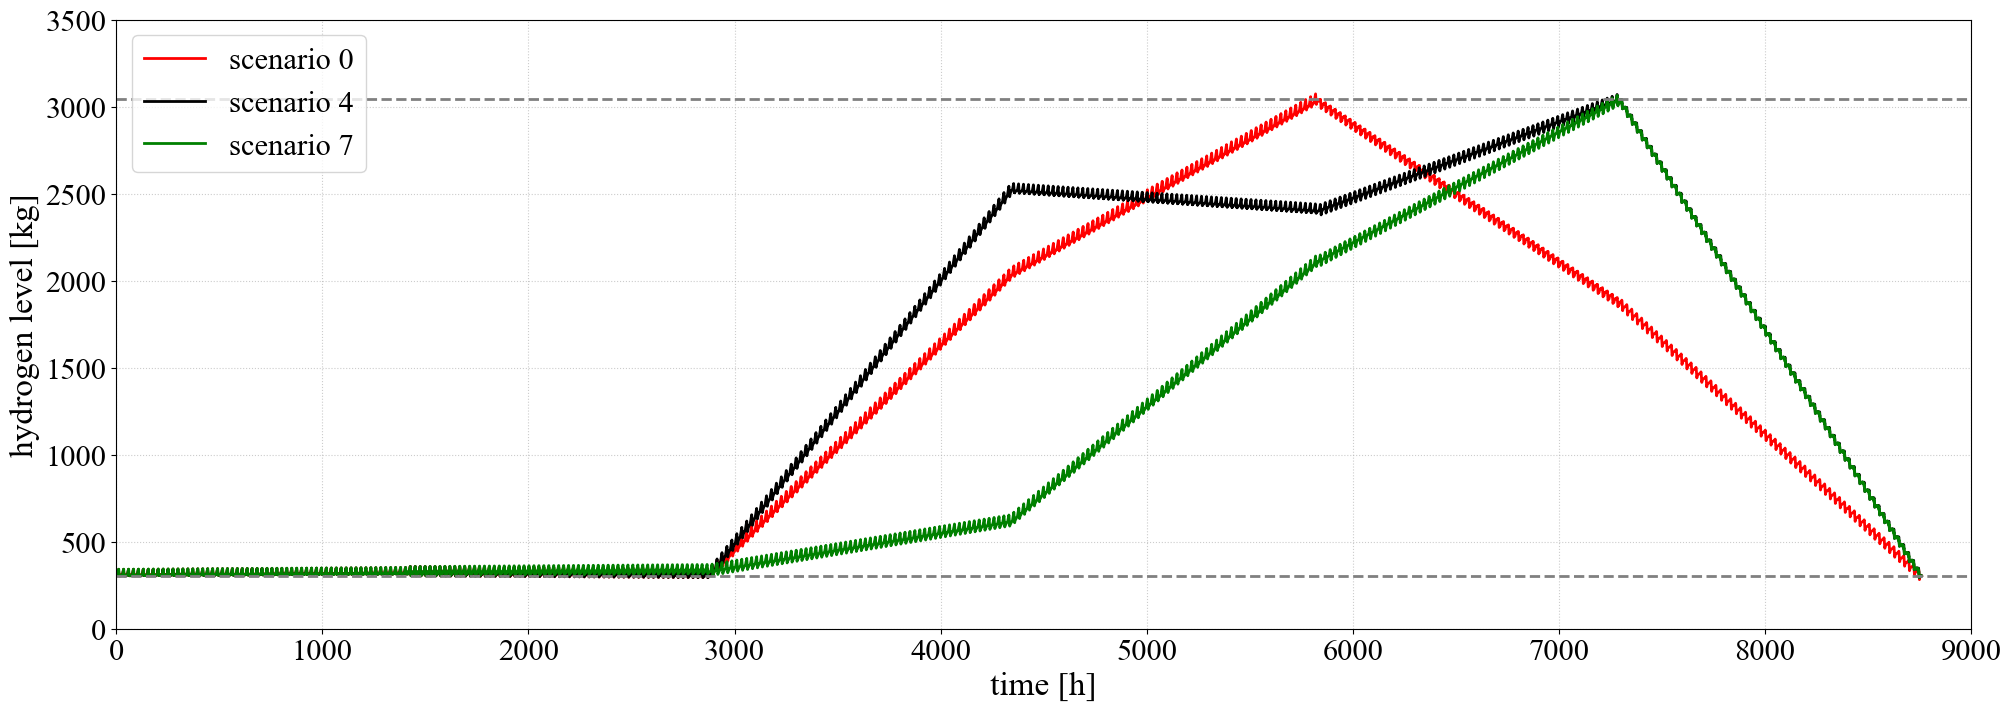

In [46]:
# HYDROGEN STORAGE PLOTS FOR PAPER ------------------------------------------------------------------------
# TIME WINDOW - MULTIPLE SCENARIOS
# HSS hydrogen level plot
time_plot_year = np.arange(0, 8760)    # time array for full-year plotting
hhss_prof_real = np.zeros((len(scenarios), 8760))
for scen in range(len(scenarios)):
    # Evaluating the daily variations in H2 level
    hhss_prof = hhss_vals[scen, :, :]     # array of H2 level in scenario "scen"
    hhss_var_prof = np.zeros((N_d, N_t))    # array of the variation in H2 level in each typical day
    for td in range(N_d):
        hhss_var_prof[td, :] = hhss_prof[td, 1:] - hhss_prof[td, 0]
    
    # Creating the profile of the real hydrogen level throughout the year by cumulatively adding the variations of every typical day
    # for the number of actual days 
    day = 0
    hhss_checkpoint = hhss_prof[0, 0]
    for td in range(len(Dnum)):
        for rd in range(Dnum[td]):
            hhss_prof_real[scen, day * 24 : (day+1) * 24] = hhss_checkpoint + hhss_var_prof[td, :]
            
            hhss_checkpoint = hhss_prof_real[scen, (day+1) * 24 - 1]
            day += 1
    
figHSS4P, axsHSS4P = plt.subplots(layout='constrained', figsize = (20, 7))
# axsHSS[0].plot(time_plot_tdays[:-1], hhss_vals[scenarios[0], :, :-1].reshape(-1), color = 'black')
axsHSS4P.plot(time_plot_year, hhss_prof_real[0, :],
                color = 'red', label = f'scenario {scenarios[0]}')
axsHSS4P.plot(time_plot_year, hhss_prof_real[1, :],
                color = 'black', label = f'scenario {scenarios[1]}')
axsHSS4P.plot(time_plot_year, hhss_prof_real[2, :],
                color = 'green', label = f'scenario {scenarios[2]}')
axsHSS4P.axhline(y=Chss_val, color = 'grey', linestyle = '--')    # *1.01
axsHSS4P.axhline(y=alfa_hss_min * Chss_val, color = 'grey', linestyle = '--')
# axsHSS4P.set_xticks([day * 24 for day in range(N_d + 1)])
axsHSS4P.set_xlabel('time [h]')
axsHSS4P.set_ylabel('hydrogen level [kg]')
# axsHSS4P.set_title("Hydrogen level in the storage tank")
axsHSS4P.set_xlim(0, 9000)
axsHSS4P.set_ylim(0, 3500)
axsHSS4P.legend(loc = 'upper left')

print(f'Scenarios {scenarios}')


# # print(hhss_vals.shape)
# hhss_prof = hhss_vals[scen, :, :]     # array of H2 level in scenario "scen"
# # print(len(hhss_prof[0, :]))
# # print(hhss_prof)
# hhss_var_prof = np.zeros((N_d, N_t))    # array of the variation in H2 level in each typical day
# for td in range(N_d):
#     hhss_var_prof[td, :] = hhss_prof[td, 1:] - hhss_prof[td, 0]
# # print(Dnum)
# # print(len(hhss_prof[0, :]))
# # print(f'H2 level profiles in each typical day (from optimization):\n'
# #       f'{hhss_prof}')
# # print(hhss_var_prof)

# # Creating the profile of the real hydrogen level throughout the year by cumulatively adding the variations of every typical day
# # for the number of actual days 
# hhss_prof_real = np.zeros(8760)
# day = 0
# hhss_checkpoint = hhss_prof[0, 0]
# for td in range(len(Dnum)):
#     for rd in range(Dnum[td]):
#         hhss_prof_real[day * 24 : (day+1) * 24] = hhss_checkpoint + hhss_var_prof[td, :]
        
#         hhss_checkpoint = hhss_prof_real[(day+1) * 24 - 1]
#         day += 1
# # print(hhss_prof_real.tolist())
# # plt.plot(hhss_prof_real)


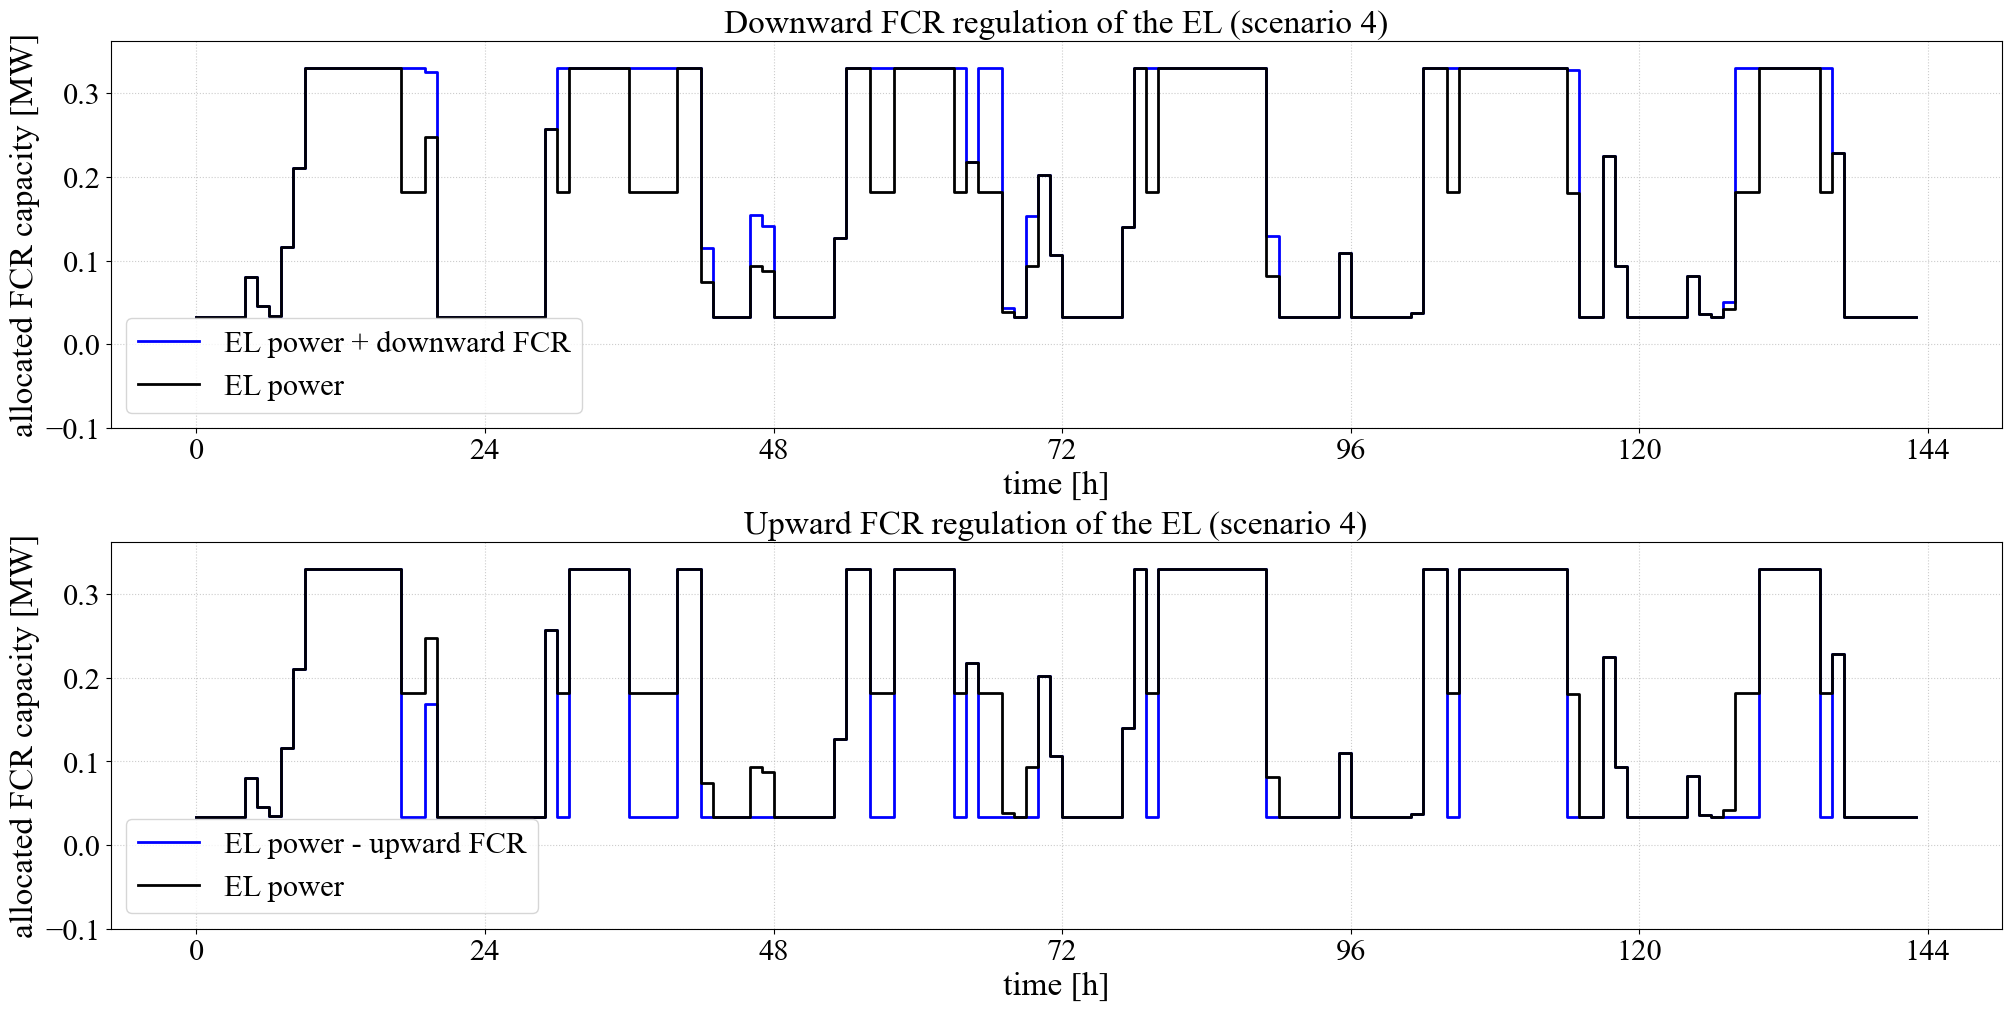

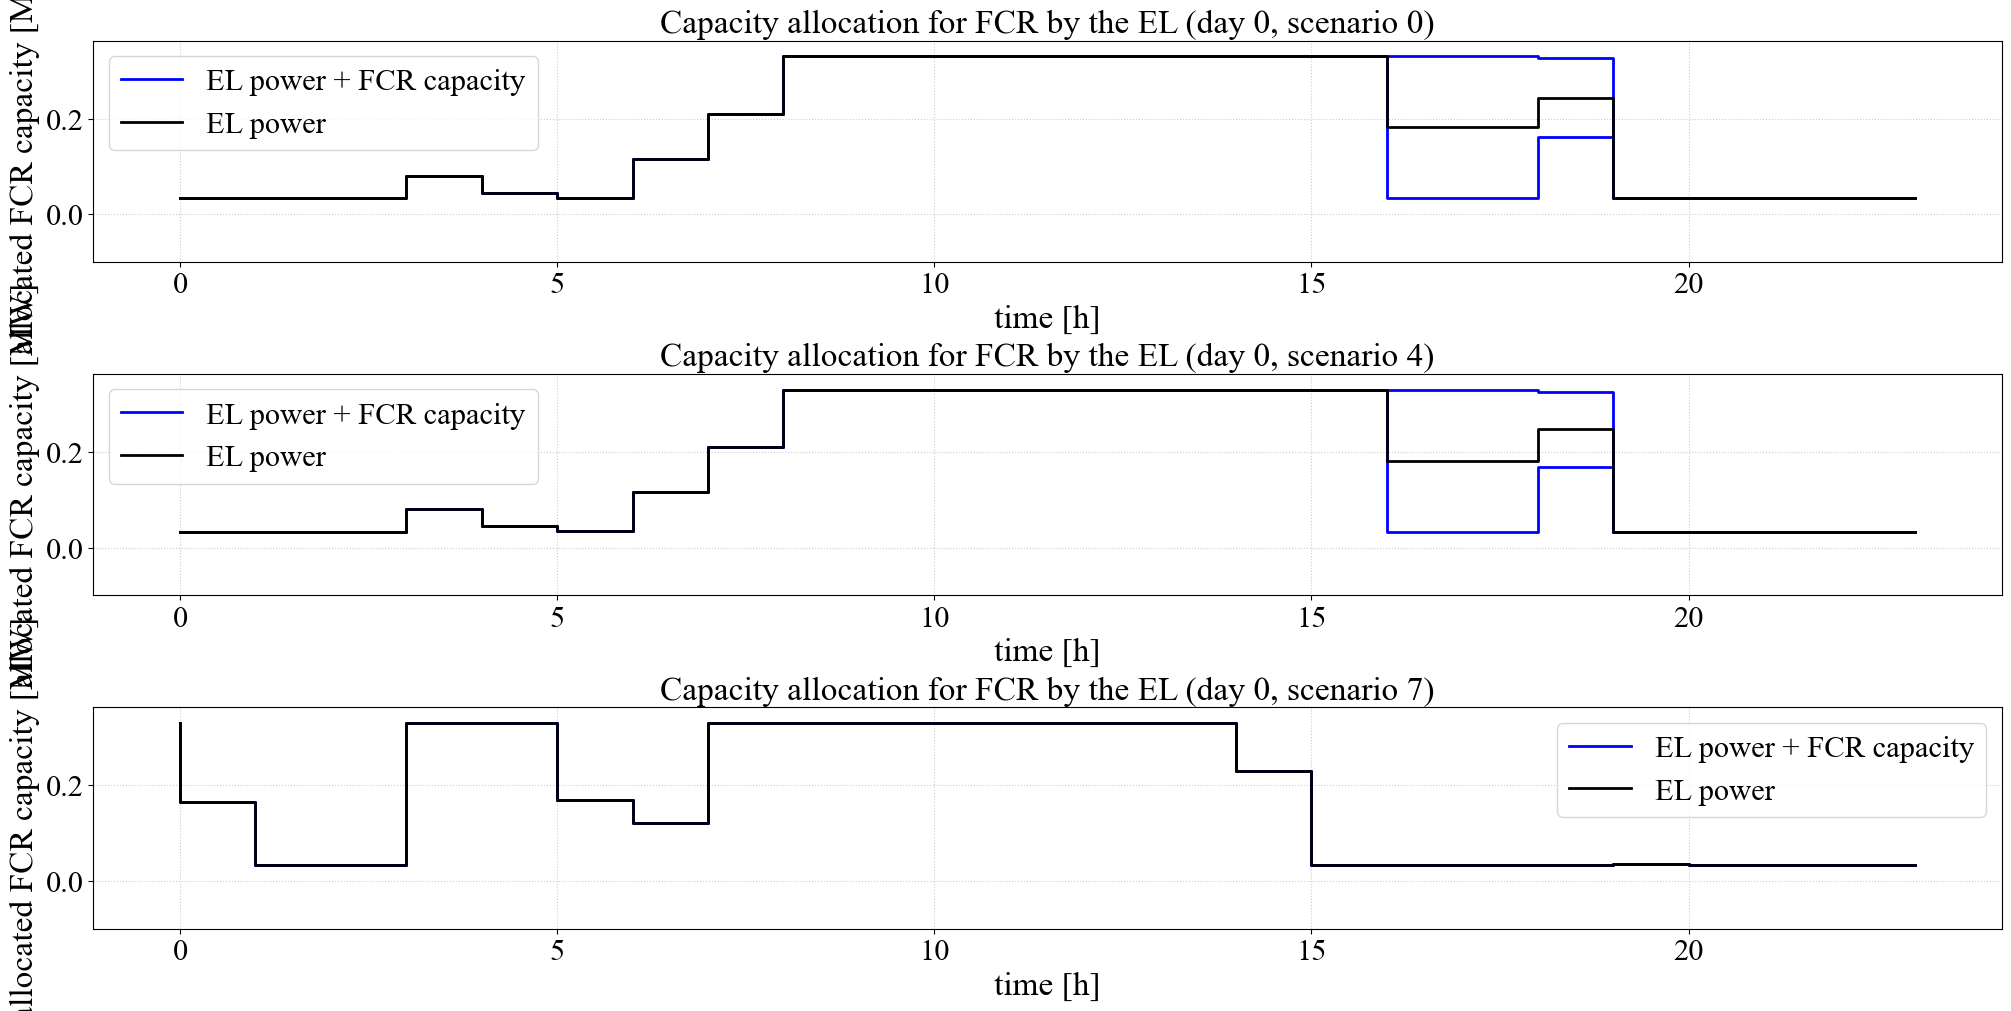

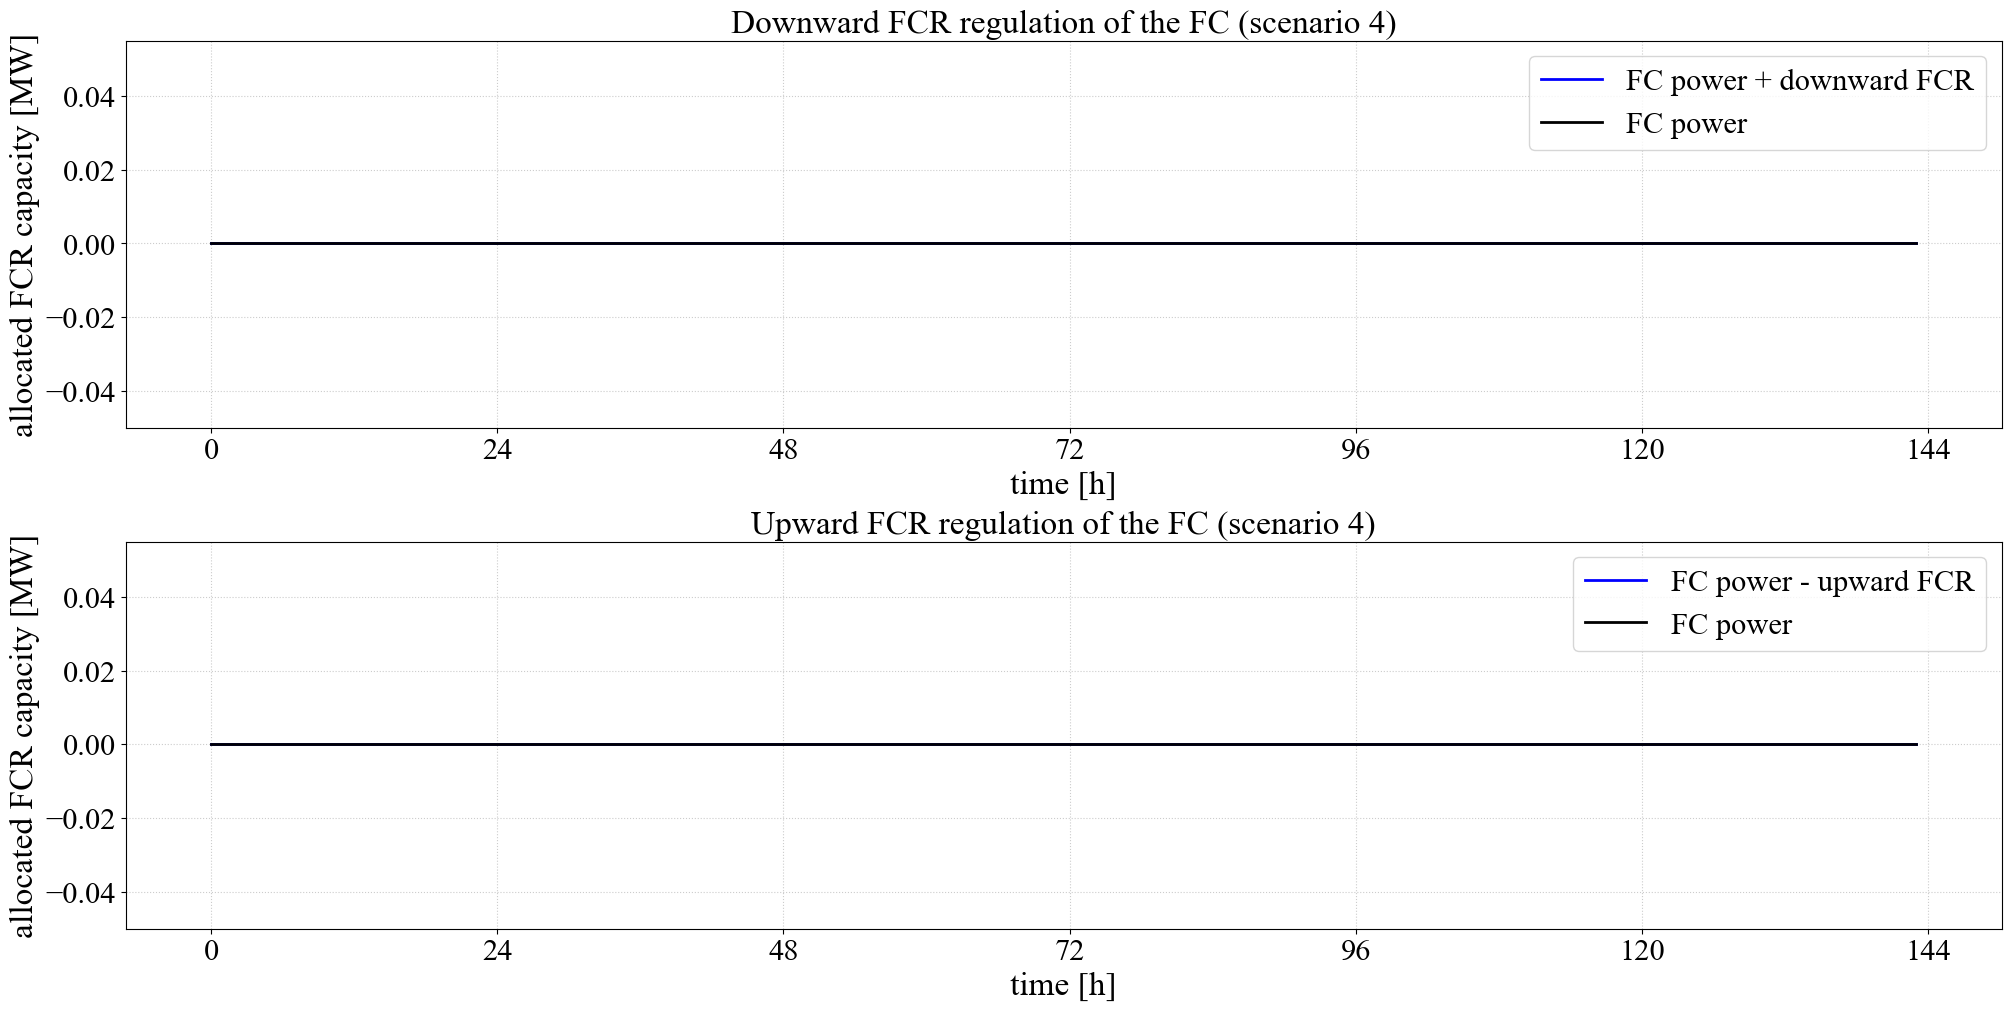

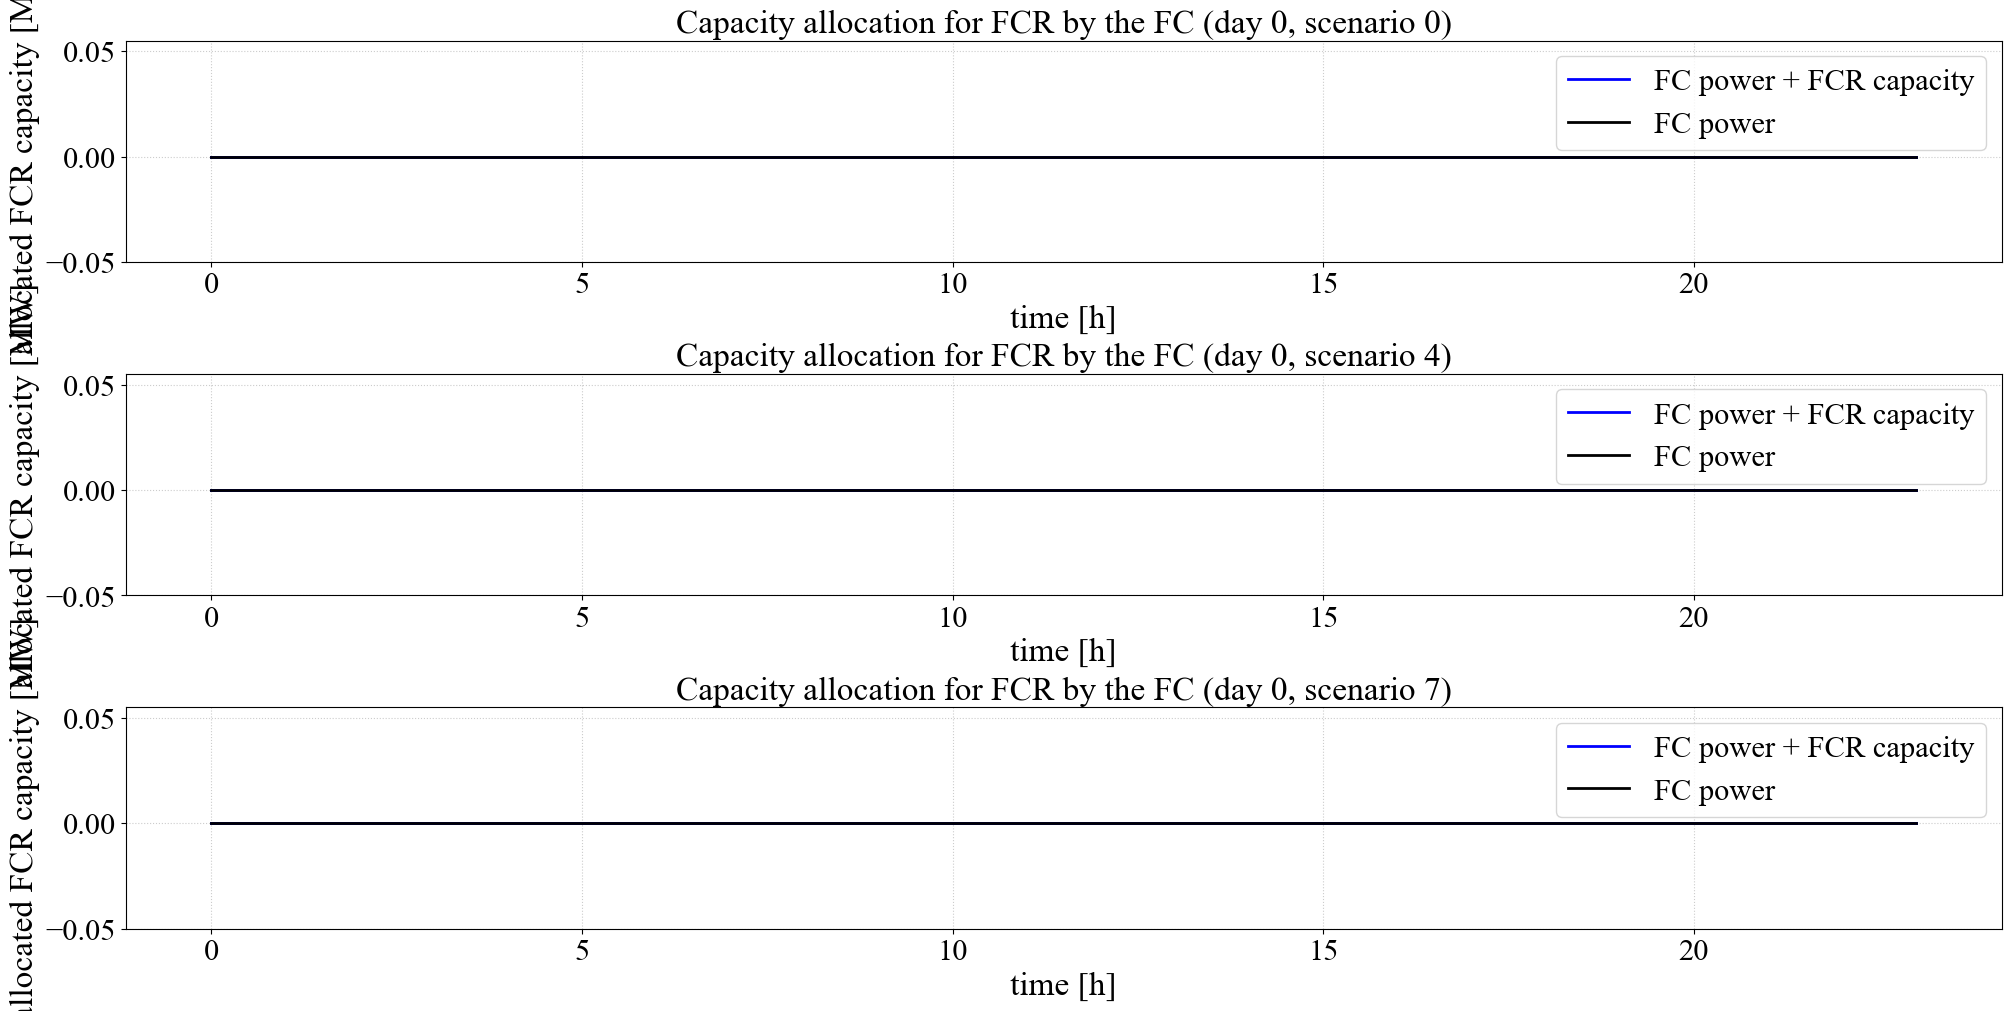

In [40]:
#------------------------------------------------------------------------------------------------
# PLOTTING (3/5)
#------------------------------------------------------------------------------------------------

# FCR EL PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR EL capacity allocation plot, downward regulation
figFCRel, axsFCRel = plt.subplots(2, 1, layout = 'constrained')
axsFCRel[0].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1) + pel_fcr_dwn_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'EL power + downward FCR', where='post')
axsFCRel[0].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'EL power', where='post')
axsFCRel[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRel[0].set_xlabel('time [h]')
axsFCRel[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[0].set_title(f'Downward FCR regulation of the EL (scenario {scenarios [1]})')
axsFCRel[0].set_ylim(-0.1, 1.1 * Cel_val)
axsFCRel[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRel[1].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1) - pel_fcr_up_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'EL power - upward FCR', where='post')
axsFCRel[1].step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'EL power', where='post')
axsFCRel[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRel[1].set_xlabel('time [h]')
axsFCRel[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[1].set_title(f'Upward FCR regulation of the EL (scenario {scenarios [1]})')
axsFCRel[1].set_ylim(-0.1, 1.1 * Cel_val)
axsFCRel[1].legend()

# CHOSEN DAY
# FCR EL capacity allocation plot
figFCRel, axsFCRel = plt.subplots(len(scenarios), 1, layout = 'constrained')
for i in range(len(scenarios)):
    axsFCRel[i].step(time_plot[:-1], pel_vals[scenarios[i], day_2plot, :] + pel_fcr_dwn_vals[scenarios[i], day_2plot, :],
                      color = 'blue', label = 'EL power + FCR capacity')
    axsFCRel[i].step(time_plot[:-1], pel_vals[scenarios[i], day_2plot, :] - pel_fcr_up_vals[scenarios[i], day_2plot, :],
                      color = 'blue')
    axsFCRel[i].step(time_plot[:-1], pel_vals[scenarios[i], day_2plot, :],
                      color = 'black', label = 'EL power')
    axsFCRel[i].set_xlabel('time [h]')
    axsFCRel[i].set_ylabel('allocated FCR capacity [MW]')
    axsFCRel[i].set_title(f"Capacity allocation for FCR by the EL (day {day_2plot}, scenario {scenarios[i]})")
    axsFCRel[i].set_ylim(-0.1, 1.1 * Cel_val)
    axsFCRel[i].legend()


# # FCR EL PLOTS FOR PAPER ----------------------------------------------------------------------------------
# # TIME WINDOW
# # FCR EL capacity allocation plot
# figFCRel4P, axsFCRel4P = plt.subplots(layout = 'constrained', figsize = (20, 5))
# axsFCRel4P.step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1) + pel_fcr_dwn_vals[scenarios[1], :].reshape(-1),
#                   color = 'blue', label = 'EL power + downward FCR', where='post')
# axsFCRel4P.step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1) - pel_fcr_up_vals[scenarios[1], :].reshape(-1),
#                   color = 'green', label = 'EL power - upward FCR', where='post')
# axsFCRel4P.step(time_plot_tdays[:-1], pel_vals[scenarios[1], :].reshape(-1),
#                   color = 'black', label = 'EL power', where='post')
# axsFCRel4P.set_xticks([day * 24 for day in range(N_d + 1)])
# axsFCRel4P.set_xlabel('time [h]')
# axsFCRel4P.set_ylabel('power [MW]')
# # axsFCRel4P.set_title(f'FCR regulation of the EL (scenario {scenarios [1]})')
# axsFCRel4P.set_ylim(0, 0.5)
# axsFCRel4P.legend(loc='upper right')
# # axsFCRel4P.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
# for day in range(1, N_d):
#     x_pos = day * 24
#     axsFCRel4P.axvline(
#         x=x_pos, 
#         color='gray',
#         linestyle=':',
#         linewidth=2,
#         alpha=0.7    # transparency
#     )


# FCR FC PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR FC capacity allocation plot, downward regulation
figFCRfc, axsFCRfc = plt.subplots(2, 1, layout = 'constrained')
axsFCRfc[0].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1) + pfc_fcr_up_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'FC power + downward FCR', where='post')
axsFCRfc[0].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'FC power', where='post')
axsFCRfc[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRfc[0].set_xlabel('time [h]')
axsFCRfc[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[0].set_title(f'Downward FCR regulation of the FC (scenario {scenarios [1]})')
axsFCRfc[0].set_ylim(-0.05, 1.1 * Cfc_val)
axsFCRfc[0].legend()
# FCR FC capacity allocation plot, upward regulation
axsFCRfc[1].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1) - pfc_fcr_dwn_vals[scenarios[1], :].reshape(-1),
                  color = 'blue', label = 'FC power - upward FCR', where='post')
axsFCRfc[1].step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :].reshape(-1),
                  color = 'black', label = 'FC power', where='post')
axsFCRfc[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRfc[1].set_xlabel('time [h]')
axsFCRfc[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[1].set_title(f'Upward FCR regulation of the FC (scenario {scenarios [1]})')
axsFCRfc[1].set_ylim(-0.05, 1.1 * Cfc_val)
axsFCRfc[1].legend()

# CHOSEN DAY
# FCR FC capacity allocation plot
figFCRfc, axsFCRfc = plt.subplots(3, 1, layout = 'constrained')
for i in range(len(scenarios)):
    axsFCRfc[i].step(time_plot[:-1], pfc_vals[scenarios[i], day_2plot, :] + pfc_fcr_up_vals[scenarios[i], day_2plot, :],
                      color = 'blue', label = 'FC power + FCR capacity')
    axsFCRfc[i].step(time_plot[:-1], pfc_vals[scenarios[i], day_2plot, :] - pfc_fcr_dwn_vals[scenarios[i], day_2plot, :],
                      color = 'blue')
    axsFCRfc[i].step(time_plot[:-1], pfc_vals[scenarios[i], day_2plot, :],
                      color = 'black', label = 'FC power')
    axsFCRfc[i].set_xlabel('time [h]')
    axsFCRfc[i].set_ylabel('allocated FCR capacity [MW]')
    axsFCRfc[i].set_title(f'Capacity allocation for FCR by the FC (day {day_2plot}, scenario {scenarios[i]})')
    axsFCRfc[i].set_ylim(-0.05, 1.1 * Cfc_val)
    axsFCRfc[i].legend()

Scenario 4
Scenario 0
Scenario 4
Scenario 7


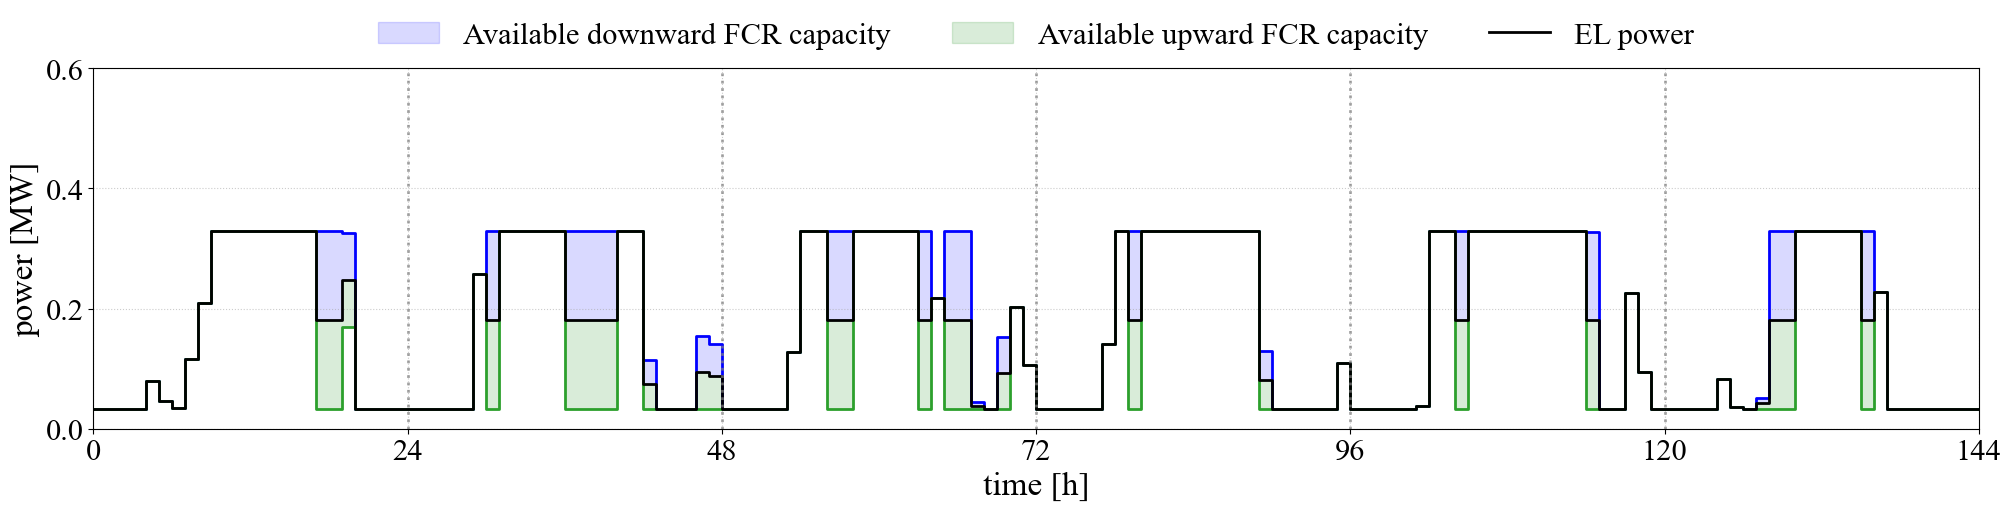

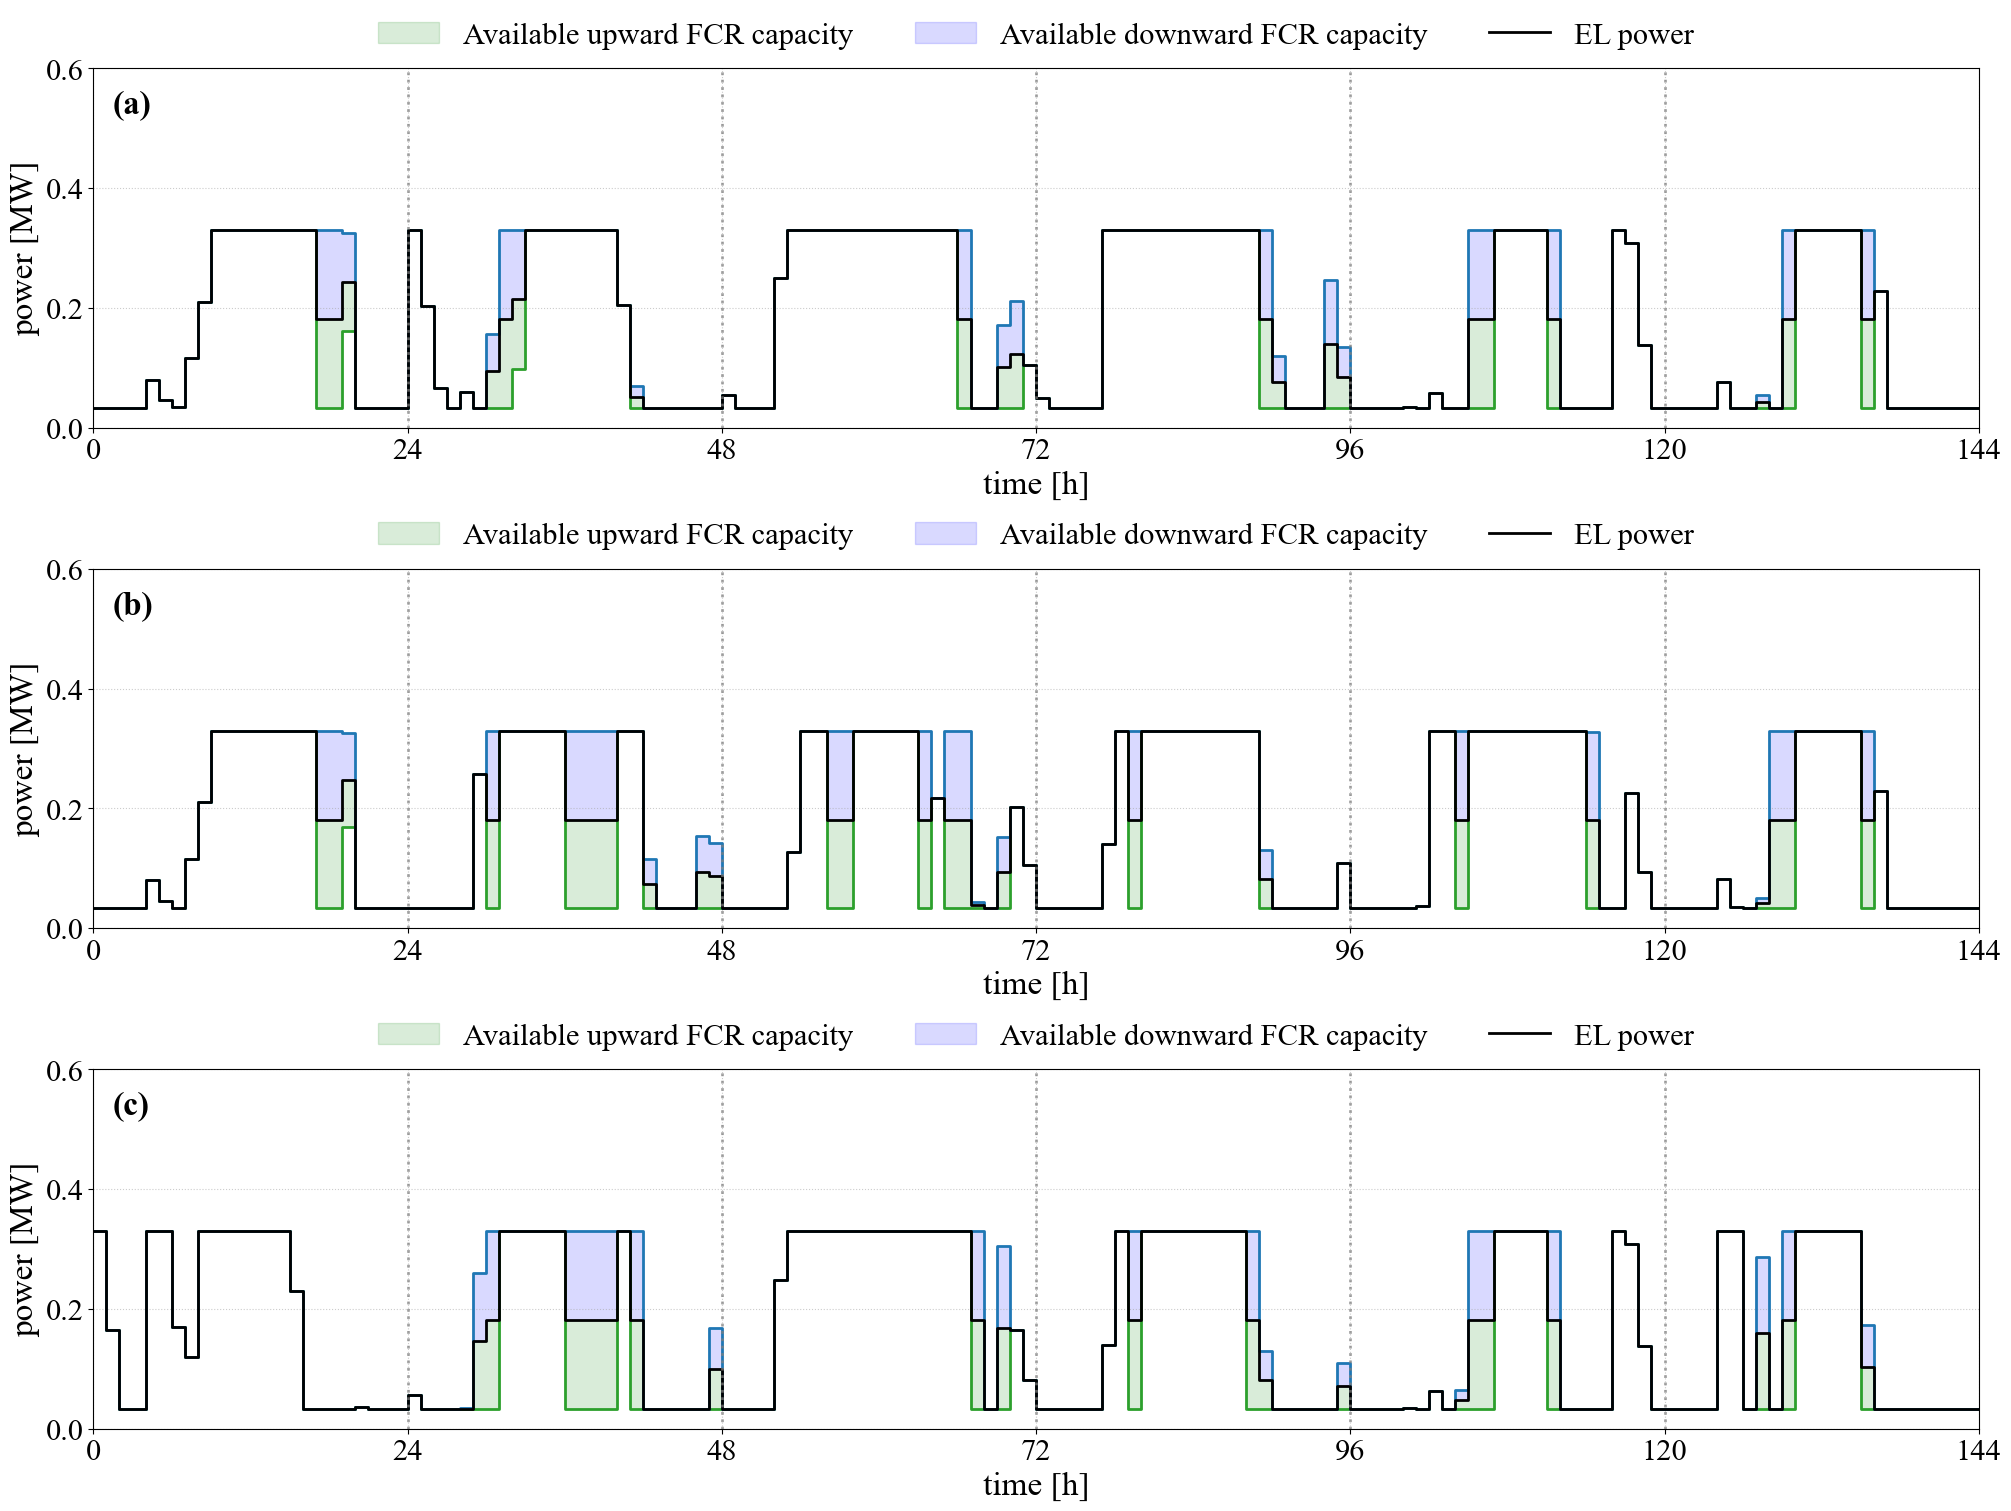

In [41]:
# FCR EL PLOTS FOR PAPER ----------------------------------------------------------------------------------
# TIME WINDOW - SINGLE SCENARIO -----
scen = 4
# FCR EL capacity allocation plot
p_el = pel_vals[scen, :].reshape(-1)
p_el = np.append(p_el, p_el[-1])
p_fcr_dwn = pel_fcr_dwn_vals[scen, :].reshape(-1)
p_fcr_dwn = np.append(p_fcr_dwn, p_fcr_dwn[-1])
p_fcr_up = pel_fcr_up_vals[scen, :].reshape(-1)
p_fcr_up = np.append(p_fcr_up, p_fcr_up[-1])

figFCRel4P, axsFCRel4P = plt.subplots(layout = 'constrained', figsize = (20, 5))
upper_bound = p_el + p_fcr_dwn
lower_bound = p_el - p_fcr_up
# Create shaded regions (fill between the base power and upper/lower bounds)
axsFCRel4P.fill_between(
    time_plot_tdays, p_el, upper_bound,
    step='post', color='blue', alpha=0.15, label='Available downward FCR capacity'
)
axsFCRel4P.fill_between(
    time_plot_tdays, lower_bound, p_el,
    step='post', color='green', alpha=0.15, label='Available upward FCR capacity'
)
# Add line plots
axsFCRel4P.step(time_plot_tdays, upper_bound, color='blue', where='post')
axsFCRel4P.step(time_plot_tdays, lower_bound, color=muted_green, where='post')
axsFCRel4P.step(time_plot_tdays, p_el, color='black', label='EL power', where='post')
# Options
axsFCRel4P.set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRel4P.set_xlabel('time [h]')
axsFCRel4P.set_ylabel('power [MW]')
axsFCRel4P.set_xlim(0, 144)
axsFCRel4P.set_ylim(0, 0.6)
# axsFCRel4P.legend(loc='upper right')
axsFCRel4P.legend(
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=3,               # Arranges items in 3 columns horizontally
        frameon=False,        # Removes border for a cleaner academic look
        borderaxespad=0
)
# Add vertical dotted lines to separate typical days
for day in range(1, N_d):
    x_pos = day * 24
    axsFCRel4P.axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7
    )
print(f'Scenario {scen}')



# TIME WINDOW - MULTIPLE SCENARIOS -----
# FCR EL capacity allocation plot
figFCRel4P, axsFCRel4P = plt.subplots(len(scenarios), 1, layout = 'constrained', figsize = (20, 5 * len(scenarios)))
for i in range(len(scenarios)):
    p_el = pel_vals[scenarios[i], :].reshape(-1)
    p_el = np.append(p_el, p_el[-1])
    p_fcr_dwn = pel_fcr_dwn_vals[scenarios[i], :].reshape(-1)
    p_fcr_dwn = np.append(p_fcr_dwn, p_fcr_dwn[-1])
    p_fcr_up = pel_fcr_up_vals[scenarios[i], :].reshape(-1)
    p_fcr_up = np.append(p_fcr_up, p_fcr_up[-1])

    upper_bound = p_el + p_fcr_dwn
    lower_bound = p_el - p_fcr_up
    # Create shaded regions (fill between the base power and upper/lower bounds)
    axsFCRel4P[i].fill_between(
        time_plot_tdays, lower_bound, p_el,
        step='post', color='green', alpha=0.15, label='Available upward FCR capacity'
    )
    axsFCRel4P[i].fill_between(
            time_plot_tdays, p_el, upper_bound,
            step='post', color='blue', alpha=0.15, label='Available downward FCR capacity'
    )
    # Add line plots
    axsFCRel4P[i].step(time_plot_tdays, lower_bound, color=muted_green, where='post')
    axsFCRel4P[i].step(time_plot_tdays, upper_bound, color=muted_blue, where='post')
    axsFCRel4P[i].step(time_plot_tdays, p_el, color='black', label='EL power', where='post')
    # Options
    axsFCRel4P[i].set_xticks([day * 24 for day in range(N_d + 1)])
    axsFCRel4P[i].set_xlabel('time [h]')
    axsFCRel4P[i].set_ylabel('power [MW]')
    axsFCRel4P[i].set_xlim(0, 144)
    axsFCRel4P[i].set_ylim(0, 0.6)
    # axsFCRel4P[i].legend(loc='upper right')
    axsFCRel4P[i].legend(
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=3,               # Arranges items in 3 columns horizontally
        frameon=False,        # Removes border for a cleaner academic look
        borderaxespad=0
    )
    # Add vertical dotted lines to separate typical days
    for day in range(1, N_d):
        x_pos = day * 24
        axsFCRel4P[i].axvline(
            x=x_pos, 
            color='gray',
            linestyle=':',
            linewidth=2,
            alpha=0.7
        )
    print(f'Scenario {scenarios[i]}')
    label = f"({string.ascii_lowercase[i]})"
    # axsFCRel4P[i].set_title(label, loc='left', fontweight='bold', fontsize=14)
    axsFCRel4P[i].text(0.01, 0.94, label, transform=axsFCRel4P[i].transAxes,
    fontsize=24, fontweight='bold', va='top', ha='left')


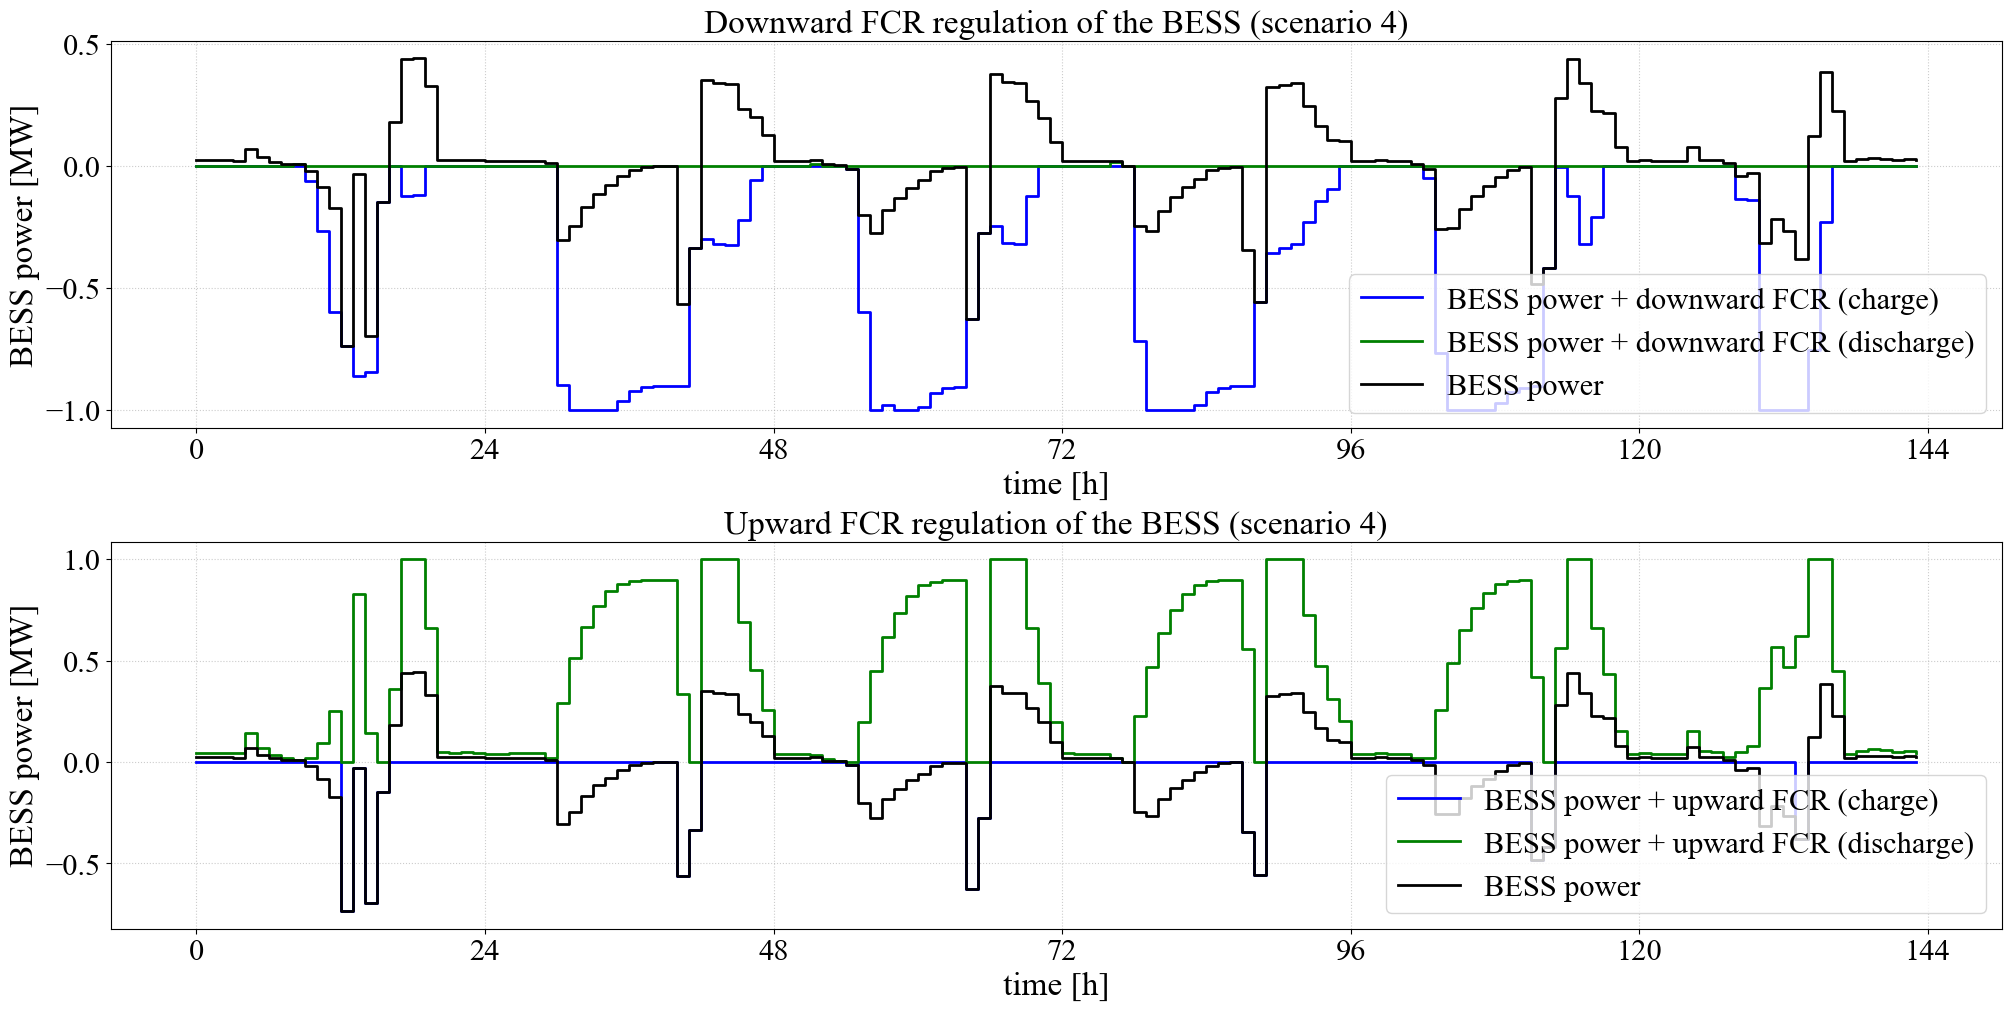

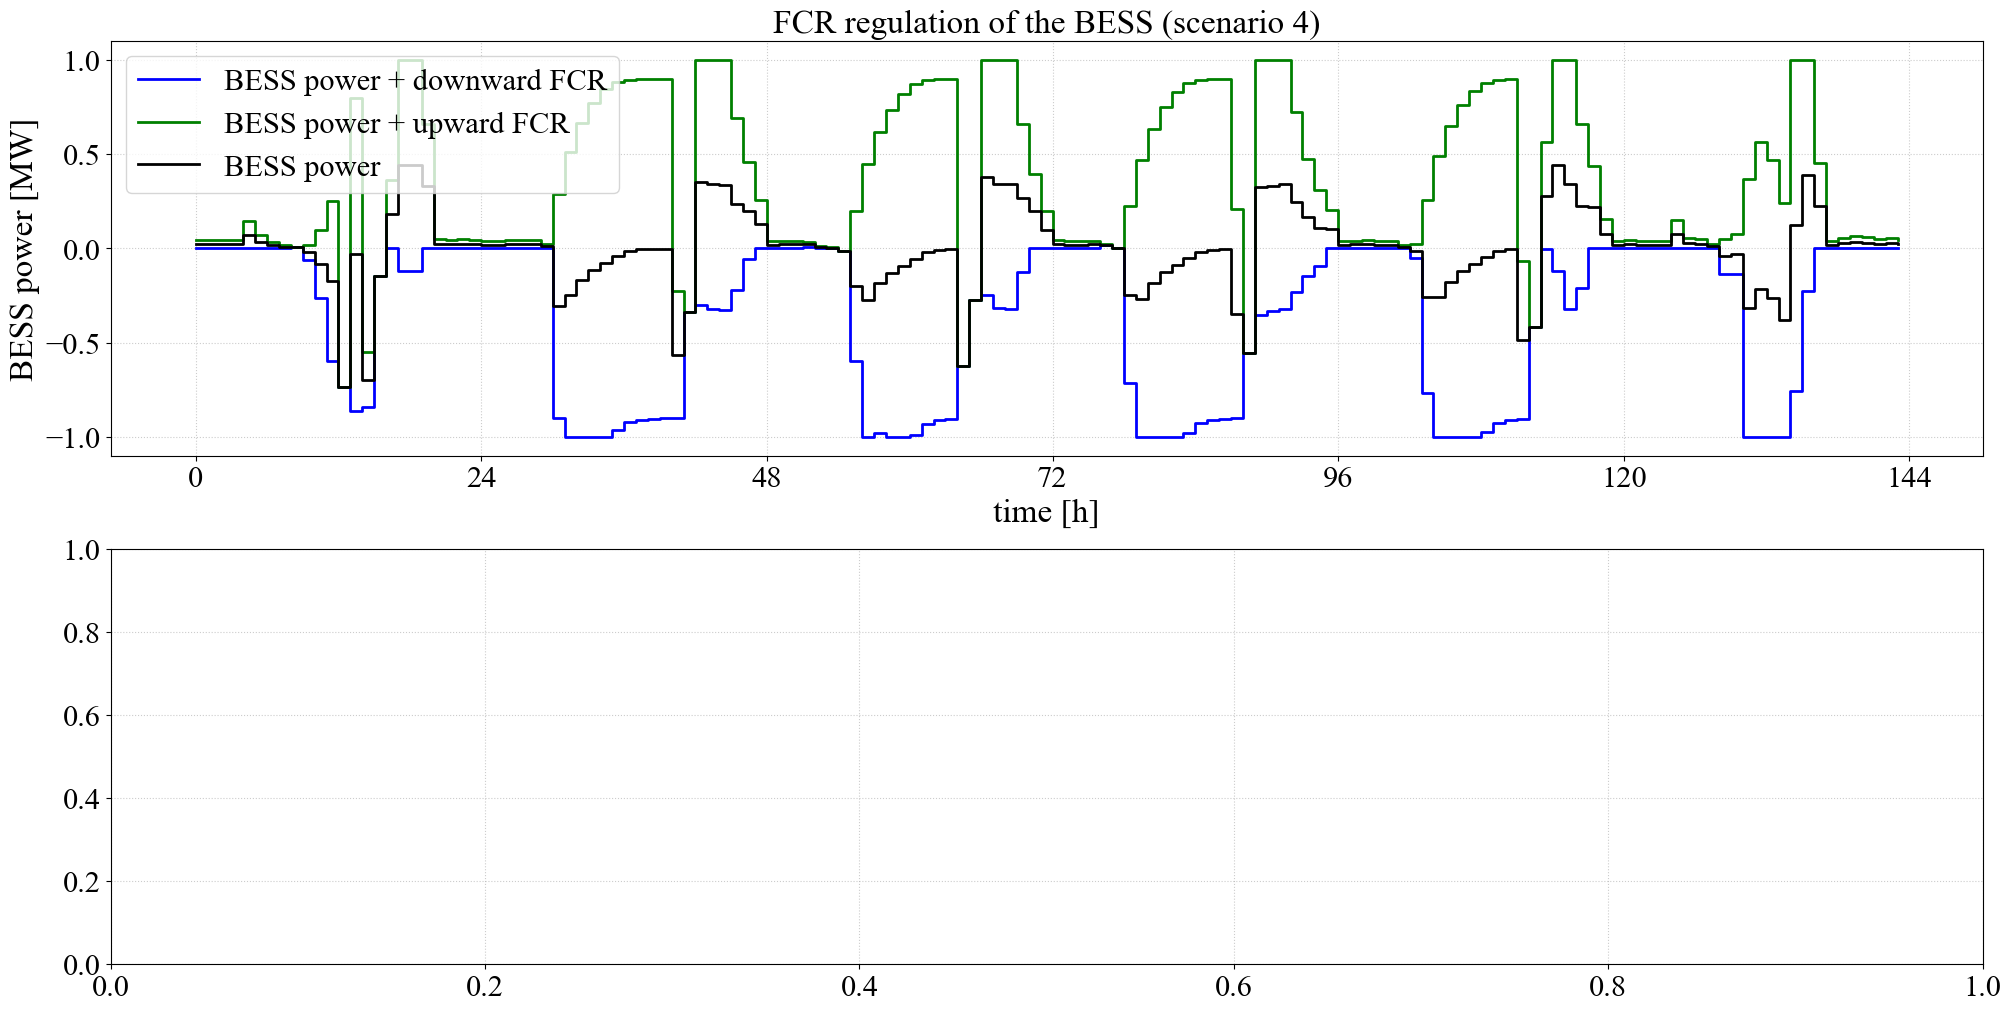

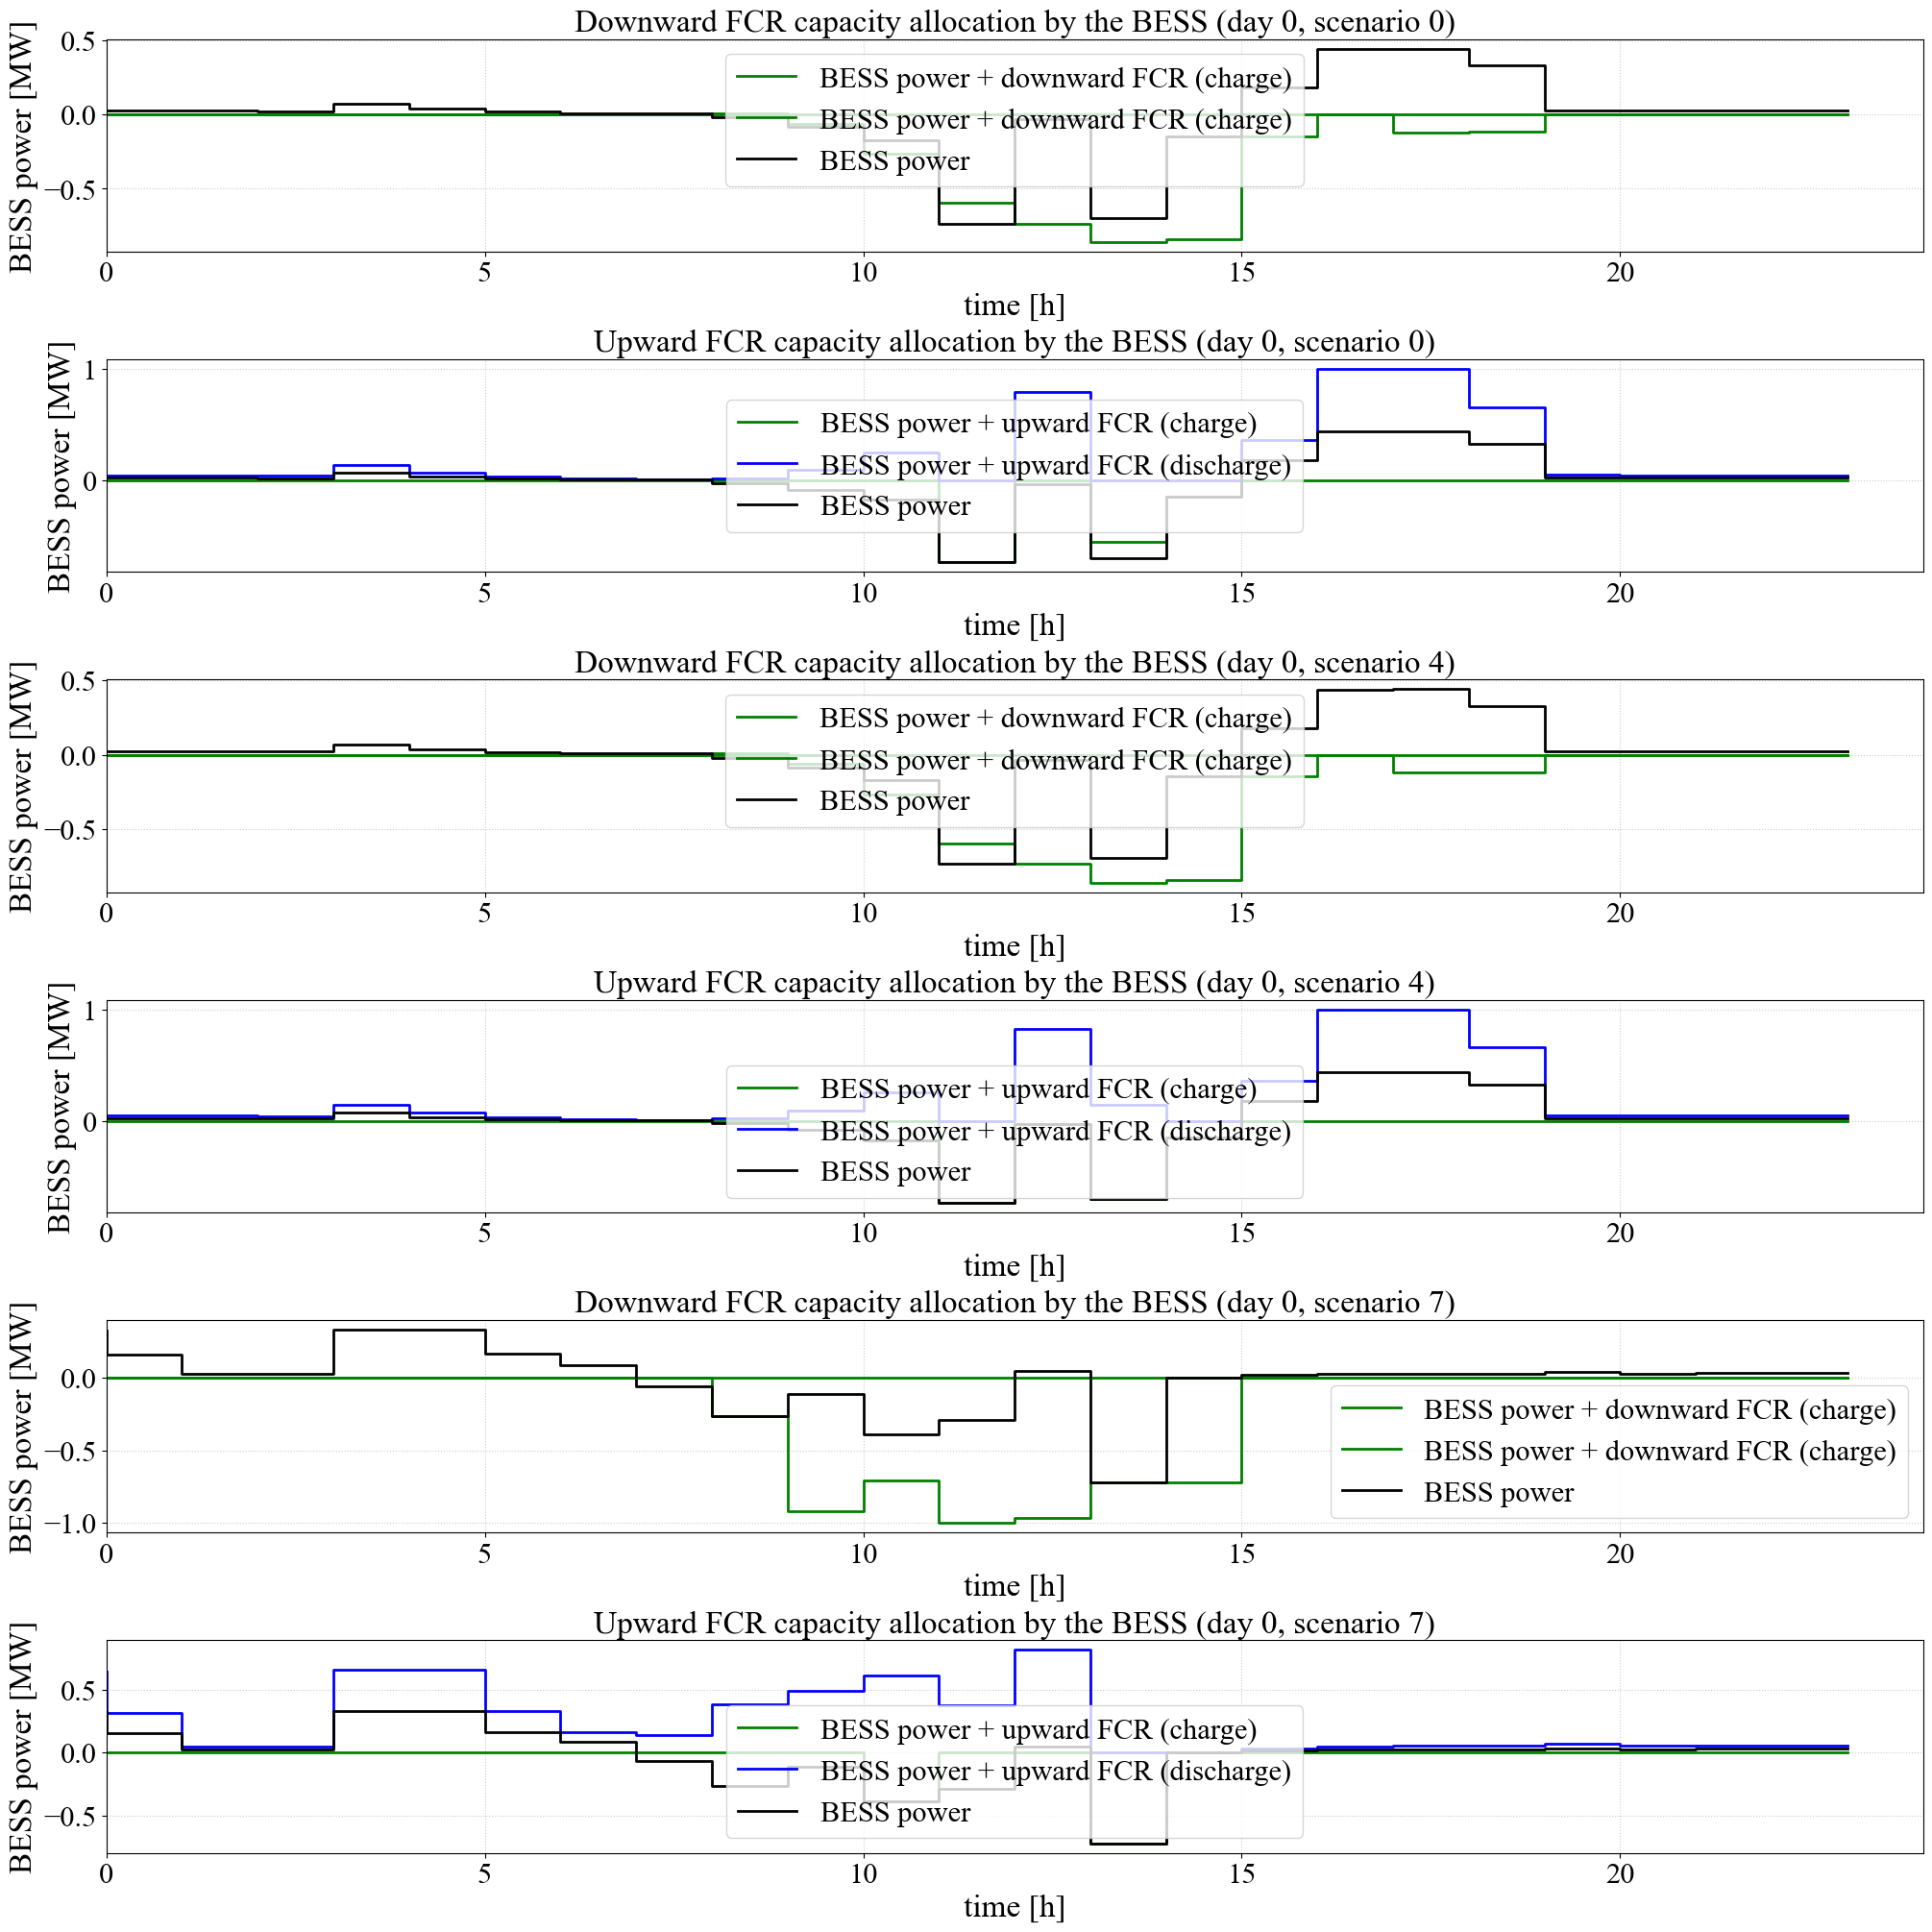

In [42]:
#------------------------------------------------------------------------------------------------
# PLOTTING (4/5)
#------------------------------------------------------------------------------------------------

# FCR BESS PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR BESS capacity allocation plot, downward regulation
figFCRbess, axsFCRbess = plt.subplots(2, 1, layout = 'constrained')
axsFCRbess[0].step(time_plot_tdays[:-1], -pb_ch_vals[scenarios[1], :].reshape(-1) - pb_fcr_ch_dwn_vals[scenarios[1], :].reshape(-1),
                    color = 'blue', label = 'BESS power + downward FCR (charge)', where='post')
axsFCRbess[0].step(time_plot_tdays[:-1], pb_dch_vals[scenarios[1], :].reshape(-1) - pb_fcr_dch_dwn_vals[scenarios[1], :].reshape(-1),
                    color = 'green', label = 'BESS power + downward FCR (discharge)', where='post')
axsFCRbess[0].step(time_plot_tdays[:-1], pb_vals[scenarios[1], :].reshape(-1),
                    color = 'black', label = 'BESS power', where='post')
axsFCRbess[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRbess[0].set_xlabel('time [h]')
axsFCRbess[0].set_ylabel('BESS power [MW]')
axsFCRbess[0].set_title(f'Downward FCR regulation of the BESS (scenario {scenarios [1]})')
# axsFCRbess[0].set_ylim(-0.1, 1.1 * m.Cb_mw['BESS'].value)
axsFCRbess[0].legend()
# FCR BESS capacity allocation plot, upward regulation
axsFCRbess[1].step(time_plot_tdays[:-1], -pb_ch_vals[scenarios[1], :].reshape(-1) + pb_fcr_ch_up_vals[scenarios[1], :].reshape(-1),
                    color = 'blue', label = 'BESS power + upward FCR (charge)', where='post')
axsFCRbess[1].step(time_plot_tdays[:-1], pb_dch_vals[scenarios[1], :].reshape(-1) + pb_fcr_dch_up_vals[scenarios[1], :].reshape(-1),
                    color = 'green', label = 'BESS power + upward FCR (discharge)', where='post')
axsFCRbess[1].step(time_plot_tdays[:-1], pb_vals[scenarios[1], :].reshape(-1),
                    color = 'black', label = 'BESS power', where='post')
axsFCRbess[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRbess[1].set_xlabel('time [h]')
axsFCRbess[1].set_ylabel('BESS power [MW]')
axsFCRbess[1].set_title(f'Upward FCR regulation of the BESS (scenario {scenarios [1]})')
# axsFCRbess[1].set_ylim(-0.1, 1.1 * m.Cb_mw['BESS'].value)
axsFCRbess[1].legend()



# TIME WINDOW
# FCR BESS capacity allocation plot
figFCRbess, axsFCRbess = plt.subplots(2, 1, layout = 'constrained')
axsFCRbess[0].step(time_plot_tdays[:-1], pb_vals[scenarios[1], :].reshape(-1) - pb_fcr_ch_dwn_vals[scenarios[1], :].reshape(-1) - pb_fcr_dch_dwn_vals[scenarios[1], :].reshape(-1),
                    color = 'blue', label = 'BESS power + downward FCR', where='post')
axsFCRbess[0].step(time_plot_tdays[:-1], pb_vals[scenarios[1], :].reshape(-1) + pb_fcr_ch_up_vals[scenarios[1], :].reshape(-1) + pb_fcr_dch_up_vals[scenarios[1], :].reshape(-1),
                    color = 'green', label = 'BESS power + upward FCR', where='post')
axsFCRbess[0].step(time_plot_tdays[:-1], pb_vals[scenarios[1], :].reshape(-1),
                    color = 'black', label = 'BESS power', where='post')
axsFCRbess[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRbess[0].set_xlabel('time [h]')
axsFCRbess[0].set_ylabel('BESS power [MW]')
axsFCRbess[0].set_title(f'FCR regulation of the BESS (scenario {scenarios [1]})')
axsFCRbess[0].set_ylim(-1.1 * Cb_mw_val, 1.1 * Cb_mw_val)
axsFCRbess[0].legend()



# CHOSEN DAY
figBESSfcr2, axsBESSfcr2 = plt.subplots(len(scenarios) * 2, 1, layout='constrained', figsize = (20, 20))
for i in range(len(scenarios)):
    # FCR BESS capacity allocation plot, downward regulation
    axsBESSfcr2[2*i].step(time_plot[:-1], -pb_ch_vals[scenarios[i], day_2plot, :] - pb_fcr_ch_dwn_vals[scenarios[i], day_2plot, :],
                    color = 'green', label = 'BESS power + downward FCR (charge)', where='post')
    axsBESSfcr2[2*i].step(time_plot[:-1], pb_dch_vals[scenarios[i], day_2plot, :] - pb_fcr_dch_dwn_vals[scenarios[i], day_2plot, :],
                    color = 'green', label = 'BESS power + downward FCR (charge)', where='post')
    axsBESSfcr2[2*i].step(time_plot[:-1], pb_vals[scenarios[i], day_2plot, :],
                    color = 'black', label = 'BESS power')
    axsBESSfcr2[2*i].set_xlabel('time [h]')
    axsBESSfcr2[2*i].set_ylabel('BESS power [MW]')
    axsBESSfcr2[2*i].set_title(f'Downward FCR capacity allocation by the BESS (day {day_2plot}, scenario {scenarios[i]})')
    axsBESSfcr2[2*i].set_xlim(0, 24)
    axsBESSfcr2[2*i].legend()
    # FCR BESS capacity allocation plot, upward regulation
    axsBESSfcr2[2*i+1].step(time_plot[:-1], -pb_ch_vals[scenarios[i], day_2plot, :] + pb_fcr_ch_up_vals[scenarios[i], day_2plot, :],
                    color = 'green', label = 'BESS power + upward FCR (charge)')
    axsBESSfcr2[2*i+1].step(time_plot[:-1], pb_dch_vals[scenarios[i], day_2plot, :] + pb_fcr_dch_up_vals[scenarios[i], day_2plot, :],
                    color = 'blue', label = 'BESS power + upward FCR (discharge)')
    axsBESSfcr2[2*i+1].step(time_plot[:-1], pb_vals[scenarios[i], day_2plot, :],
                    color = 'black', label = 'BESS power')
    axsBESSfcr2[2*i+1].set_xlabel('time [h]')
    axsBESSfcr2[2*i+1].set_ylabel('BESS power [MW]')
    axsBESSfcr2[2*i+1].set_title(f'Upward FCR capacity allocation by the BESS (day {day_2plot}, scenario {scenarios[i]})')
    axsBESSfcr2[2*i+1].set_xlim(0, 24)
    axsBESSfcr2[2*i+1].legend()

Scenario 4
Scenario 0
Scenario 4
Scenario 7


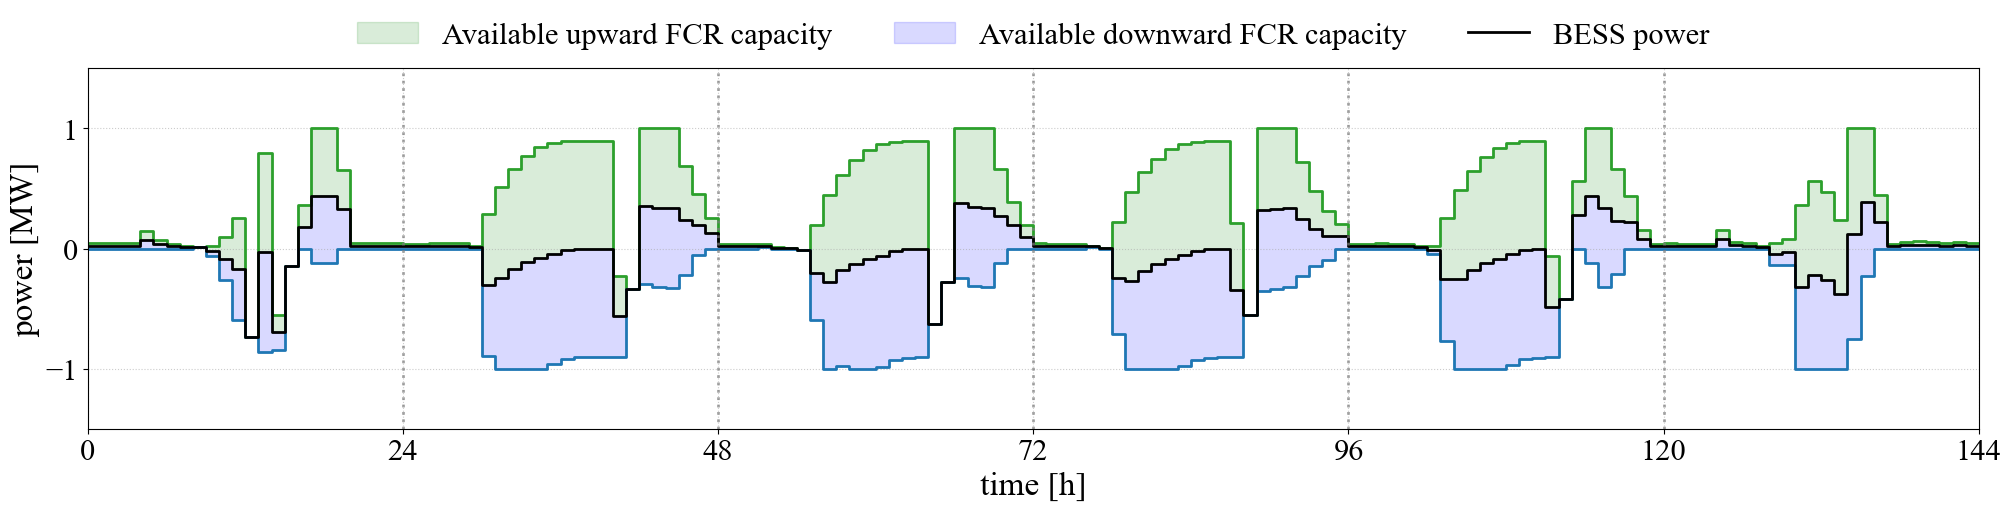

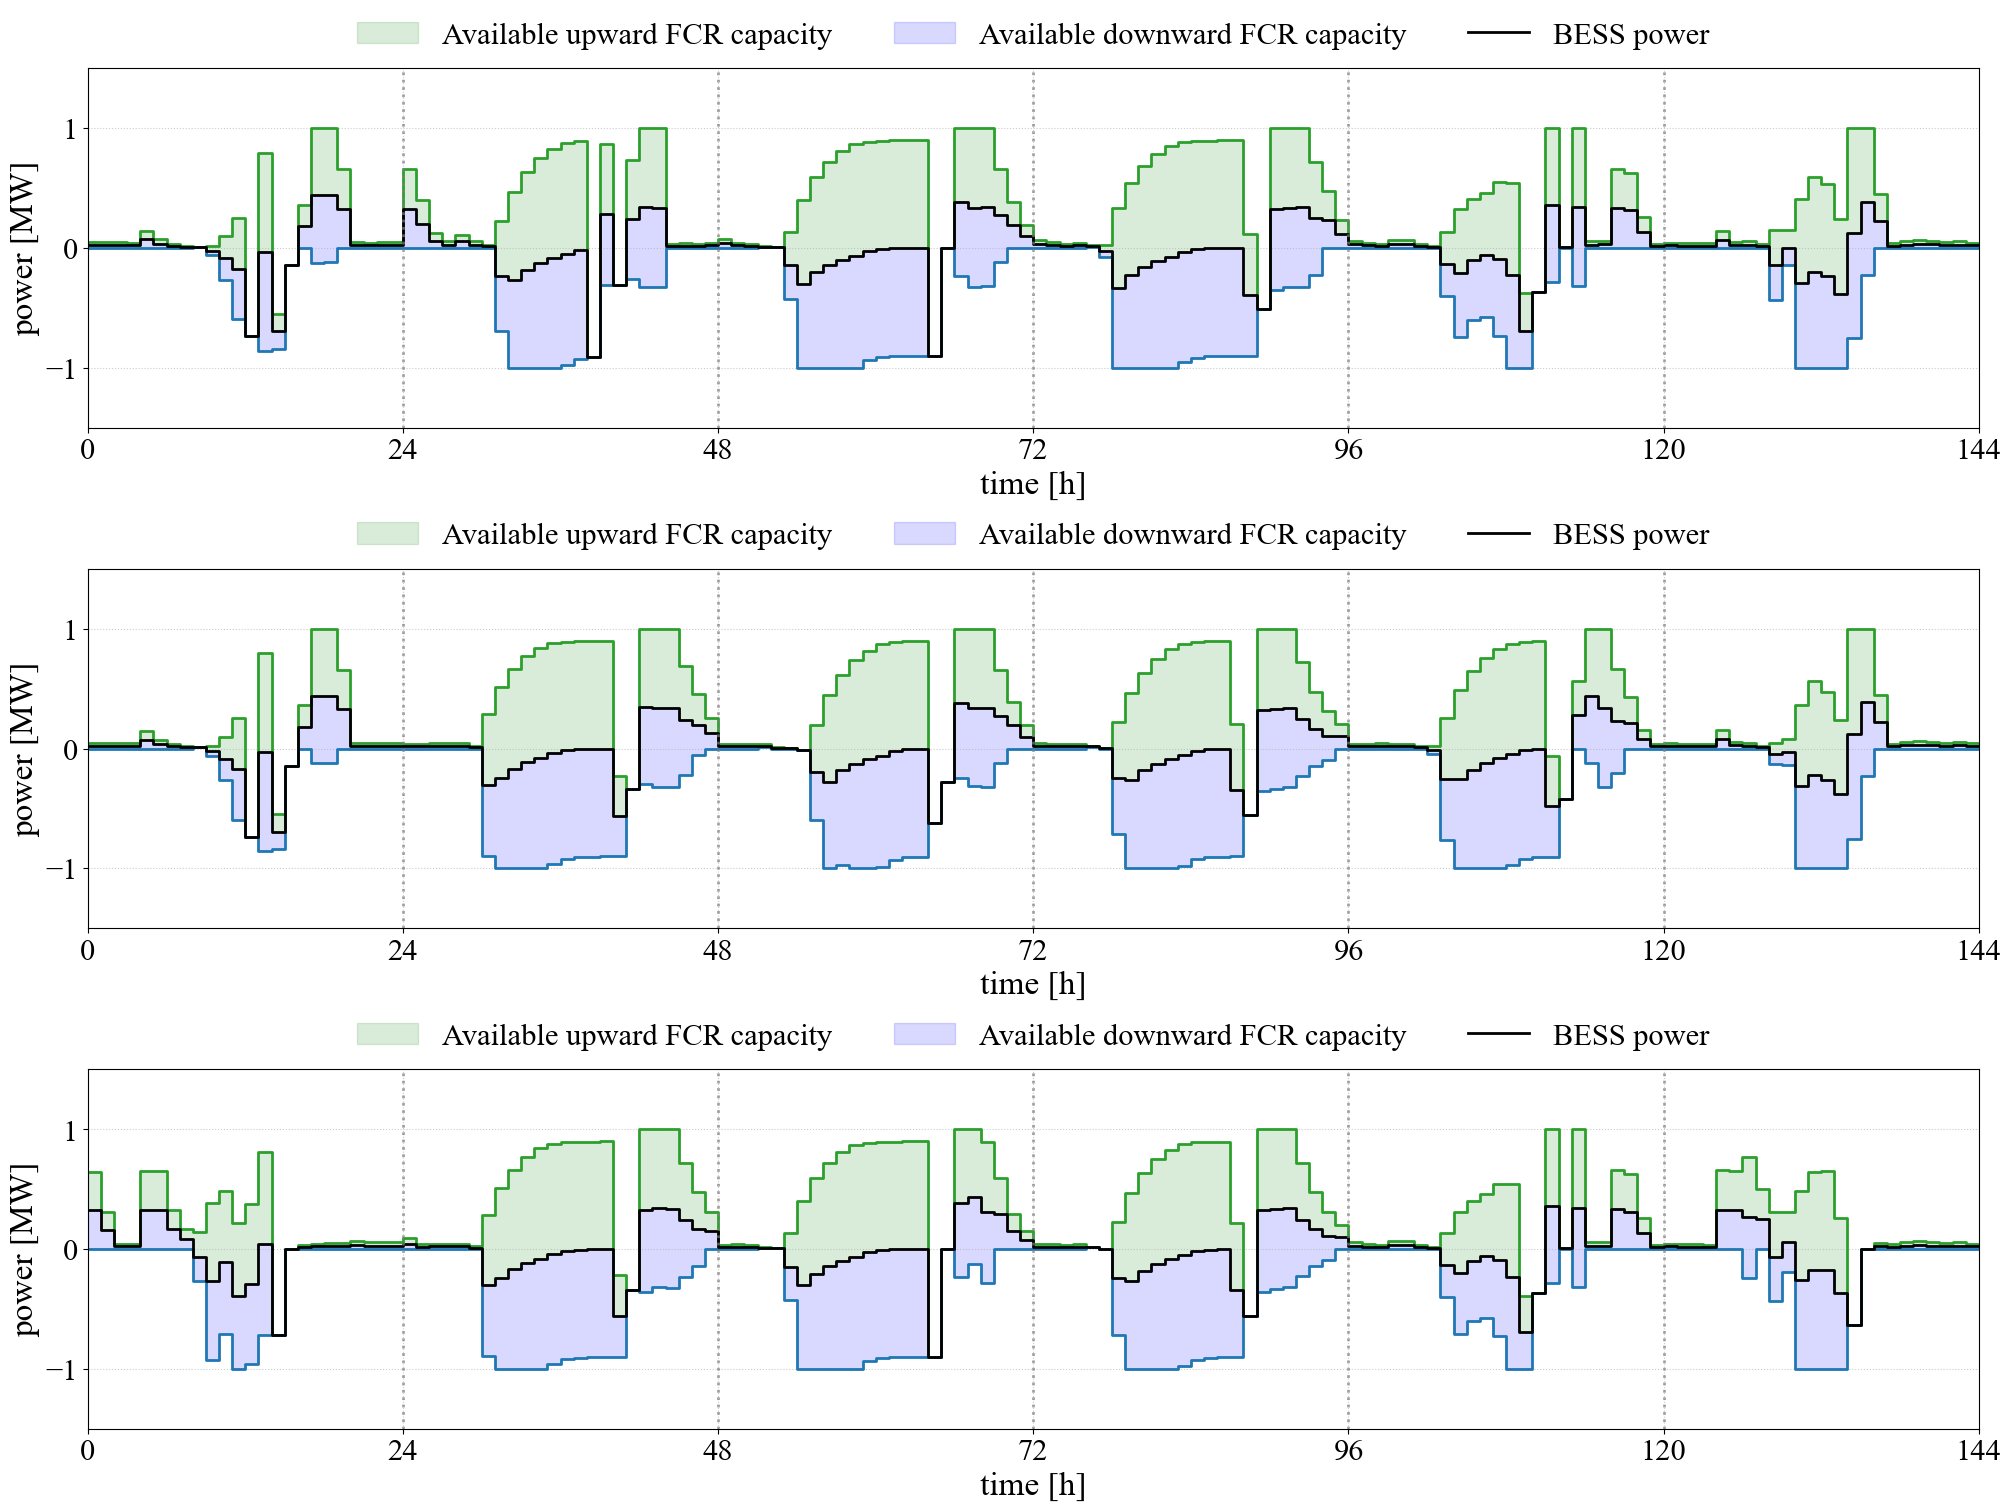

In [43]:
# FCR BESS PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW - SINGLE SCENARIO -----
# FCR BESS capacity allocation plot
p_b = pb_vals[scen, :].reshape(-1)
p_b = np.append(p_b, p_b[-1])
pb_fcr_ch_dwn = pb_fcr_ch_dwn_vals[scen, :].reshape(-1)
pb_fcr_ch_dwn = np.append(pb_fcr_ch_dwn, pb_fcr_ch_dwn[-1])
pb_fcr_ch_up = pb_fcr_ch_up_vals[scen, :].reshape(-1)
pb_fcr_ch_up = np.append(pb_fcr_ch_up, pb_fcr_ch_up[-1])
pb_fcr_dch_dwn = pb_fcr_dch_dwn_vals[scen, :].reshape(-1)
pb_fcr_dch_dwn = np.append(pb_fcr_dch_dwn, pb_fcr_dch_dwn[-1])
pb_fcr_dch_up = pb_fcr_dch_up_vals[scen, :].reshape(-1)
pb_fcr_dch_up = np.append(pb_fcr_dch_up, pb_fcr_dch_up[-1])

figFCRbess4P, axsFCRbess4P = plt.subplots(layout = 'constrained', figsize = (20, 5))
upper_bound = p_b + pb_fcr_ch_up + pb_fcr_dch_up
lower_bound = p_b - pb_fcr_ch_dwn - pb_fcr_dch_dwn
# Create shaded regions (fill between the base power and upper/lower bounds)
axsFCRbess4P.fill_between(
    time_plot_tdays, p_b, upper_bound,
    step='post', color='green', alpha=0.15, label='Available upward FCR capacity'
)
axsFCRbess4P.fill_between(
    time_plot_tdays, lower_bound, p_b,
    step='post', color='blue', alpha=0.15, label='Available downward FCR capacity'
)
# Add line plots
axsFCRbess4P.step(time_plot_tdays, upper_bound, color=muted_green, where='post')
axsFCRbess4P.step(time_plot_tdays, lower_bound, color=muted_blue, where='post')
axsFCRbess4P.step(time_plot_tdays, p_b, color='black', label='BESS power', where='post')
# Options
axsFCRbess4P.set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRbess4P.set_xlabel('time [h]')
axsFCRbess4P.set_ylabel('power [MW]')
# axsFCRbess4P.set_title(f'FCR regulation of the BESS (scenario {scenarios [1]})')
axsFCRbess4P.set_xlim(0, 144)
axsFCRbess4P.set_ylim(-1.5, 1.5)
# axsFCRbess4P.legend(loc='upper right')
# axsFCRbess4P.legend(loc='upper right', bbox_to_anchor=(1.02, 1), borderaxespad=0)
axsFCRbess4P.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=3,               # Arranges items in 3 columns horizontally
    frameon=False,        # Removes border for a cleaner academic look
    borderaxespad=0
)
# axsFCRbess4P.legend(
#     loc='upper center', 
#     bbox_to_anchor=(0.5, -0.18), 
#     ncol=3, 
#     frameon=False,
#     borderaxespad=0
# )
# Add vertical dotted lines to separate typical days
for day in range(1, N_d):
    x_pos = day * 24
    axsFCRbess4P.axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7
    )
print(f'Scenario {scen}')



# TIME WINDOW - MULTIPLE SCENARIOS -----
# FCR BESS capacity allocation plot
figFCRbess4P, axsFCRbess4P = plt.subplots(len(scenarios), 1, layout = 'constrained', figsize = (20, 5 * len(scenarios)))
for i in range(len(scenarios)):
    p_b = pb_vals[scenarios[i], :].reshape(-1)
    p_b = np.append(p_b, p_b[-1])
    pb_fcr_ch_dwn = pb_fcr_ch_dwn_vals[scenarios[i], :].reshape(-1)
    pb_fcr_ch_dwn = np.append(pb_fcr_ch_dwn, pb_fcr_ch_dwn[-1])
    pb_fcr_ch_up = pb_fcr_ch_up_vals[scenarios[i], :].reshape(-1)
    pb_fcr_ch_up = np.append(pb_fcr_ch_up, pb_fcr_ch_up[-1])
    pb_fcr_dch_dwn = pb_fcr_dch_dwn_vals[scenarios[i], :].reshape(-1)
    pb_fcr_dch_dwn = np.append(pb_fcr_dch_dwn, pb_fcr_dch_dwn[-1])
    pb_fcr_dch_up = pb_fcr_dch_up_vals[scenarios[i], :].reshape(-1)
    pb_fcr_dch_up = np.append(pb_fcr_dch_up, pb_fcr_dch_up[-1])

    upper_bound = p_b + pb_fcr_ch_up + pb_fcr_dch_up
    lower_bound = p_b - pb_fcr_ch_dwn - pb_fcr_dch_dwn
    # Create shaded regions (fill between the base power and upper/lower bounds)
    axsFCRbess4P[i].fill_between(
        time_plot_tdays, p_b, upper_bound,
        step='post', color='green', alpha=0.15, label='Available upward FCR capacity'
    )
    axsFCRbess4P[i].fill_between(
        time_plot_tdays, lower_bound, p_b,
        step='post', color='blue', alpha=0.15, label='Available downward FCR capacity'
    )
    # Add line plots
    axsFCRbess4P[i].step(time_plot_tdays, upper_bound, color=muted_green, where='post')
    axsFCRbess4P[i].step(time_plot_tdays, lower_bound, color=muted_blue, where='post')
    axsFCRbess4P[i].step(time_plot_tdays, p_b, color='black', label='BESS power', where='post')
    # Options
    axsFCRbess4P[i].set_xticks([day * 24 for day in range(N_d + 1)])
    axsFCRbess4P[i].set_xlabel('time [h]')
    axsFCRbess4P[i].set_ylabel('power [MW]')
    # axsFCRbess4P.set_title(f'FCR regulation of the BESS (scenario {scenarios [1]})')
    axsFCRbess4P[i].set_xlim(0, 144)
    axsFCRbess4P[i].set_ylim(-1.5, 1.5)
    # axsFCRbess4P[i].legend(loc='upper right')
    axsFCRbess4P[i].legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=3,               # Arranges items in 3 columns horizontally
    frameon=False,        # Removes border for a cleaner academic look
    borderaxespad=0
    )
    # Add vertical dotted lines to separate typical days
    for day in range(1, N_d):
        x_pos = day * 24
        axsFCRbess4P[i].axvline(
            x=x_pos, 
            color='gray',
            linestyle=':',
            linewidth=2,
            alpha=0.7
        )
    print(f'Scenario {scenarios[i]}')

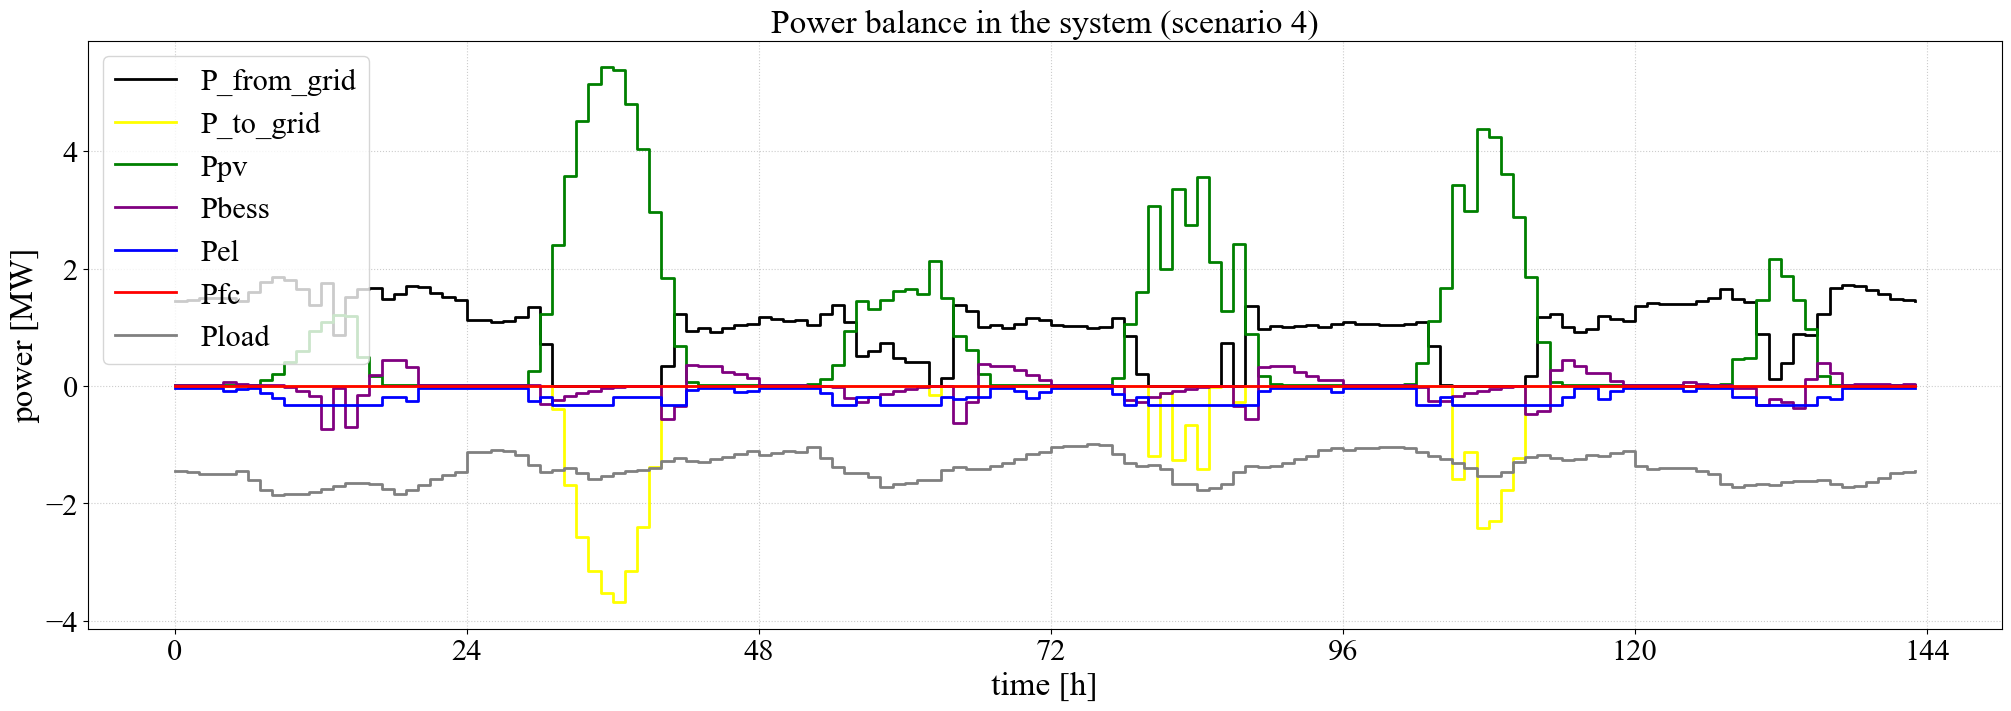

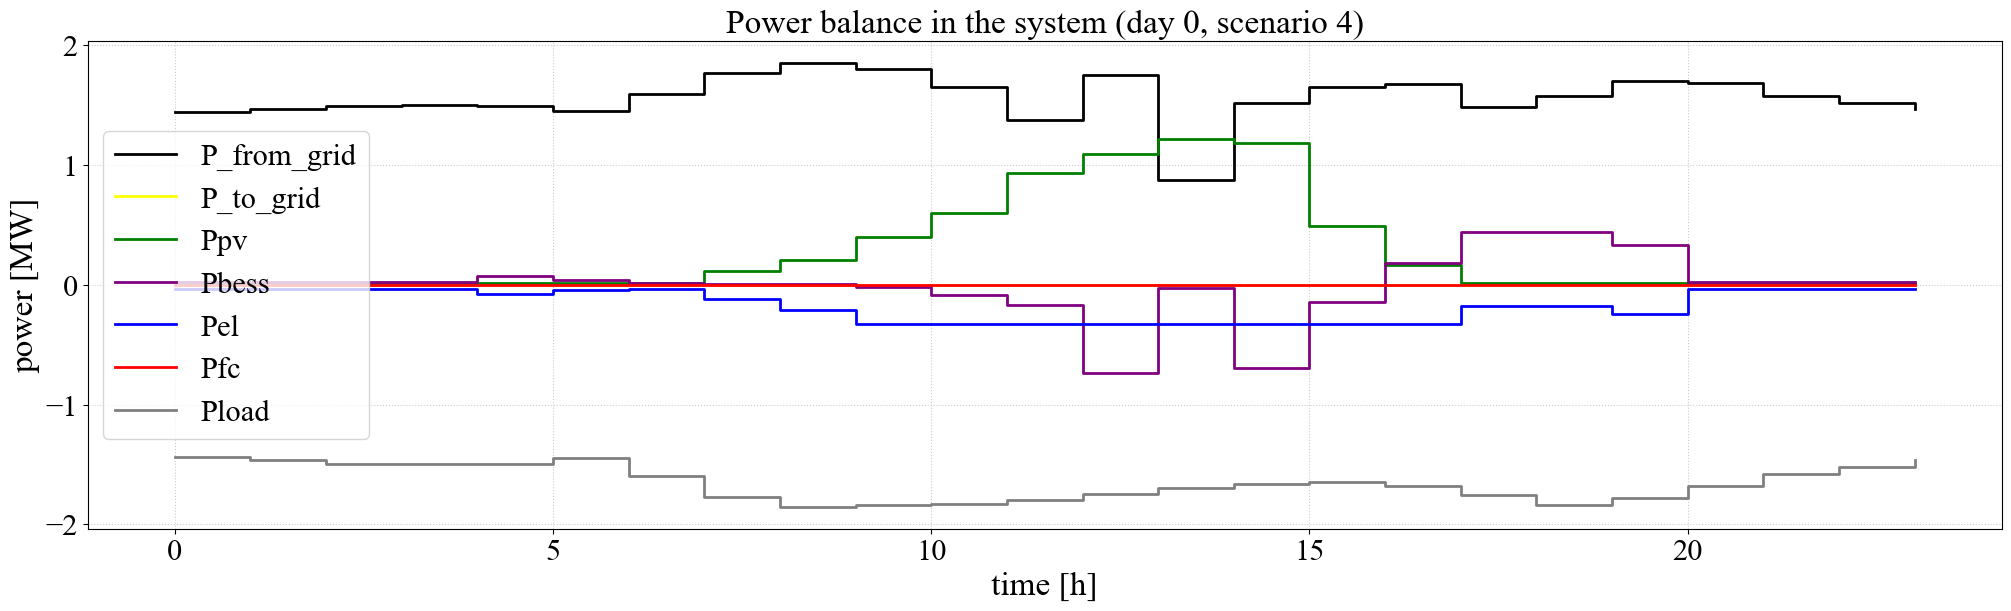

In [44]:
#------------------------------------------------------------------------------------------------
# PLOTTING (5/5)
#------------------------------------------------------------------------------------------------

# POWER BALANCE PLOTS --------------------------------------------------------------------------------------
# TIME WINDOW
# Power balance plot
figPow, axsPow = plt.subplots(layout='constrained', figsize = (20, 7))
axsPow.step(time_plot_tdays[:-1], pgrid_p_vals[scenarios[1], :, :].reshape(-1), color = 'black', label = 'P_from_grid', where='post')
axsPow.step(time_plot_tdays[:-1], -pgrid_n_vals[scenarios[1], :, :].reshape(-1), color = 'yellow', label = 'P_to_grid', where='post')
axsPow.step(time_plot_tdays[:-1], Ppv_vals[scenarios[1], :, :].reshape(-1), color = 'green', label = 'Ppv', where='post')
axsPow.step(time_plot_tdays[:-1], pb_vals[scenarios[1], :, :].reshape(-1), color = 'purple', label = 'Pbess', where='post')
axsPow.step(time_plot_tdays[:-1], -pel_vals[scenarios[1], :, :].reshape(-1), color = 'blue', label = 'Pel', where='post')
axsPow.step(time_plot_tdays[:-1], pfc_vals[scenarios[1], :, :].reshape(-1), color = 'red', label = 'Pfc', where='post')
axsPow.step(time_plot_tdays[:-1], -Pload_vals[scenarios[1], :, :].reshape(-1), color = 'grey', label = 'Pload', where='post')
axsPow.set_xticks([day * 24 for day in range(N_d + 1)])
axsPow.set_xlabel('time [h]')
axsPow.set_ylabel('power [MW]')
axsPow.set_title(f'Power balance in the system (scenario {scenarios[1]})')
# axsPow.set_xlim(week*24*7, (week+1)*24*7 + 1)
# axsPow.set_ylim(0, 1.1 * Pel_rtd['EL'])
axsPow.legend()

# CHOSEN DAY
# Power balance plot
figPow2, axsPow2 = plt.subplots(layout='constrained', figsize = (20, 6))
axsPow2.step(time_plot[:-1], pgrid_p_vals[scenarios[1], day_2plot, :], color = 'black', label = 'P_from_grid', where='post')
axsPow2.step(time_plot[:-1], -pgrid_n_vals[scenarios[1], day_2plot, :], color = 'yellow', label = 'P_to_grid', where='post')
axsPow2.step(time_plot[:-1], Ppv_vals[scenarios[1], day_2plot, :], color = 'green', label = 'Ppv', where='post')
axsPow2.step(time_plot[:-1], pb_vals[scenarios[1], day_2plot, :], color = 'purple', label = 'Pbess', where='post')
axsPow2.step(time_plot[:-1], -pel_vals[scenarios[1], day_2plot, :], color = 'blue', label = 'Pel', where='post')
axsPow2.step(time_plot[:-1], pfc_vals[scenarios[1], day_2plot, :], color = 'red', label = 'Pfc', where='post')
axsPow2.step(time_plot[:-1], -Pload_vals[scenarios[1], day_2plot, :], color = 'grey', label = 'Pload', where='post')
axsPow2.set_xlabel('time [h]')
axsPow2.set_ylabel('power [MW]')
axsPow2.set_title(f'Power balance in the system (day {day_2plot}, scenario {scenarios[1]})')
# axsPow2.set_xlim(0, 24)
# axsPow2.set_ylim(0, 1.1 * Pel_rtd['EL'])
axsPow2.legend()

Scenario 0


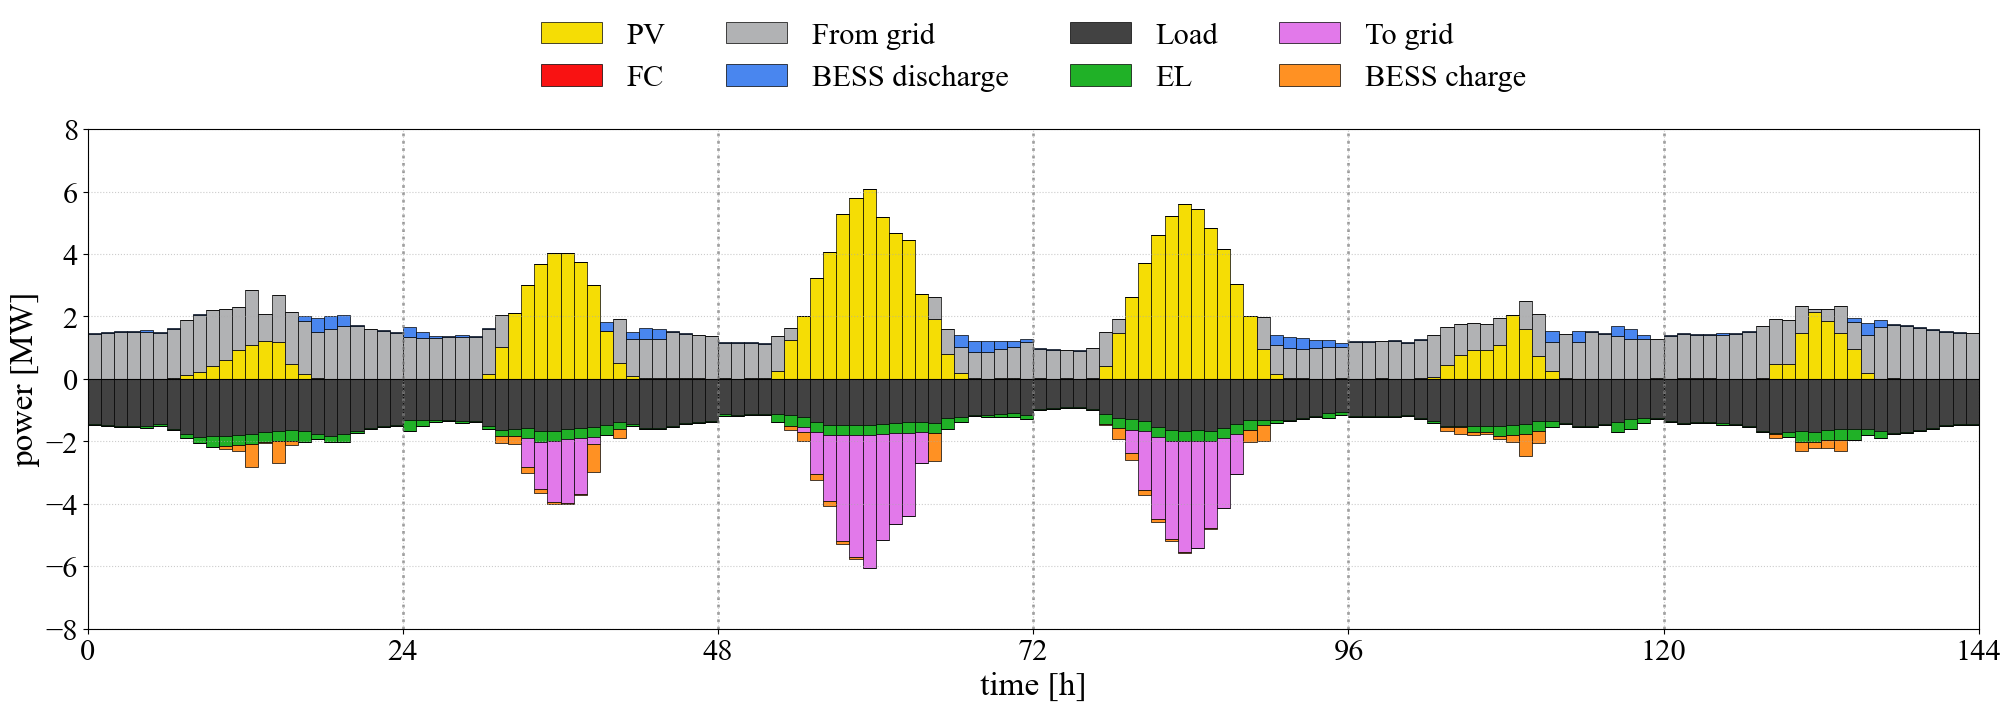

In [45]:
# POWER BALANCE PLOTS FOR PAPER --------------------------------------------------------------------------------------
# TIME WINDOW
# Power balance plot
scen_idx = 0
p_grid_p = pgrid_p_vals[scen_idx, :, :].reshape(-1)
p_grid_n = pgrid_n_vals[scen_idx, :, :].reshape(-1)
p_pv     = Ppv_vals[scen_idx, :, :].reshape(-1)
p_bess   = pb_vals[scen_idx, :, :].reshape(-1)
p_el     = pel_vals[scen_idx, :, :].reshape(-1)
p_fc     = pfc_vals[scen_idx, :, :].reshape(-1)
p_load   = Pload_vals[scen_idx, :, :].reshape(-1)

# Separate BESS into charging (-) and discharging (+)
p_bess_pos = np.maximum(p_bess, 0)
p_bess_neg = np.minimum(p_bess, 0)

# Define x positions (left-aligned hourly bins to match step interval)
x_time = time_plot_tdays[:-1]
bar_width = 1.0  # Width = 1 hour; use ~0.8 for gaps between bars

figPow4P, axsPow4P = plt.subplots(layout='constrained', figsize=(20, 7))

# -------------------------------------------------------------------------
# 1. STACK POSITIVE POWER (Above Y = 0)
# -------------------------------------------------------------------------
pos_bottom = np.zeros_like(x_time, dtype=float)

# Generation / Import sources
axsPow4P.bar(x_time, p_pv, width=bar_width, align='edge',
           bottom=pos_bottom, color="#f5dd05", edgecolor='black', linewidth=0.5, label='PV')
pos_bottom += p_pv

axsPow4P.bar(x_time, p_fc, width=bar_width, align='edge',
           bottom=pos_bottom, color="#f91212", edgecolor='black', linewidth=0.5, label='FC')
pos_bottom += p_fc

axsPow4P.bar(x_time, p_grid_p, width=bar_width, align='edge',
           bottom=pos_bottom, color="#b1b2b4", edgecolor='black', linewidth=0.5, label='From grid')
pos_bottom += p_grid_p

axsPow4P.bar(x_time, p_bess_pos, width=bar_width, align='edge',
           bottom=pos_bottom, color="#4986ef", edgecolor='black', linewidth=0.5, label='BESS discharge')

# -------------------------------------------------------------------------
# 2. STACK NEGATIVE POWER (Below Y = 0)
# -------------------------------------------------------------------------
neg_bottom = np.zeros_like(x_time, dtype=float)

# Consumption / Export sinks
axsPow4P.bar(x_time, -p_load, width=bar_width, align='edge',
           bottom=neg_bottom, color="#424242", edgecolor='black', linewidth=0.5, label='Load')
neg_bottom -= p_load

axsPow4P.bar(x_time, -p_el, width=bar_width, align='edge',
           bottom=neg_bottom, color="#20b127", edgecolor='black', linewidth=0.5, label='EL')
neg_bottom -= p_el

axsPow4P.bar(x_time, -p_grid_n, width=bar_width, align='edge',
           bottom=neg_bottom, color="#E279EA", edgecolor='black', linewidth=0.5, label='To grid')
neg_bottom -= p_grid_n

axsPow4P.bar(x_time, p_bess_neg, width=bar_width, align='edge',
           bottom=neg_bottom, color="#ff9123", edgecolor='black', linewidth=0.5, label='BESS charge')

# -------------------------------------------------------------------------
# 3. FORMATTING
# -------------------------------------------------------------------------
axsPow4P.axhline(0, color='black', linewidth=0.8) # Baseline at y=0
axsPow4P.set_xticks([day * 24 for day in range(N_d + 1)])
axsPow4P.set_xlim(0, 144)
axsPow4P.set_ylim(-8, 8)
axsPow4P.set_xlabel('time [h]')
axsPow4P.set_ylabel('power [MW]')
# axsPow4P.set_title(f'Power balance in the system (scenario {scenarios[1]})')

# Horizontal gridlines matching the reference paper style
# axsPow4P.grid(axis='y', linestyle='--', alpha=0.5)

# Add vertical dotted lines to separate typical days
for day in range(1, N_d):
    x_pos = day * 24
    axsPow4P.axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7
    )
# Top legend arranged horizontally outside or at top
axsPow4P.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)

print(f'Scenario {scen_idx}')